## Исследование данных о российском кинопрокате



**Описание проекта**

Заказчик этого исследования — Министерство культуры Российской Федерации.
Вам нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделите внимание фильмам, которые получили государственную поддержку. Попробуйте ответить на вопрос, насколько такие фильмы интересны зрителю.
Вы будете работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск.

**Цели проекта**

- Выявить текущие тренды рынка российского кинопроката.
- Узнать, насколько интересны зрителю фильмы, получившие господдержку.

**План работы**

1. Соединить полученные данные в один датафрейм.
2. Провести предобработку данных, изучив пропуски, дубликаты и аномалии, исправив их там, где это возможно и необходимо, дополнительно добавить в случае потребности новые столбцы для удобства исследования.
3. Провести исследовательский анализ  общих данных:
- Оценить полноту представленной информации касающейся кассовых сборов.
- Изучить динамику сборов по годам.
- Оценить медианную и среднюю сумму сборов.
- Оценить влиние ли возрастного ограничение аудитории на сборы в прокате.
4. Исследовать фильмы, которые получили господдержку:
- Изучить суммы выделяемых средств на поддержку кино.
- Оценить окупаемость и рейтинг фильмов.
5. Оформить выводы и подготовить рекомендации.

**Описание данных**

Таблица `'mkrf_movies'` содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений.

- `'title'` — название фильма;
- `'puNumber'` — номер прокатного удостоверения;
- `'show_start_date'` — дата премьеры фильма;
- `'type'` — тип фильма;
- `'film_studio'` — студия-производитель;
- `'production_country'` — страна-производитель;
- `'director'` — режиссёр;
- `'producer'` — продюсер;
- `'age_restriction'` — возрастная категория;
- `'refundable_support'` — объём возвратных средств государственной поддержки;
- `'nonrefundable_support'` — объём невозвратных средств государственной поддержки;
- `'financing_source'` — источник государственного финансирования;
- `'budget'` — общий бюджет фильма;
- `'ratings'` — рейтинг фильма на КиноПоиске;
- `'genres'` — жанр фильма.

Обратите внимание, что столбец `'budget'` уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку.
Таблица `'mkrf_shows'` содержит сведения о показах фильмов в российских кинотеатрах.

- `'puNumber'` — номер прокатного удостоверения;
- `'box_office'` — сборы в рублях.

### Шаг 1. Откройте файлы с данными и объедините их в один датафрейм.

Объедините данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм.



Мы имеем два датасета, информация из которых потребуется нам для дальнейшего исследования.

Прежде чем приступить к работе откроем эти датасеты и посмотрим на их содержимое.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.api.types import CategoricalDtype

pd.options.display.max_columns = 30
#pd.options.display.max_rows = 8000

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    mkrf_movies = pd.read_csv('/datasets/mkrf_movies.csv')
except:
    mkrf_movies = pd.read_csv('https://адрес_удален/datasets/mkrf_movies.csv')

In [ ]:
mkrf_movies.head(20)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия"
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия"
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал"
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия"


Как и было указано в описании данных, некоторые фильмы действительно имеют несколько покатных удостоверений (например, "Особо опасен" - целых три).

In [ ]:
mkrf_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

 Датафрейм содержит 7486 строк. Так как столбцес `'title'` не имеет пропусков, по нему будет удобно сверять полноту будущего слияния таблиц.

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    mkrf_shows = pd.read_csv('/datasets/mkrf_shows.csv')
except:
    mkrf_shows = pd.read_csv('https://адрес_удален/datasets/mkrf_shows.csv')

In [ ]:
mkrf_shows.head(20)

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08
5,111000119,4.293650e+06
6,111000212,2.000000e+02
7,111000216,3.555670e+05
8,111000313,7.100000e+02
9,111000314,1.607970e+06


In [ ]:
mkrf_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


Данная таблица короче первой по количеству строк (3158) и имеет всего два столбца, один из которых совпадает по названию с предыдущим. Поэтому для контроля слияния, если потребуется, подойдет только `'box_office'`.

Столбец с кассовыми сборами имеет неудобный для восприятия вывод данных, что не удивительно, ведь тут очень крупные суммы сборов (наверняка исчесляемые миллионами) указаны в мелких единицах (рублях). Потенциально необходимо будет ввести новую колонку с более удобной для восприятия единицей измерения сборов (например, в тех же млн.руб.) или изменить текущий.

Количество строк у первой таблицы более чем в два раза больше, чем у второй, что указывает на наличие проблем со сбором данных касающихся сборов в кинотеатрах. Уточним этот процент.

In [ ]:
len(mkrf_shows)/len(mkrf_movies)*100

42.185412770504946

О целых 42% строк неизвестны их сборы. Может быть у них нет прокатного удостоверения? Проверим эту теорию позже.

Оба датасета имеют столбец `'puNumber'`, по которому можно произвести объединение двух датасетов в один для дальнейшего исследования. Однако в разных таблицах этот столбец имеет разный тип, что может привести к проблемам при соединении таблиц.

Тип object в принадлежащем `'mkrf_movies'` варианте указывает на то, что в столбце могут встречаться не только числа, но и строки, которые могут быть вариантом записи чисел (а может - и вариантом записи пропусков).

Попробуем это исправить.

In [ ]:
#mkrf_movies['puNumber'] = mkrf_movies['puNumber'].astype('int64')

Попытка изменить тип приводит к ошибке, указывающей на то, что вместо пропусков NaN было использовано текстовое обозначение 'нет'. Закомментируем данную строку.

Для проверки вышеуказанного предположения выведем уникальные значения столбца. Так как буквы больше цыфр, используем обратную сортировку.

In [ ]:
sorted(mkrf_movies['puNumber'].unique(), reverse=True)

['нет',
 '231001111',
 '231001012',
 '226019110',
 '226017410',
 '226014714',
 '226008615',
 '226006312',
 '226003410',
 '226000110',
 '224033013',
 '224031012',
 '224030612',
 '224030212',
 '224029712',
 '224029412',
 '224029312',
 '224028313',
 '224028210',
 '224027710',
 '224027213',
 '224027210',
 '224026712',
 '224026410',
 '224026310',
 '224026010',
 '224025412',
 '224025010',
 '224024910',
 '224024613',
 '224024612',
 '224024611',
 '224024112',
 '224023210',
 '224023110',
 '224023010',
 '224022910',
 '224022410',
 '224021813',
 '224021511',
 '224021411',
 '224021210',
 '224020710',
 '224020512',
 '224019510',
 '224018910',
 '224018712',
 '224018410',
 '224017311',
 '224016912',
 '224016812',
 '224015912',
 '224015810',
 '224015114',
 '224014914',
 '224014814',
 '224013814',
 '224013614',
 '224013414',
 '224013111',
 '224012311',
 '224011610',
 '224011510',
 '224011014',
 '224010714',
 '224010410',
 '224009110',
 '224009010',
 '224008812',
 '224008615',
 '224008311',
 '224007711'

Также в нашем столбце могут иметься числа, которые записаны строкой. Поэтому для надежности лучше сразу выведем строки с нецифровыми символами в данной колонке.

In [ ]:
mkrf_movies[~mkrf_movies['puNumber'].str.isdigit()]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
804,Паранормальный Якутск,111004112,2012-08-24T12:00:00.000Z,Художественный,ИП Тимофеев К.П.,Россия,К.Тимофеев,NaN,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,NaN,NaN
1797,Курбан-роман. (История с жертвой),нет,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


Не получил прокатное удостоверение лишь один фильм. Потенциально, данную строку можно будет исключить из исследования.

Так как привести к типу int не выйдет, приведем содержимое обоих вариантов столбца к типу str (то есть object).

In [ ]:
mkrf_movies['puNumber'] = mkrf_movies['puNumber'].astype('str')

In [ ]:
mkrf_shows['puNumber'] = mkrf_shows['puNumber'].astype('str')

In [ ]:
mkrf_movies['puNumber'].dtypes # проверка преобразований

dtype('O')

In [ ]:
mkrf_shows['puNumber'].dtypes

dtype('O')

Так как содержащий информацию из реестра прокатных удостоверений датасет `'mkrf_movies'` больше и полнее, чем датасет `'mkrf_shows'`, содержащий сведения о показах фильмов в российских кинотеатрах, "главной таблицей", чьи данные мы хотим сохранить, при присоединении станет `'mkrf_movies'`.

Присоединим `'mkrf_shows'` к `'mkrf_movies'`.

In [ ]:
data = mkrf_movies.merge(mkrf_shows, on='puNumber', how='left') # объединение

In [ ]:
data.head(20) # проверка успешности создания

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN


In [ ]:
len(data) # проверка количества строк

7486

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

Количество строк в новой объединенной таблице `'data'` совпало с количеством строк в `'mkrf_movies'` - главной из двух объединяемых таблиц. Также совпало количество значений во взятых для отслеживания столбцах `'title'` `'box_office'` - то есть в новый датафрейм полностью перенеслось содержимое не обеих таблиц.

Вывод первых строк также подтвердил успешность объединения.

***Вывод***

Информации о сборах фильмов значительно меньше, чем информации о получивших прокатные удостоверения фильмах, что может указывать о сложностях в получении данных о кассовых сборах.

Оба полученных на анализ датасета успешно объеденены в новый датафрейм.

### Шаг 2. Предобработка данных

После объединения двух полученных таблиц в одну, необходимо подготовить содержащуюся в них информацию к дальнейшему анализу. Возможно, после необходимой подготовки данного датафрейма мы создадим новый, содержащий лишь необходимую для самого анализа, для удобства исследования.

Как мы могли увидеть ранее, часть из названий столбцов нарушают правила хорошего стиля. Выведем текущие назания колонок, а затем перименуем часть из них.

In [ ]:
data.columns

Index(['title', 'puNumber', 'show_start_date', 'type', 'film_studio',
       'production_country', 'director', 'producer', 'age_restriction',
       'refundable_support', 'nonrefundable_support', 'budget',
       'financing_source', 'ratings', 'genres', 'box_office'],
      dtype='object')

In [ ]:
data = data.rename(columns={'puNumber':'pu_number', 'nonrefundable_support':'non_refundable_support',})

Подобрать адекватную замену для `'puNumber'` проблематично, поэтому ограничимся превращением "верблюжьего шага" в "змеиный".

Так же посмотрим на не получивший прокатное удостоверение фильм.

In [ ]:
data.query('pu_number == "нет"')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1797,Курбан-роман. (История с жертвой),нет,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Он единственный не имеет прокатного удостоверения (что своего рода аномалия в рамках нашего датафрейма), имеет много пропусков в столбцах с финансовой информацией о господдержке (то есть фильм ее не имел), рейтинг, жанр и сборы также отсутствуют. То есть строка не представляет интереса для своего сохранения в датафрейме.

Удалим строку из датафрейма.

In [ ]:
data = data.query('pu_number != "нет"') # удаляем

In [ ]:
data.query('pu_number == "нет"') # проверяем успешность удаления, а заодно и переименования.

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office


***Выводы***

Имена столбцов по-возможности приведены к хорошему стилю, а также удалена аномальная строка.

#### Шаг 2.1. Проверьте типы данных

- Проверьте типы данных в датафрейме и преобразуйте их там, где это необходимо.

Изучим типы данных нашего нового датафрейма, посмотрим, как они выглядят при выводе на экран (насколько одно соответствует другому).

In [ ]:
data.tail()

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23T12:00:00.000Z,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24T12:00:00.000Z,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.4,"боевик,триллер",NaN
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28T12:00:00.000Z,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7485,"Машины песенки. Серия ""Когда цветут кактусы""",124010719,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",И.Трусов,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.3,"комедия,вестерн",NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   7485 non-null   object 
 1   pu_number               7485 non-null   object 
 2   show_start_date         7485 non-null   object 
 3   type                    7485 non-null   object 
 4   film_studio             7467 non-null   object 
 5   production_country      7483 non-null   object 
 6   director                7476 non-null   object 
 7   producer                6917 non-null   object 
 8   age_restriction         7485 non-null   object 
 9   refundable_support      332 non-null    float64
 10  non_refundable_support  332 non-null    float64
 11  budget                  332 non-null    float64
 12  financing_source        332 non-null    object 
 13  ratings                 6519 non-null   object 
 14  genres                  6510 non-null   

Хоть мы и меняли ранее тип данных в данных столбцах для того, чтобы объединить датасеты, но все же int столбцу `'pu_number'` подходит лучше. Тем более теперь, когда мы удалили проблемную строку.

Дата в столбце `'show_start_date'` неудобна для восприятия человеческим глазом.

Столбец с рейтингом `'ratings'` вероятно имеет ту же проблему, что раньше имел столбец с номером прокатного удостоверения (его строки содержали значения не только числовых типов, но и типа str). Возможно, в случае создания для анализа нового датафрейма мы и вовсе откажемся от столбца `'pu_number'` так как теперь все фильмы, включенный в текущий датафрейм, имеют прокатное удостовенение, а сам номер в исследовании участвовать не будет. А пока просто преобразуем данные в более подходящий логически тип.

Преобразуем типы данных в следующих столбцах:

- `'show_start_date'` из object (образец формата представления даты 2019-12-23T12:00:00.000Z) в datetime;
- `'ratings'` из object в float;
- `'pu_number'` из object в int.

Столбцы `'refundable_support'`, `'non_refundable_support'`, `'budget'` `'box_office'` можно было бы преобразовать из float64 в float32, но так как датафрейм у нас небольшой, особого смысла в экономии места и увеличении количества кода нет, поэтому трогать не будем.

Потенциально часть столбцов с категориальными значениями можно перевести в тип category, но при необходимости займемся этим в соответствующем шаге в будущем.

In [ ]:
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format = '%Y-%m-%dT%H:%M:%S')

In [ ]:
data['pu_number'] = data['pu_number'].astype('int')

In [ ]:
#data['ratings'] = pd.to_numeric(data['ratings'])

Попытка преобразования столбца `'ratings'` сталкивается с ошибкой, также указывающей на наличие нечисловых строк в данном столбце.

Закомментируем неудачную попытку преобразования. Изменим код, чтобы преобразовать то, что возможно и не трогать остальное.

In [ ]:
data['ratings'] = pd.to_numeric(data['ratings'], errors='ignore')

Посмотрим на варианты рейтинга, чтобы обнаружить приводившие к ошибке значения, и посчитаем количество уникальных значений.

In [ ]:
data['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

In [ ]:
len(data['ratings'].unique())

95

Мы имеем 95 вариантов значения рейтинга. В некоторых строках он указан в процентах вместе с соответствующим обозначением, а значит сами значения имеют тип str.

Исправим это.

In [ ]:
# уберем знак % и заменим его на 0 для будущих преобразований
try:
    data['ratings'] = (data['ratings'].str.replace('%','0'))
except:
    pass

In [ ]:
data['ratings'] = data['ratings'].astype('float') # преобразуем в числовой тип

In [ ]:
data.loc[data['ratings'] > 10, 'ratings'] = data['ratings']/100 # приведем в десятибальный вид

In [ ]:
data['ratings'].unique() # проверяем успешность замены

array([7.2, 6.6, 6.8, 7.7, 8.3, 8. , 7.8, 8.1, 7.1, 6. , 7.4, 5.8, 8.7,
       6.3, 6.9, 5. , 4.3, 7.3, 7. , 6.4, nan, 8.2, 7.5, 6.7, 7.9, 5.9,
       6.2, 5.6, 6.5, 2.4, 7.6, 6.1, 8.6, 8.5, 8.8, 5.5, 5.1, 5.7, 5.4,
       9.9, 4.4, 4.5, 5.3, 4.1, 8.4, 2.6, 3.8, 4.6, 4.8, 4. , 3. , 1.6,
       4.2, 5.2, 4.7, 4.9, 3.9, 2.7, 3.3, 2.9, 2.8, 3.7, 1.4, 3.1, 9.7,
       3.5, 3.2, 1.5, 2.1, 2.5, 9.2, 3.4, 1.1, 3.6, 9.1, 9.4, 9. , 1.9,
       1. , 8.9, 1.3, 1.8, 1.2, 1.7, 9.8])

In [ ]:
len(data['ratings'].unique()) # считаем их

85

Проценты исчезли, а количество уникальных значений сократилось (значит, заодно мы убрали еще часть неявных дубликатов). Правда, перестали отображаться ноли после запятой, но это не критично.

Проверим успешность преобразований типов данных.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7485 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7485 non-null   object             
 1   pu_number               7485 non-null   int64              
 2   show_start_date         7485 non-null   datetime64[ns, UTC]
 3   type                    7485 non-null   object             
 4   film_studio             7467 non-null   object             
 5   production_country      7483 non-null   object             
 6   director                7476 non-null   object             
 7   producer                6917 non-null   object             
 8   age_restriction         7485 non-null   object             
 9   refundable_support      332 non-null    float64            
 10  non_refundable_support  332 non-null    float64            
 11  budget                  332 non-null    flo

In [ ]:
data.head(20)

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00+00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00+00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN


Пропадающие при выводе уникальных значений ноли после запятой прекрасно отображаются в датафрейме.

***Вывод***

Типы данных в столбцах `'show_start_date'` и `'ratings'` успешно преобразованы.

#### Шаг 2.2. Изучите пропуски в датафрейме

- Объясните, почему заполнили пропуски определённым образом или почему не стали этого делать.

Изучим пропуски в нашем датафрейме и по возможности произведем их замену.

Для начала посмотрим на общую структуру пропусков, а после посмотрим их количества.

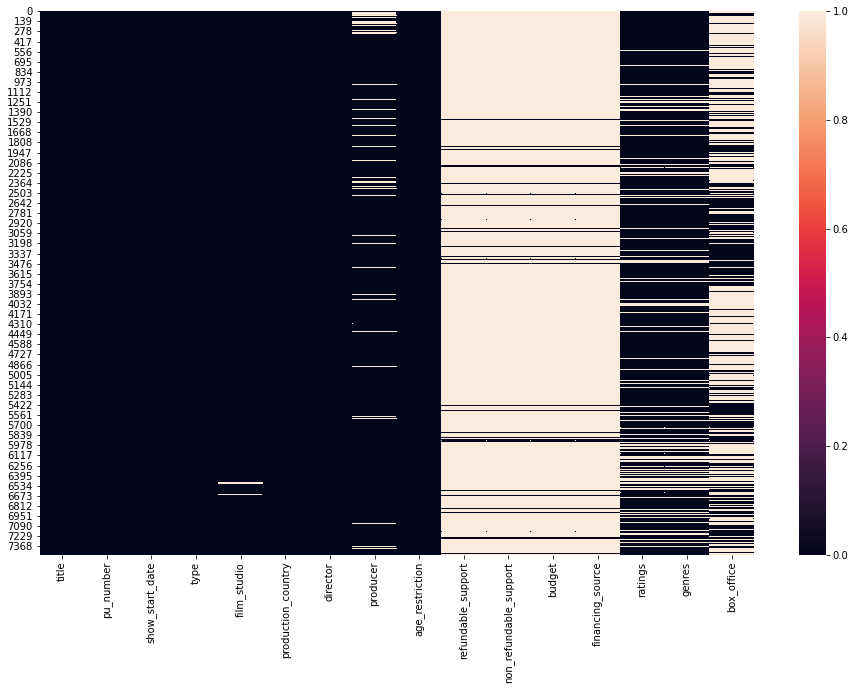

In [ ]:
# смотрим структуру
plt.figure(figsize=(16,10))
sns.heatmap(data.isna())
plt.show()

Большинство фильмов из нашего датафрейма не получали господдержку. Также (как мы уже обнаружили ранее), о больше чем половине неизвестна сумма кассовых сборов. Много тех, о которых неизвестен жанр и рейтинг (причем пропуски в данных столбцах почти всегда совпадают). Также хватает пропусков в информации о продюсере, и небольшое количество заметно в столбце с информацией о студии.

In [ ]:
data.isna().sum() # считаем количества

title                        0
pu_number                    0
show_start_date              0
type                         0
film_studio                 18
production_country           2
director                     9
producer                   568
age_restriction              0
refundable_support        7153
non_refundable_support    7153
budget                    7153
financing_source          7153
ratings                    966
genres                     975
box_office                4327
dtype: int64

У 18 фильмов неизвестна студия. Это слишком малое количество строк, чтобы повлиять на исследование, поэтому (хотя данный столбец и не участвует в исследовании) вместо замены, например, на 'unknown', их можно просто удалить. Также можно поступить со строками, не имеющих данных о режиссере и стране производства.

Удалим строки с пропусками в данных столбцах.

In [ ]:
data = data.dropna(subset = ['film_studio', 'production_country', 'director']) # "оптовый" вариант

In [ ]:
data.reset_index(drop = True, inplace=True) # сброс индексов, вариант записи без равно

In [ ]:
data.isna().sum() # проверка успешности удаления

title                        0
pu_number                    0
show_start_date              0
type                         0
film_studio                  0
production_country           0
director                     0
producer                   564
age_restriction              0
refundable_support        7126
non_refundable_support    7126
budget                    7126
financing_source          7126
ratings                    947
genres                     956
box_office                4303
dtype: int64

Строк с неизвестным продюссером у нас около 7% - это хоть и не слишком крупная часть данных, однако и сам датафрейм у нас небольшой. Так как информация о продюссере не будет участвовать в дальнейшем исследовании, чтобы не потерять содержащиеся в остальных строках данные мы произведем замену пропусков на указание о неизвестности продюссера.

In [ ]:
data['producer'] = data['producer'].fillna('unknown')

Столбцы `'refundable_support'` и `'non_refundable_support'` вероятно зависят от столбца `'budget'` (то есть пропуски в нем приводят к пропуску в остальных, что подтвержается совпадением количества пропусков и выявленной хитмэпом структурой датафрейма). А, как мы знаем из описания данных, значения в данном столбце имеют только те фильмы, которые получили господдержку. То есть технически, бюджет остальных равен нолю. Однако замена на ноль может приводить к заблуждению и неправильным подсчетам, поэтому пропуски в данном столце (и связанных с ним) мы трогать не будем. Вместо этого в следующих шагах введем дополнительный столбец булева типа для обозначения того, получал ли фильм господдержку или нет, а также посмотрим на сами столбцы более внимательно. А для анализа показателей господдержки будем использовать подходящий срез данных.

Пропуски в столбцах `'ratings'`, `'box_office'` и `'genres'` мешают оценить успешность фильмов в целом и конкретных жанров в частности. Пропусков в столбце с кассовыми сборами очень много (больше половины), но у многих сохранна информация касательно жанра и рейтинга (это позволит включить данные строки в исследование зависимости рейтинга от жанра). А вот не имеющие жанра и рейтинга строки потеряли сам важный параметр (жанр) и один (рейтинг) из двух (рейтинг и кассовые сборы) критериев оценки популярности фильмов для исследования, поэтому, если бы исследовали только это, их можно было бы удалить (вероятно, попытавшись сохранить строки с господдержкой для исследования получивших их фильмов, но таковых немного, поэтому удаление вряд ли сильно повлияло на результат). Однако полученное техзадание требует изучить и саму "динамику и распределение полноты" в сборе информации о кассовых сборах по годам, поэтому удаление строк с пропусками в столбцах с рейтингом и жанром не позволит нам качественно провести это исследование из-за больших потерь информации, ведущей к искажению результатов. Возможно в будущих шагах удасться восстановить значения для некоторых строк с пропусками в рейтинге и жанре, а для учета бюджета может потребоватья дополнительный столбец (тем более, что мы все равно собирались его создавать с более удобновоспринимаемыми зрительно ценами - работу над пропусками в случае необходимости можно будет провести и в нем). Поэтому пропуски в столбцах `'ratings'`,`'genres'` и `'box_office'`пока оставляем.

***Вывод***

В данных выявлено большое количество пропусков (например, в столбце `'box_office'` они составляют более половины!).

Из-за своего малого количества (недостаточного для искажения результатов) были удалены строки с пропусками в столбцах `'film_studio'`, `'production_country'`, `'director'`.

В столбце `'producer'` пропусков уже гораздо больше, однако столбец не участвует в дальнейшем исследовании, поэтому для сохранения данных в необходимых нам строках произведена замена пропусков на значение `'unknown'`.

Пропуски в столбцах `'ratings'`, `'genres'` ввиду их большого количества пришлось оставить, так как их удаление приведет к искажению в одном из поставленных в задачах исследовании, а удаление пропусков в `'box_office'` не только сделает невозможным проведение одного из разделов исследования (посвященного в том числе пропускам в данном столбце), но и из-за своего количества с большой долей вероятности привнесет искажения и в остальные. Возможно получится исправить ситуацию в будущих шагах.

#### Шаг 2.3. Изучите дубликаты в датафрейме
- Проверьте, есть ли в данных дубликаты. Опишите причины, которые могли повлиять на появление дублей.

Теперь, после оптимизации количества пропуском приступим к поиску дубликатов. Наибольшая вероятность их обноружения в столбцах с неколичесвенным типом данных.

Вспомним, какие это столбцы.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7458 non-null   object             
 1   pu_number               7458 non-null   int64              
 2   show_start_date         7458 non-null   datetime64[ns, UTC]
 3   type                    7458 non-null   object             
 4   film_studio             7458 non-null   object             
 5   production_country      7458 non-null   object             
 6   director                7458 non-null   object             
 7   producer                7458 non-null   object             
 8   age_restriction         7458 non-null   object             
 9   refundable_support      332 non-null    float64            
 10  non_refundable_support  332 non-null    float64            
 11  budget                  332 non-null    flo

Категориальные (например, `'type'`)  и условно-категориальные (в том числе те, где значений в одной строке может быть несколько, например, `'producer'`) оставим на потом.

Также возможны отличия в транскрибировании имен режиссеров, продюссеров, названий одних и тех же студий, может отличаться порядок их указания в столбце. Выловить такие дубли весьма проблематично.

Сейчас изучим более простые варианты.

##### Работа с названиями фильмов (часть 1)

Начнем со столбца `'title'`.

In [ ]:
len(data['title'].unique())

6745

In [ ]:
data['title'].value_counts()

День святого Валентина_             5
Шерлок Холмс                        4
Безумцы                             4
Робин Гуд (Robin Hood)              4
Начало_                             4
                                   ..
Чемодан.                            1
Вселенная косплея                   1
Человек, который убил Дон Кихота    1
Тебя никогда здесь не было          1
Искатель воды                       1
Name: title, Length: 6745, dtype: int64

У нас 6745 уникальных имен на 7458 строки. Но это объяснимо: один и тот же фильм может иметь несколько прокатных удостоверений, каждое из которых будет учитываться отдельной строкой. Как мы уже видели ранее, таким примером может быть фильм "Особо опасен".

Также мы можем заметить, что в названия вполне могут закрасться опечатки, или что-то похожее на них. А потому, если исправить их, то может быть уникальных названий станет еще меньше?

Посмотрим на все названия фильмов в нашем датафрейме.

In [ ]:
#pd.set_option('display.max_rows', None)
sorted(data['title'].unique())

[' Я ПРЕПОД',
 '"SOS" над тайгой',
 '"V" значит вендетта',
 '"АРТиШОК" анимационный альманах авторских фильмов',
 '"Бежин луг" Сергея Эйзенштейна',
 '"Державная" Размышления 100 лет спустя',
 '"Зеленое яблоко" анимационный альманах выпуск № 7',
 '"Машины песенки". Серия "Опять Новый Год!"',
 '"Море"',
 '"Сезон дождей", "Диета Матроскина", "Шарик хочет телефон" из анимационного сериала "Простоквашино"',
 '"Старый" Новый год',
 '"Уорнер Бразерс Пикчерз" и "Леджендари Пикчерз": Тихоокеанский рубеж',
 '"Фееринки". Серия "Фантик спешит на помощь"',
 '"Хороший день", "Бог из машины/Deus EX", "Голод", "Психотроника", "Темная ночь"',
 '"Чудовище из Простоквашино", "Ген героя", "Ненастоящий детектив", "Мама и Тама", "Как бы не стало зимы" из анимационного сериала "Простоквашино"',
 '#ВСЁ_ИСПРАВИТЬ!?!',
 '#Москва-Руаян',
 '#ЯВОЛОНТЕР Истории неравнодушных',
 '(Не)жданный принц',
 '(Не)идеальный мужчина',
 '... в стиле JAZZ',
 '... и я там был',
 '... имени Сергея Герасимова',
 '007 Координаты Ск

В некоторых названиях встречаются кавычки, которые выглядят странно, например - '"Море"' (ведь в остальных названиях двойные кавычки используются как кавычки или для ограничения назании серии, а не ограничения названия серии). Где-то - точки ('13.'), подчеркивания ('Ася_')  или пробелы ('Астрал 4: Последний ключ ') в конце названия. Где-то все указано прописными буквами ('АТАКА ТИТАНОВ. ФИЛЬМ ПЕРВЫЙ. ЖЕСТОКИЙ МИР' у первого фильма,  второй 'Атака титанов. Фильм второй: Конец света' уже имеет нормальное написание) - нарушение единообразия написания (кое-где тоже может привести к дублям). Где-то прописная буква может быть утеряна, что тоже ведет к появлению дублей ('Атлантида: Затерянный мир' и 'Атлантида: затерянный мир')

Какие-то выглядят как несколько названий серий, потерявших название сериала, к которому они относятся (например,'"Хороший день", "Бог из машины/Deus EX", "Голод", "Психотроника", "Темная ночь"').

Какие-то из названий как-будто потеряли часть ('... имени Сергея Герасимова'), или получили лишнее троеточие ('... в стиле JAZZ'), но так как установить настоящее будет проблематично, скорее всего придется их опустить.

Что-то ("Уорнер Бразерс Пикчерз" и "Леджендари Пикчерз": Тихоокеанский рубеж') включило в себя и название студий-создательниц.

Возможно, для серий из сериалов есть варианты написаний сериала и серий (на это стоит обратить внимание дополнительно), но у фильмов линейки "Ёлки" мы уже видим несколько вариантов написаний. 'Аполлон 18' и 'Аполлон-11' также написаны по-разному, но их мы трогать не будем, так как вряд ли это серии сериала.

Названия 'Агент Джонни Инглиш 2: Перезагрузка' и 'Агент Джонни Инглиш: Перезагрузка' выглядят как один и тот же фильм (только у второго утеряна двойка). И очевидный неявный дубль 'Астрал. Глава 2' и 'Астрал. Глава вторая'.

И даже в том, что выводится на экран, видны дубли. Обнаружить и исправить их все весьма проблематично, однако попробуем заменить хотя бы некоторые из найденных проблем.

Так как иногда фильмы могут носить одинаковое название, замену производить придется очень аккуратно. Вдруг на самом деле это разные фильмы, и точки и прочие это была попытка хоть как-то их отличить друг от друга?

Так как названий, к которым есть вопросы, много, то будем исправлять их по мере анализа, чтобы не упустить потом.

In [ ]:
data.loc[(data['title'] == '300 спартанцев /По роману-комиксу Фрэнка Миллера и Линн Варли/')\
         |(data['title'] =='300 спартанцев: Расцвет империи /По произведению Фрэнка Миллера "Ксеркс"/')\
         |(data['title'] =='300 спартанцев: Расцвет империи /По произведению Фрэнка Миллера "Ксеркс"/.')]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1828,300 спартанцев: Расцвет империи /По произведен...,121001914,2014-02-06 12:00:00+00:00,Художественный,"Уорнер Бразерс, Леджендари Пикчерз, Круэль/Уну...",США,Ноам Мурро,"Марк Кэнтон, Джанни Нуннари, Дебора Снайдер, З...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.6,"фэнтези,боевик,военный",NaN
2090,300 спартанцев: Расцвет империи /По произведен...,221014914,2014-05-27 12:00:00+00:00,Художественный,"Уорнер Бразерс, Леджендари Пикчерз, Круэль/Уну...",США,Ноам Мурро,"Марк Кэнтон, Джанни Нуннари, Дебора Снайдер, З...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"фэнтези,боевик,военный",NaN
4182,300 спартанцев /По роману-комиксу Фрэнка Милле...,221140410,2010-12-07 12:00:00+00:00,Художественный,"Уорнер Бразерс, Леджендари Пикчерз, Верчуал Ст...",США,Зак Снайдер,"Берни Голдманн, Марк Кэнтон, Джанни Нуннари, Д...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"боевик,драма",NaN


Вариант на английском языке мы не брали, так как прокат на иностранном сложно считать дублем. А вот 'Расцвет империи' у нас оказался в двух вариантах написания.

Исправим это.

In [ ]:
data['title'] = (data['title'].replace('300 спартанцев: Расцвет империи /По произведению Фрэнка Миллера "Ксеркс"/.',\
                                       '300 спартанцев: Расцвет империи /По произведению Фрэнка Миллера "Ксеркс"/', regex=True))

In [ ]:
data.loc[(data['title'] == 'Weekend  (Уик-энд)')|(data['title'] =='Weekend  (Уик-энд).')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1479,Weekend (Уик-энд),111014713,2013-12-24 12:00:00+00:00,Художественный,"ООО ""Киностудия ""ВЕРТИКАЛЬ""",Россия,С.Говорухин,"С.Говорухин, Е.Маскина",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.4,мелодрама,7755.0
1980,Weekend (Уик-энд).,111008914,2014-08-13 12:00:00+00:00,Художественный,"ООО ""Киностудия ""ВЕРТИКАЛЬ""",Россия,С.Говорухин,"С.Говорухин, Е.Маскина",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,мелодрама,38044.0


Один и тот же фильм. Но с разным рейтингом (разные версии? или законодательство менялось?). Пока трогать не будем.

In [ ]:
#data['title'] = (data['title'].str.replace('Weekend  (Уик-энд).','Weekend  (Уик-энд)', regex=True))

In [ ]:
data.loc[(data['title'] == 'Алиса в стране чудес /По книгам Льюиса Кэрролла "Алиса в стране чудес" и "Алиса в Зазеркалье"/')|\
         (data['title'] =='Алиса в стране чудес /По одноименному произведению Льюиса Кэрола/')]  # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3823,Алиса в стране чудес /По книгам Льюиса Кэрролл...,121002610,2010-02-25 12:00:00+00:00,Художественный,"Рот Филмз, Тим Тодд, Тим Бартон Продакшнз, Уол...",США,Тим Бартон,"Тим Бартон, Ричард Д.Занук, Джо Рот, Дженнифер...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фэнтези,приключения,семейный",7503.0
3912,Алиса в стране чудес /По книгам Льюиса Кэрролл...,221058010,2010-04-16 12:00:00+00:00,Художественный,"Рот Филмз, Тим Тодд, Тим Бартон Продакшнз, Уол...",США,Тим Бартон,"Тим Бартон, Ричард Д.Занук, Джо Рот, Дженнифер...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фэнтези,приключения,семейный",NaN
4693,Алиса в стране чудес /По одноименному произвед...,121004810,2010-03-15 12:00:00+00:00,Художественный,"Род Филмз, Тим Тодд, Тим Бартон Продакшенз, Уо...",США,Тим Бартон,Тим Бартон,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фэнтези,приключения,семейный",NaN


Один и тот же фильм, но в одной из вариаций неполностью указан "продюссерский состав".

Унифицируем названия. Продюссерский состав также можно было бы дополнить, но так как этот столбце в исследованиях не участвует, делать это не обязательно. Но попробовать можно.

In [ ]:
#data.loc[data['title'] == 'Алиса в стране чудес /По одноименному произведению Льюиса Кэрола/', 'producer'] =\
#data.loc[data['title'] == 'Алиса в стране чудес /По книгам Льюиса Кэрролла "Алиса в стране чудес" и "Алиса в Зазеркалье"/',\
#         'producer'] # приводит к NaN

Первая попытка приводит к появлению пропуска. Возможно, это потому, что у нас несколько строк, откуда можно взять информацию, и, хоть они и одинаковые в нужной ячейке.

Для конкретизации придется несколько усложнять код.

In [ ]:
full_producers_alice =\
data.loc[data['title'] == 'Алиса в стране чудес /По книгам Льюиса Кэрролла "Алиса в стране чудес" и "Алиса в Зазеркалье"/',\
         'producer'].unique()

In [ ]:
if len(full_producers_alice) > 0:
    full_producer_alice = full_producers_alice[0]

In [ ]:
data.loc[data['title'] == 'Алиса в стране чудес /По одноименному произведению Льюиса Кэрола/',\
         'producer'] = full_producer_alice

In [ ]:
data['title'] = (data['title'].replace(['Алиса в стране чудес /По книгам Льюиса Кэрролла "Алиса в стране чудес" и "Алиса в Зазеркалье"/',\
                                            'Алиса в стране чудес /По одноименному произведению Льюиса Кэрола/'],\
                                           'Алиса в стране чудес (реж. Тим Бартон)', regex=True))

In [ ]:
data.loc[data['title'] == 'Алиса в стране чудес (реж. Тим Бартон)']

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3823,Алиса в стране чудес (реж. Тим Бартон),121002610,2010-02-25 12:00:00+00:00,Художественный,"Рот Филмз, Тим Тодд, Тим Бартон Продакшнз, Уол...",США,Тим Бартон,"Тим Бартон, Ричард Д.Занук, Джо Рот, Дженнифер...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фэнтези,приключения,семейный",7503.0
3912,Алиса в стране чудес (реж. Тим Бартон),221058010,2010-04-16 12:00:00+00:00,Художественный,"Рот Филмз, Тим Тодд, Тим Бартон Продакшнз, Уол...",США,Тим Бартон,"Тим Бартон, Ричард Д.Занук, Джо Рот, Дженнифер...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фэнтези,приключения,семейный",NaN
4693,Алиса в стране чудес (реж. Тим Бартон),121004810,2010-03-15 12:00:00+00:00,Художественный,"Род Филмз, Тим Тодд, Тим Бартон Продакшенз, Уо...",США,Тим Бартон,"Тим Бартон, Ричард Д.Занук, Джо Рот, Дженнифер...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фэнтези,приключения,семейный",NaN


Преобразование прошло успешно. Продолжаем изучать возможные дубли.

In [ ]:
data.loc[(data['title'] == 'Агент Джонни Инглиш 2: Перезагрузка')\
         |(data['title'] =='Агент Джонни Инглиш: Перезагрузка')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
402,Агент Джонни Инглиш: Перезагрузка,221000112,2012-01-16 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Студио Канал, Уоркинг Тайтл...",Великобритания - Израиль - Франция - Япония - США,Оливер Паркер,"Тим Биван, Крис Кларк, Эрик Феллнер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.6,"комедия,боевик,приключения",NaN
1065,Агент Джонни Инглиш 2: Перезагрузка,221054612,2012-07-11 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Студио Канал, Уоркинг Тайтл...",Великобритания - Израиль - Франция - Япония - США,Оливер Паркер,"Тим Биван, Крис Кларк, Эрик Феллнер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.6,"комедия,боевик,приключения",NaN
4987,Агент Джонни Инглиш: Перезагрузка,121015411,2011-09-01 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Студио Канал, Уоркинг Тайтл...",Великобритания - Израиль - Франция - Япония - США,Оливер Паркер,"Тим Биван, Крис Кларк, Эрик Феллнер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.6,"комедия,боевик,приключения",800.0


Судя по близким датам проката и совпадению в остальных столбцах - это один и тот же фильм. Унифицируем название.

In [ ]:
data['title'] = (data['title'].str.replace('Агент Джонни Инглиш: Перезагрузка','Агент Джонни Инглиш 2: Перезагрузка'))

In [ ]:
data.loc[(data['title'] == 'Анализируй то!')|(data['title'] =='Анализируй это!')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
4543,Анализируй это!,221147310,2010-12-15 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5055,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5056,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.8,"комедия,криминал",NaN


Это похоже на разные фильмы, так как они имеют разные возрастные рейтинги и оценки, но снятые одной командой и студиями (просто в разной транслитерации), и в одном из фильмов сотрудничающих с дополнительной страной.

Но при этом у разных фильмов совпадает одно из двух удостоверений. Это может быть как ошиька при внесении в базу, так и может быть их действительно дали одно на двоих.

In [ ]:
data.loc[(data['title'] == 'Ангел')|(data['title'] =='Ангел _')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
5038,Ангел _,111007111,2011-10-17 12:00:00+00:00,Художественный,"ЗАО ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,3.9,"боевик,триллер,криминал",6711.0
6629,Ангел,121031018,2019-01-31 12:00:00+00:00,Художественный,"Эль Десео, Институто Националь де Сине и Артес...","Аргентина, Испания",Луис Ортега,"Агустин Альмодовар, Педро Альмодовар, Летисия ...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,3.9,"боевик,триллер,криминал",5712897.7


Фильмы разные. Лучше как-то обозначить это.

In [ ]:
data['title'] = (data['title'].str.replace('Ангел _','Ангел (2011)'))

In [ ]:
data.loc[(data['title'] == 'Ангел-хранитель.')|(data['title'] == 'Ангел-хранитель._')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1196,Ангел-хранитель.,121002713,2013-02-07 12:00:00+00:00,Художественный,"Уорнер Бразерс Филм Пролдуцион Германи, Байреф...",Германия,Тиль Швайгер,"Вилли Гейке, Поль Мауриц, Томас Циквер, Тиль Ш...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.8,"драма,боевик",NaN
2263,Ангел-хранитель._,221019614,2014-07-08 12:00:00+00:00,Художественный,"Уорнер Бразерс Гмбх, Бэарфут Филмз",Германия,Тиль Швайгер,"Вилли Гейке, Пол Мориц, Томас Циквер, Тиль Шва...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.8,"драма,боевик",250.0


Один и тот же фильм. Унифицируем название.

In [ ]:
data['title'] = (
    data['title']
    .replace(['Ангел-хранитель.', 'Ангел-хранитель._'], 'Ангел-хранитель', regex=True)
)

In [ ]:
data.loc[(data['title'] == 'БОРИС ГОДУНОВ')|(data['title'] == 'Борис Годунов')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
75,Борис Годунов,111012213,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", ""Баррандов"" (ЧССР) при...","СССР, ЧССР, Западный Берлин, ПНР",С.Бондарчук,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.2,драма,420.0
5209,БОРИС ГОДУНОВ,111007411,2011-10-21 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""Парсуна""",Россия,В.Мирзоев,"Н.Егорова, В.Мирзоев",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.2,драма,NaN


Разные. Визуальное отличия в названии вполне заметное (у фильма производства РФ все буквы прописные). Но лучше обозначить отличия иначе, например, годом выхода.

In [ ]:
data['title'] = (data['title'].str.replace('БОРИС ГОДУНОВ','Борис Годунов (2011)'))

In [ ]:
data.loc[(data['title'] == 'Беглецы')|(data['title'] == 'Беглецы -')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1839,Беглецы -,111006014,2014-06-06 12:00:00+00:00,Художественный,"НП ""Интерфест"", ООО ""Компания ""РЕАЛ-ДАКОТА"".",Россия,Р.Мосафир,"Р.Давлетьяров, А.Котелевский, А.Новиков",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.2,"фантастика,боевик,драма",NaN
6259,Беглецы,121021918,2018-10-30 12:00:00+00:00,Художественный,Форма Про Филмз,Латвия - Россия,А.Оганесян,"Ю.Зайцева, М.Павлов, И.Пронин",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.2,"фантастика,боевик,драма",1342679.0


Разные. Обозначим один из вариантов более явно.

In [ ]:
data['title'] = (data['title'].str.replace('Беглецы -','Беглецы (реж.Р.Мосафир)')) # переименовываем

In [ ]:
data.loc[(data['title'] == 'Адъютант его превосходительства')|(data['title'] =='Адъютант его превосходительства.')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
44,Адъютант его превосходительства,211044013,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Ташков,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.2,"военный,приключения,драма",NaN
1472,Адъютант его превосходительства.,111010713,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Ташков,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.2,"военный,приключения,драма",NaN


Один фильм. Унифицируем название.

In [ ]:
data['title'] = (data['title'].replace('Адъютант его превосходительства.','Адъютант его превосходительства', regex = True)) # переименовываем

In [ ]:
data.loc[(data['title'] == 'Белые ночи (2017)')|(data['title'] =='Белые ночи.')\
         |(data['title'] =='Белые ночи почтальона Алексея Тряпицына')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2103,Белые ночи.,111000815,2015-02-05 12:00:00+00:00,Художественный,"Киностудия ""Ленфильм""",Россия,Л.Квинихидзе,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.0,"драма,музыка",NaN
2371,Белые ночи почтальона Алексея Тряпицына,111010014,2014-09-15 12:00:00+00:00,Художественный,"ООО ""Кинокомпания Андрея Кончаловского""",Россия,А.Кончаловский,А.Кончаловский,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.9,драма,900.0
3735,Белые ночи (2017),111004517,2017-06-15 12:00:00+00:00,Художественный,"ООО ""Россфильм""",Россия,"Т.Воронецкая, А.Богатырев",Е.Белова,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,5.9,драма,NaN


Три разных фильма. Теоретически, названия выглядят различимо между собой, переименовывать не будем.

In [ ]:
data.loc[(data['title'] == 'Близнецы')|(data['title'] =='Близнецы_')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3820,Близнецы_,121003204,2010-12-31 12:00:00+00:00,Художественный,"Эмперор Мультимедиа Груп, Миллион Чэннел",Гонконг,Данте Лам,"Бей Логан, Карл Чанг",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"комедия,криминал",3010.0
6471,Близнецы,121028318,2018-12-06 12:00:00+00:00,Художественный,"Диджитал Интерференсе Продюксьон, Хадрон Филмс",Канада,Брэндон Кристенсен,"Крис Болл, Кертис Дэвид Хардер, Колин Минихан",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"комедия,криминал",7179466.0


Разные. Обозначим один из них дополнительно для лучшего отличия.

In [ ]:
data['title'] = (data['title'].str.replace('Близнецы_','Близнецы (Гонконг)')) # переименовываем

In [ ]:
data.loc[(data['title'] == 'Бабочки (2016)')|(data['title'] =='Бабочки')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3221,Бабочки (2016),112000117,2017-04-03 12:00:00+00:00,Документальный,ИП Тихон Николаевич Пендюрин,Россия,Д.Кубасов,Т.Пендюрин,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.4,"документальный,драма",NaN
6549,Бабочки,114009818,2018-12-29 12:00:00+00:00,Анимационный,"ООО Студия ""ШАР""",Россия,Е.Хломова,"Н.Маковский, А.Хржановский",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,8.2,"фантастика,триллер,драма",NaN


И это тоже разные.

In [ ]:
data.loc[(data['title'] == 'Беспредел (Outrage; Autoreiji)')|(data['title'] =='Беспредел _')]  # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
62,Беспредел _,111006515,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"" , Студия ""Ритм""",СССР,И.Гостев,unknown,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.8,"драма,криминал",NaN
689,Беспредел (Outrage; Autoreiji),121010613,2013-04-16 12:00:00+00:00,Художественный,"Бандай Визуал Компани, Офис Китано, Омнибус Яп...",Япония,Такеши Китано,"Такио Ёсида, Такеши Китано, Масаюки Мори",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.1,"криминал,драма,триллер",NaN


И это тоже. Но нижнее подчеркивание в названии выглядит как опечатка (хоть на самом деле это похоже на попытку отличить один фильм от другого), поэтому придадим назавнию более эстетичный вид.

In [ ]:
data['title'] = (data['title'].str.replace('Беспредел _','Беспредел (СССР)')) # переименование

In [ ]:
data.loc[(data['title'] == 'Ближе, чем кажется (2017)')|(data['title'] =='Ближе, чем кажется')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3013,"Ближе, чем кажется",111020015,2015-12-07 12:00:00+00:00,Художественный,"ООО ""Продюсерский центр ""Молодёжные инициативы""",Россия,"Г.Дюкарев, А.Рубинштейн, А.Ким, М.Воскобоев, Н...","Ф.Абрютин, Д.Якунин, С.Кучмаева, И.Щербань, О...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.1,семейный,42176.0
3730,"Ближе, чем кажется (2017)",211010017,2017-03-14 12:00:00+00:00,Художественный,"ООО ""Продюсерский центр ""Молодёжные инициативы""",Россия,Н.Беляускене,"Ф.Абрютин, Д.Якунин, И.Селиванов, О.Филонова, ...",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.1,семейный,NaN


Снова разные.

In [ ]:
data.loc[(data['title'] == 'Бой без правил')|(data['title'] =='Бои без правил')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3960,Бой без правил,221049310,2010-03-30 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Мишер Филмз, Рилейтивити Ме...",США,Дито Монтиель,Кевин Мишер,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.3,"драма,спорт,боевик",NaN
6233,Бои без правил,121020618,2018-09-20 12:00:00+00:00,Художественный,"Сеньёрита Филмз, Индочайна Продюксьон, Ханвей ...",Франция - Великобритания - Камбоджа - США - КНР,Жан-Стефан Совер,"Рой Болтер, Рита Дэгер, Сол Пападопулос, Никол...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.4,"боевик,драма,криминал",7052504.0


Опять не дубль.

In [ ]:
data.loc[(data['title'] == 'Большая игра / Big Game')|(data['title'] =='Большая игра')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2562,Большая игра / Big Game,121007315,2015-04-03 12:00:00+00:00,Художественный,"Сабзеро Филм Интертейнмент, Алтитьют Филм Инте...",Финляндия - Великобритания - Германия,Ялмари Хеландер,"Петри Йокиранта, Уилл Кларк, Энди Мэйсон",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.6,"драма,криминал,биография",14463770.50
5659,Большая игра,121027917,2018-01-11 12:00:00+00:00,Художественный,"Интертейнмент Уан, Паскаль Пикчерз, Марк Гордо...",США,Аарон Соркин,"Марк Гордон, Эми Паскаль",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.6,"драма,криминал,биография",77806917.35
6647,Большая игра,111001819,2019-02-28 12:00:00+00:00,Художественный,"ООО ""ГГФ"" по заказу АО ""Сеть телевизионных ста...",Россия,Б.Батуллин,А.Марченко,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"драма,криминал,биография",NaN


А тут вообще три разных фильма, у двух из которых названия совпадают. Попробуем их как-то обозначить.

In [ ]:
# переименование
data.loc[(data['production_country'] == 'США')&(data['title'] =='Большая игра'),'title'] = 'Большая игра (США)'

In [ ]:
# переименование
data.loc[(data['production_country'] == 'Россия')&(data['title'] =='Большая игра'),'title'] = 'Большая игра (Россия)'

In [ ]:
data.loc[(data['title'] == 'Большая игра / Big Game')|\
         (data['title'] =='Большая игра')|(data['title'] =='Большая игра (США)')\
        |(data['title'] =='Большая игра (Россия)')] # проверка успешности переименования

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2562,Большая игра / Big Game,121007315,2015-04-03 12:00:00+00:00,Художественный,"Сабзеро Филм Интертейнмент, Алтитьют Филм Инте...",Финляндия - Великобритания - Германия,Ялмари Хеландер,"Петри Йокиранта, Уилл Кларк, Энди Мэйсон",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.6,"драма,криминал,биография",14463770.50
5659,Большая игра (США),121027917,2018-01-11 12:00:00+00:00,Художественный,"Интертейнмент Уан, Паскаль Пикчерз, Марк Гордо...",США,Аарон Соркин,"Марк Гордон, Эми Паскаль",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.6,"драма,криминал,биография",77806917.35
6647,Большая игра (Россия),111001819,2019-02-28 12:00:00+00:00,Художественный,"ООО ""ГГФ"" по заказу АО ""Сеть телевизионных ста...",Россия,Б.Батуллин,А.Марченко,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"драма,криминал,биография",NaN


Обозначили успешно. Смотрим дальше.

In [ ]:
data.loc[(data['title'] == 'Больше, чем любовь "Любимая женщина режиссера Тодоровского"')\
         |(data['title'] =='Больше, чем любовь.')\
         |(data['title'] =='Больше, чем любовь_')]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
774,"Больше, чем любовь_",221001213,2013-02-11 12:00:00+00:00,Художественный,"Майл Най Продакшнс, Тачстоун Пикчерз, Бикон Пи...",США,Найджел Коул,Армийан Бернстейн,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.5,"драма,мелодрама,комедия",NaN
3825,"Больше, чем любовь.",221031510,2010-02-18 12:00:00+00:00,Художественный,"Майл Най Продакшнс, Тачстоун Пикчерз, Бикон Пи...",США,Найджел Коул,Армийан Бернстейн,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.5,"драма,мелодрама,комедия",NaN
6175,"Больше, чем любовь ""Любимая женщина режиссера ...",112007218,2018-09-03 12:00:00+00:00,Документальный,"ООО ""Студия ""Фишка-фильм""",Россия,Т.Малова,А.Радов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Два дубля и один - нет. Исправляем имена дублей.

In [ ]:
data.loc[(data['production_country'] == 'США')&(data['title'] =='Больше, чем любовь.'),'title'] = 'Больше, чем любовь (США)'

In [ ]:
data.loc[(data['production_country'] == 'США')&(data['title'] =='Больше, чем любовь_'),'title'] = 'Больше, чем любовь (США)'

In [ ]:
data.loc[(data['title'] == 'Вероника решает умереть (2009)')|(data['title'] =='Вероника решает умереть')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2881,Вероника решает умереть (2009),121008416,2016-04-11 12:00:00+00:00,Художественный,"Дас Филмз, Фьюче Филмз, Вельвет Интертейнмент,...",США,Эмили Янг,"Джонатан Бросс, Срирам Дас",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"драма,мелодрама",NaN
4148,Вероника решает умереть,121005110,2010-03-09 12:00:00+00:00,Художественный,"Дас Филмз, Фьюче Филмз, Вельвет Интертейнмент,...",США,Эмили Янг,"Джонатан Бросс, Срирам Дас",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.6,"драма,мелодрама",NaN
4377,Вероника решает умереть,221046510,2010-03-23 12:00:00+00:00,Художественный,"Дас Филмз, Фьюче Филмз, Вельвет Интертейнмент,...",США,Эмили Янг,"Джонатан Бросс, Срирам Дас",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.6,"драма,мелодрама",NaN


Фильм явно один и тот же. А вот рейтинг поменялся. Может быть при прокате его в 2016 году требования поменялись? Пожалуй, трогать его не стоит.

In [ ]:
data.loc[(data['title'] == 'Визит (2015)')|(data['title'] =='Визит')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1575,Визит,111003814,2014-04-10 12:00:00+00:00,Художественный,"ГУП Республики Башкортостан Киностудия ""Башкор...",Россия,Б.Юсупов,unknown,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.1,"ужасы,триллер,детектив",NaN
2607,Визит (2015),221029816,2016-06-21 12:00:00+00:00,Художественный,"Блиндинг Эдж Пикчерз, Блюмхауз Продакшнз",США,М. Найт Шьямалан,"Джейсон Блум, Марк Бьенсток, М. Найт Шьямалан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.1,"ужасы,триллер,детектив",NaN
2608,Визит (2015),221025116,2016-05-30 12:00:00+00:00,Художественный,"Блиндинг Эдж Пикчерз, Блюмхауз Продакшнз",США,М. Найт Шьямалан,"Джейсон Блум, Марк Бьенсток, М. Найт Шьямалан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.1,"ужасы,триллер,детектив",NaN
2609,Визит (2015),121015315,2015-07-23 12:00:00+00:00,Художественный,"Блиндинг Эдж Пикчерз, Блюмхауз Продакшнз",США,М. Найт Шьямалан,"Джейсон Блум, Марк Бьенсток, М. Найт Шьямалан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.1,"ужасы,триллер,детектив",37100479.2


Тоже два разных фильма.

In [ ]:
data.loc[(data['title'] == 'Викинг 18+')|(data['title'] =='Викинг .')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3301,Викинг .,111018416,2016-12-22 12:00:00+00:00,Художественный,"ЗАО ""ВИКИНГ"" Продакшен""",Россия,А.Кравчук,"ООО ""Централ Партнершип"", ЗАО ""Дирекция Кино""",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.2,"история,драма,боевик",54532167.93
3302,Викинг 18+,111018516,2016-12-22 12:00:00+00:00,Художественный,"ЗАО ""ВИКИНГ"" Продакшен""",Россия,А.Кравчук,"ООО ""Централ Партнершип"", ЗАО ""Дирекция Кино""",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,4.5,"история,драма",52494731.90


А это, видимо, две версии одного и того же фильма. Не трогаем.

In [ ]:
data.loc[(data['title'] == 'Возмездие-')\
         |(data['title'] =='Возмездие._')\
         |(data['title'] =='Возмездие_')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
90,Возмездие_,111013213,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,А.Столпер,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.7,"драма,боевик",NaN
1476,Возмездие._,121007714,2014-04-25 12:00:00+00:00,Художественный,"Арчер Стрит Продакшнз, Лэтитъюд Медиа, Лайонсг...",Австралия-Великобритания,Джонатан Теплицки,"Крис Браун, Билл Кёрбишли, Энди Пэтерсон",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"драма,боевик",NaN
4334,Возмездие-,121000910,2010-01-21 12:00:00+00:00,Художественный,"Уорнер Бразерс, ДжиКей Филмз",США-Великобритания,Мартин Кэмпбэл,"Тим Хэдингтон, Грэхэм Кинг",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"драма,боевик",NaN


Три разных фильма. Попытаемся их разделить

In [ ]:
data['title'] = (
    data['title'].str.replace('Возмездие-', 'Возмездие (реж.Кэмпбэл)')\
    .replace('Возмездие._', 'Возмездие (реж.Теплицки)', regex=True)\
    .replace( 'Возмездие_', 'Возмездие (реж.А.Столпер)', regex=True)\
)

In [ ]:
data.loc[(data['title'] == 'В поисках Немо.')|(data['title'] =='В поисках Немо_')] # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1141,В поисках Немо.,124002012,2012-09-05 12:00:00+00:00,Анимационный,"Уолт Дисней Пикчерз, Пиксар Анимейшн Студиос, ...",США,"Эндрю Стэнтон, Ли Ункрич",Грэм Уолтерс,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.9,"мультфильм,комедия,приключения",40995.0
1230,В поисках Немо_,224024612,2012-10-23 12:00:00+00:00,Анимационный,"Уолт Дисней Пикчерз, Пиксар, Буена Виста Интер...",США,"Ли Анкрич, Эндрю Стентон",Грехем Волтерс,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.9,"мультфильм,комедия,приключения",NaN


Один и тот же мульфильм. Но вот фамилия продюссера указана по-разному, имена режиссеров - в разном порядке, и студии именуются тоже по-своему.

Попробуем исправить это.

In [ ]:
data.loc[data['title'] == 'В поисках Немо_', 'film_studio'] =\
data.query('title == "В поисках Немо."')['film_studio'].unique()

In [ ]:
data.loc[data['title'] == 'В поисках Немо_', 'director'] =\
data.query('title == "В поисках Немо."')['director'].unique()

In [ ]:
data.loc[data['title'] == 'В поисках Немо_', 'producer'] =\
data.query('title == "В поисках Немо."')['producer'].unique()

In [ ]:
data['title'] = (data['title'].replace(['В поисках Немо_','В поисках Немо.'], 'В поисках Немо', regex=True)) # переименование

In [ ]:
data.loc[(data['title'] == 'Ведьма')|(data['title'] =='Ведьма .')]  # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1908,Ведьма .,111002215,2015-03-05 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,«16+» - для детей старше 16 лет,0.0,34000000.0,48571430.0,Министерство культуры,7.4,"фэнтези,приключения,драма",51907.5
6824,Ведьма,121007219,2019-04-12 12:00:00+00:00,Художественный,"Партс энд Лэйбор, Код Рэд Продакшнз, Мейден Во...",США - Бразилия - Великобритания - Канада,Роберт Эггерс,"Дэниэл Бекерман, Ларс Кнудсен, Джоди Редмонд, ...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.4,"фэнтези,приключения,драма",NaN


Хоть и одних жанров и с одинаковым рейтингом на Кинопоиске, но это разные фильмы. Обозначим это.

In [ ]:
data['title'] = (data['title'].replace('Ведьма .','Ведьма (Россия)', regex=True)) # переименование

In [ ]:
data.loc[(data['title'] == 'Вечеринка')|(data['title'] =='Вечеринка .')]  # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1632,Вечеринка .,121027113,2013-10-25 12:00:00+00:00,Художественный,"Телекино Синема, Телеспейн 2000, Лианеро Фильм",Испания,Мигель Ларрайа Валенсуела,"Альваро Аугустин, Беатрис Делгадо, Томас Симад...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.5,"драма,комедия",735.0
5644,Вечеринка,121026517,2017-12-21 12:00:00+00:00,Художественный,"Адвенчур Пикчерз, Оксвик Медиа",Великобритания,Салли Поттер,"Курбан Кассам, Кристофер Шеппард",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.5,"драма,комедия",5345387.0


Разные. Обозначим это.

In [ ]:
data.loc[(data['production_country'] == 'Испания')&(data['title'] =='Вечеринка .'),'title'] = 'Вечеринка (Испания)'

In [ ]:
data.loc[(data['production_country'] == 'Великобритания')&(data['title'] =='Вечеринка'),'title'] = 'Вечеринка (Великобритания)'

Дополнительно произведем замену того, что еще удалось обнаружить в видимой части. Точки, подчеркивания или пробелы в конце тоже можно исправлять не всегда (так как это где-то имеет лишь эстетический смысл, а где-то является попыткой обозначить разные фильмы с одним и тем же названием), поэтому исправлению подвергнутся не все такие "артефакты".

А также попробуем избежать проблем чередования Ё и Е.

In [ ]:
data['title'] = (
    data['title']
    .str.replace('ё','е')
    .replace('Ё','Е', regex=True)
    .replace('Ёлки - 2', 'Ёлки 2', regex=True)
    .replace('Алиса знает, что делать! Зеленая месть', 'Алиса знает, что делать! Серия "Зеленая месть"', regex=True)
    .replace('Атлантида: затерянный мир', 'Атлантида: Затерянный мир', regex=True)
    .replace('АТАКА ТИТАНОВ. ФИЛЬМ ПЕРВЫЙ. ЖЕСТОКИЙ МИР.', 'Атака титанов. Фильм второй: Жестокий мир', regex=True)
    .replace('Астрал. Глава вторая', 'Астрал. Глава 2', regex=True)
    .replace('Блэйд. Троица', 'Блэйд: Троица', regex=True)
)

Посмотрим, что у нас получилось.

In [ ]:
len(data['title'].unique())

6734

In [ ]:
sorted(data['title'].unique())

[' Я ПРЕПОД',
 '"SOS" над тайгой',
 '"V" значит вендетта',
 '"АРТиШОК" анимационный альманах авторских фильмов',
 '"Бежин луг" Сергея Эйзенштейна',
 '"Державная" Размышления 100 лет спустя',
 '"Зеленое яблоко" анимационный альманах выпуск № 7',
 '"Машины песенки". Серия "Опять Новый Год!"',
 '"Море"',
 '"Сезон дождей", "Диета Матроскина", "Шарик хочет телефон" из анимационного сериала "Простоквашино"',
 '"Старый" Новый год',
 '"Уорнер Бразерс Пикчерз" и "Леджендари Пикчерз": Тихоокеанский рубеж',
 '"Фееринки". Серия "Фантик спешит на помощь"',
 '"Хороший день", "Бог из машины/Deus EX", "Голод", "Психотроника", "Темная ночь"',
 '"Чудовище из Простоквашино", "Ген героя", "Ненастоящий детектив", "Мама и Тама", "Как бы не стало зимы" из анимационного сериала "Простоквашино"',
 '#ВСЕ_ИСПРАВИТЬ!?!',
 '#Москва-Руаян',
 '#ЯВОЛОНТЕР Истории неравнодушных',
 '(Не)жданный принц',
 '(Не)идеальный мужчина',
 '... в стиле JAZZ',
 '... и я там был',
 '... имени Сергея Герасимова',
 '007 Координаты Ск

Количество дубликатов стало меньше, переименования произошли успешно.

***Выводы***

В столбце `'title'` отсутствует аккуратность и единообразие внесения данных, что приводит к проблемам в поиске и отделении дубликатов.

После переименования обнаруженных дубликатов, их количество сократилось.

Для исключения проблем с неочивидными дубликатами в будущем и снижения человеческого фактора при внесении данных следует выработать и применять единый стандарт для записи данной информации (например, одноименные фильмы дополнительно обозначать либо именем режиссера, или годом выхода для того, чтобы их можно было различить).

#### Работа со скрытыми дубликатами

Как мы уже успели убедиться - осматривать датафрейм самостоятельно достаточно утомительно и можно что-то упустить. Попробуем поискать скрытые дубликаты уже иным путем.

In [ ]:
data.duplicated(subset=['title', 'show_start_date','type']).sum()

8

Обнаружено 8 строк-вероятных скрытых дубликатов. Взглянем на них.

In [ ]:
data[data.duplicated(subset=['title','show_start_date','type'])]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1299,Эпидемия_,221035513,2013-10-07 12:00:00+00:00,Художественный,"Морена Фильм, Ребелион Террестр, А 3 Медиа Гру...",Испания - Франция,"Алекс Пастор, Давид Пастор","Мерседес Гамеро, Альберто Марини, Педро Уриоль",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.2,"драма,фантастика,триллер",NaN
1472,Адъютант его превосходительства,111010713,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Ташков,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.2,"военный,приключения,драма",NaN
1474,Оторвы,221013214,2014-04-07 12:00:00+00:00,Художественный,"Проминент Пикчерз, Ворлдвью Интертейнмент, Инд...",США,Кристофер Нельсон,"Молли Коннерс, Хезер Рэй",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,3.5,"комедия,приключения",NaN
2188,Последние пять лет.,121005715,2015-03-25 12:00:00+00:00,Художественный,"Гранд Пикс Интертейнмент, Лаки Манки Пикчерз, ...",США,Ричард ЛаГравенес,"Джанет Бреннер, Лорен Версель, Курт Дойтч, Рич...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.7,"мюзикл,драма,мелодрама",52495.0
2749,Пингвиненок Пороро: Большие гонки,124001915,2015-04-15 12:00:00+00:00,Анимационный,"Окон Студиос, Чина Филм, Симка Интертейнмент, ...",Южная Корея - КНР,Юнг Куюн Парк,"Иль Хо Ким, Михал Симка",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,5.2,"мультфильм,семейный,спорт",14152495.9
3083,Анархисты,121002316,2016-02-03 12:00:00+00:00,Художественный,"24 Май Продюксьон, Франс 2 Синема",Франция,Эли Важеман,Лола Гэнс,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.7,драма,332371.0
4037,Бугай,124001210,2010-09-24 12:00:00+00:00,Анимационный,"Иллюзион Студиос, Процесо",Мексика-Аргентина,Густаво Кова,"Хуго Е. Лаура, Хосе Луис Масса",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.6,"мультфильм,боевик,триллер",NaN
6412,Зоя,111022718,2018-11-25 12:00:00+00:00,Художественный,Тарханова Юлия Олеговна,Россия,О.Товма,Ю.Тарханова,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,3.9,"история,биография,военный",NaN


In [ ]:
data[data.duplicated(subset=['title','show_start_date','type'], keep='last')]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
44,Адъютант его превосходительства,211044013,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Ташков,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.2,"военный,приключения,драма",NaN
1298,Эпидемия_,121025713,2013-10-07 12:00:00+00:00,Художественный,"Морена Фильм, Ребелион Террестр, А 3 Медиа Гру...",Испания - Франция,"Алекс Пастор, Давид Пастор","Мерседес Гамеро, Альберто Марини, Педро Уриоль",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.2,"драма,фантастика,триллер",NaN
1473,Оторвы,121006514,2014-04-07 12:00:00+00:00,Художественный,"Проминент Пикчерз, Ворлдвью Интертейнмент, Инд...",США,Кристофер Нельсон,"Молли Коннерс, Хезер Рэй",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,3.5,"комедия,приключения",NaN
2187,Последние пять лет.,221008115,2015-03-25 12:00:00+00:00,Художественный,"Гранд Пикс Интертейнмент, Лаки Манки Пикчерз, ...",США,Ричард ЛаГравенес,"Джанет Бреннер, Лорен Версель, Курт Дойтч, Рич...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.7,"мюзикл,драма,мелодрама",NaN
2748,Пингвиненок Пороро: Большие гонки,224001915,2015-04-15 12:00:00+00:00,Анимационный,"Окон Студиос, Чина Филм, Симка Интертейнмент, ...",Южная Корея - КНР,Юнг Куюн Парк,"Иль Хо Ким, Михал Симка",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,5.2,"мультфильм,семейный,спорт",1360.0
3082,Анархисты,221003916,2016-02-03 12:00:00+00:00,Художественный,"24 Май Продюксьон, Франс 2 Синема",Франция,Эли Важеман,Лола Гэнс,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.7,драма,NaN
4036,Бугай,224021210,2010-09-24 12:00:00+00:00,Анимационный,"Иллюзион Студиос, Процесо",Мексика-Аргентина,Густаво Кова,"Хуго Е. Лаура, Хосе Луис Масса",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.6,"мультфильм,боевик,триллер",NaN
6411,Зоя,111022618,2018-11-25 12:00:00+00:00,Художественный,Тарханова Юлия Олеговна,Россия,О.Товма,Ю.Тарханова,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,3.9,"история,биография,военный",NaN


Как мы видим, информация касающасяся сборов у "одинаковых" строк может отличаться. К тому, похоже что несмотря на то, что прокатные удостоверения "дублям" выдавались в один день, сами эти удостоверения разные.

Произведем сравнение еще раз.

In [ ]:
data.duplicated(subset=['title','pu_number', 'show_start_date','type']).sum()

0

У нас оказалось целых восемь фильмов, получавших несколько прокатных удостоверений в один день.

Учтем это на будущее, если решим "укрупнять строки".

***Выводы***

Обнаружено 8 фильмов, получавших несколько прокатных удостоверений в один день.

##### Работа с названиями фильмов (часть 2)

Возможно, для некоторых исследований можно будет "слить" между собой строки с одним и тем же фильмом? Для проработки данного предположения изучим примеры подобных фильмов.

Взглянем поближе на уже упомянутый фильм "Особо опасен", а после - на самый "многопрокатный" фильм.

In [ ]:
data[data['title'] == 'Особо опасен']

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [ ]:
data[data['title'] == 'День святого Валентина_']

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3896,День святого Валентина_,221083810,2010-07-15 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
3985,День святого Валентина_,221068010,2010-05-14 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4063,День святого Валентина_,121002210,2010-02-03 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4189,День святого Валентина_,221136210,2010-11-30 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
5058,День святого Валентина_,221066410,2010-06-01 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN


Как мы видим, в рамках одного фильма во всех столбцах одинаковая информация, разнится она только в номере прокатного удостовения и соответствующей ему дате начала проката (причем у "Особо опасен" они относятся к двум разным годам, а у "Дня святого Валентина" - к одному). Однако по эти фильмам нет информации о сборах, поэтому как ведут себя данные в этом столбце мы пока знаем не до конца. Но в тех строках, которые мы наблюдали при изучении дубликатов, можно было увидеть, что у одного и того же фильма иногда по одному прокатному удостоверению сборы были, а по другому - нет. Но лучше посмотреть на сборы дополнительно.

Для лучшего учета в некоторых частях исследования подобные дубли возможно имеет смысл "слить" между собой в рамках одного года? А может имеет смысл учитывать каждое прокатное удостоверение как отдельный фильм, даже если он попадал в прокат несколько раз? Необходимо изучить идеи полнее.

Рейтинг получен по данным Кинопоиска и он один на фильм (а не на одно прокатное удостоверение), то есть усреднять при слиянии его не потребуется.

Сборы могут быть общие на весь фильм, или быть разными по разным прокатным удостоверениям (ведь не просто так у нас учет кассовых сборов в одной из исходных таблиц велся не по названию, а именно по номеру прокатного удостоверения), поэтому скорее всего сборы в рамках разных прокатов надо будет складывать между собой (в рамках одного года).

Для начала посмотрим на фильмы, о которых известна информация о сборах.

In [ ]:
data[~data['box_office'].isna()].head(20)

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
18,Неподдающиеся,111003616,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ю.Чулюкин,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.0,"мелодрама,комедия",360.0
19,Неподсуден,111003716,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Краснопольский, В.Усков",unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,420.0
22,"Операция ""Ы"" и другие приключения Шурика",111007413,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Л.Гайдай,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.7,"комедия,мелодрама,криминал",380.0
38,Мужики!..,111007213,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,И.Бабич,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.1,драма,1165.0
47,Андрей Рублев.,111029814,2014-12-24 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,А.Тарковский,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.2,"драма,биография,история",22660.0
50,Асса,111005815,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,С.Соловьев,unknown,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.0,"фэнтези,боевик",84720.0
52,Айболит - 66,111010513,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ролан Быков,unknown,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.1,"мюзикл,комедия,детский",1795.0
61,Американская дочь,111005515,2015-04-23 12:00:00+00:00,Художественный,"АО ""Караван"", Компания ""Америкен Дистрибьюшн"",...","Россия, Казахстан, США",К.Шахназаров,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.0,"драма,комедия",300.0
64,Аттестат зрелости,111005915,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Т.Лукашевич,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.9,драма,67500.0


В выведенной на экран части не обнаружено фильмов с несколькими удостоверениями. С учетом количества строк, просматривать самостоятельно, чтобы их найти, будет проблематично.

Попробуем использовать код.

In [ ]:
data[~data['box_office'].isna()]['title'].value_counts()

Лунный флаг                                   2
Гадкий Я                                      2
Арктика 3D                                    2
Образцовый самец 2                            2
Этим утром в Нью-Йорке                        2
                                             ..
Прекрасная планета 3D                         1
Голодные игры: Сойка-пересмешница. Часть 1    1
Кино про Алексеева                            1
Приключения французов в Нью-Йорке             1
Одной волшебной ночью                         1
Name: title, Length: 3122, dtype: int64

Среди фильмов, попадавших в прокат несколько раз, о которых известна информация о кассовых сборов, нет таких "чемпионов", как среди тех, о которых такой информации нет. Максимальное количество раз в прокате составляет всего два против 4-5. Немного, но попробовать усмотреть закономерность можно.

Попробуем это сделать.

*Вариант 1 (пошаговый)*

Иногда самые простые решения могут быть надежнее, хоть и более длинные.

In [ ]:
filtered_data = data[~data['box_office'].isna()]

In [ ]:
titles_with_multiple_entries = filtered_data['title'].value_counts()

In [ ]:
titles_with_multiple_entries = titles_with_multiple_entries[titles_with_multiple_entries > 1].index

In [ ]:
result_box = data[data['title'].isin(titles_with_multiple_entries)]

In [ ]:
result_box.sort_values(by='title')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2708,"Алиса знает, что делать! Серия ""Зеленая месть""",114002415,2015-09-07 12:00:00+00:00,Анимационный,"ООО ""ТаББаК"", ООО ""Анимационная студия ""Москва""",Россия,И.Ковалев,"Е.Маленкина, Т.Бекмамбетов",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,3.8,"мультфильм,приключения,фантастика",70785.0
2454,"Алиса знает, что делать! Серия ""Зеленая месть""",114002215,2015-09-02 12:00:00+00:00,Анимационный,"ООО ""ТаББаК"", ООО ""Анимационная студия ""Москва""",Россия,И.Ковалев,"Е.Маленкина, Т.Бекмамбетов",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,3.8,"мультфильм,приключения,фантастика",1052549.0
884,Арктика 3D,126003112,2012-10-18 12:00:00+00:00,Прочие,"МакГиливрэй, Фримен Филмз, Аймакс",США,Грэг МакГиливрэй,"Грег МакГиливрэй, Шон МакГиливрэй",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.7,"документальный,короткометражка",103210.0
885,Арктика 3D,126004514,2014-11-07 12:00:00+00:00,Прочие,"МакГиливрэй, Фримен Филмз, Аймакс",США,Грэг МакГиливрэй,"Грег МакГиливрэй, Шон МакГиливрэй",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.7,"документальный,короткометражка",NaN
886,Арктика 3D,126003016,2016-07-01 12:00:00+00:00,Прочие,"МакГиливрэй, Фримен Филмз, Аймакс",США,Грэг МакГиливрэй,"Грег МакГиливрэй, Шон МакГиливрэй",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.7,"документальный,короткометражка",45300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6810,Супергерои,126000719,2019-05-02 12:00:00+00:00,Прочие,Симеттрика Интертейнмент,Великобритания,Том О'Дэлл,Том О'Дэлл,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,5.1,комедия,463862.0
5208,Хаббл 3D,122001411,2011-09-15 12:00:00+00:00,Документальный,"Аймакс Спейс, Уорнер Бразерс",США,Тони Майерс,Тони Майерс,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.6,документальный,52115.0
4293,Хаббл 3D,122000610,2010-09-23 12:00:00+00:00,Документальный,"Аймакс Спейс, Уорнер Бразерс",США,Тони Майерс,Тони Майерс,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.6,документальный,245630.0
1807,Этим утром в Нью-Йорке,221033214,2014-08-20 12:00:00+00:00,Художественный,"Лэндскейп Интертейнмент, Форс Мажор, Проминент...",США,Фил Олден Робинсон,"Боб Купер, Тайлер Митчелл, Дэниэл Дж. Уолкер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.2,"драма,комедия",1090.0


Уже на первых строках мы видим, что у одного и того же фильма может быть и не быть информация о сборах, и действительно, у каждого удостоверения сумма разная (а у некоторых ее и вовсе нет).

Наверняка подобная проблема (удостоверений - несколько, а сборы известны только по одному) встречается по всему датафрейму более широко: у нас есть фильмы, имевшие 4-5 удостоверений, а повторяемость имен в выборке с известными сборами не превышала двух!

Посмотрим, какая ситуация у этих лидеров.

*Вариант 2*

In [ ]:
name = data['title'].value_counts().head(10).reset_index() # создаем таблицу лидеров по числу прокатных удостоверений

In [ ]:
name # проверяем успешность создания и смотрим название нужной нам далее колонки

,index,title
0,День святого Валентина_,5
1,Кошки против собак: Месть Китти Галор,4
2,Дорога /По новелле Кормака МкКарфи/,4
3,Рапунцель: Запутанная история,4
4,Кошмар на улице Вязов /Фильм ужасов/,4
5,Непокоренный.,4
6,Начало_,4
7,Не брать живым /По книге Раджива Чандрасекарана/,4
8,Робин Гуд (Robin Hood),4
9,Секс в большом городе 2,4


In [ ]:
data.query('title in @name["index"]').sort_values(by='title')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
5058,День святого Валентина_,221066410,2010-06-01 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
3896,День святого Валентина_,221083810,2010-07-15 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
3985,День святого Валентина_,221068010,2010-05-14 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4063,День святого Валентина_,121002210,2010-02-03 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4189,День святого Валентина_,221136210,2010-11-30 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4725,Дорога /По новелле Кормака МкКарфи/,221082210,2010-10-14 12:00:00+00:00,Художественный,"Дименшн Филмс, Род Ребел, Чокстоун Пикчерз",США,Джон Хиллкоут,Паула Мэй Шварц,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,драма,NaN
356,Дорога /По новелле Кормака МкКарфи/,221010415,2015-04-03 12:00:00+00:00,Художественный,"Дименшн Филмс, Род Ребел, Чокстоун Пикчерз",США,Джон Хиллкоут,Паула Мэй Шварц,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,драма,NaN
4572,Дорога /По новелле Кормака МкКарфи/,221157110,2010-12-17 12:00:00+00:00,Художественный,"Дименшн Филмс, Род Ребел, Чокстоун Пикчерз",США,Джон Хиллкоут,Паула Мэй Шварц,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,драма,NaN
3997,Дорога /По новелле Кормака МкКарфи/,121009410,2010-05-26 12:00:00+00:00,Художественный,"Дименшн Филмс, Род Ребел, Чокстоун Пикчерз",США,Джон Хиллкоут,Паула Мэй Шварц,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,драма,NaN
4674,Кошки против собак: Месть Китти Галор,221122310,2010-12-21 12:00:00+00:00,Художественный,"Си Ди 2 Филмз, Мэд Шанс, Полиморфик Пикчерз, В...",США - Австралия,Брэд Пейтон,"Эндрю Лазар, Поли Джонсен",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,5.3,"фэнтези,боевик,триллер",NaN


По некоторым их фильмов вообще нет никаких данных о сборах. По некоторым - есть только по одному или двум прокатным удостоверениям. А еще мы можем (в зависимости от того, что именно попадет в таблицу лидеров, ведь многие из фильмов попадали в прокат 4 раза, но не каждый из них попадет в таблицу в данной итеррации) обнаружить неучтенные ранее дубли имен у разных фильмов. В связи с некоторой случайностью попадания названий в данный вывод, переименовывать мы их уже не будем (но, возможно, вернемся к этому вопросу в следующих шагах).

С теми фильмами, по которых нет вообще никакой информации о сборах, что либо-сделать не выйдет. Но для тех, у которых есть хоть какая-то информация, можно подумать о заполнении пропусков в новосозданном столбце для сборов (который мы собирались создавать в более удобных для считывания человеческим глазом единицах измерения крупных сумм) медианой.

***Выводы***

Обнаружена неполнота информации касательно прокатных сборов: у одного и того же фильма может быть несколько прокатных удостоверений, а информация по сборам - только по одному или не иметься вовсе.

Идея о слиянии для некоторых видов анализа между собой строк от одного фильма с прокатными удостоверениямим, выданными в рамках одного года, для сокращения количества строк там, где это не будет противоречить самому вопросу исследования, пока неприменима.

###### Работа с номером прокатных удостоверений

Хоть номер удостоверения и содержит в себе числа, но эти не данные не поддаются сравнению между собой, они уникальны и используются не для оценки, а скорее для идентификации фильма.

Но дубли могут быть и здесь (и одну пару мы уже наблюдали ранее). Проверим это дополнительно.

In [ ]:
len(data['pu_number'])

7458

In [ ]:
len(data['pu_number'].unique())

7456

Выходит, что у нас есть одинаковые удостоверения. Найдем их.

In [ ]:
data['pu_number'].value_counts().head()

221154310    2
221054410    2
122001411    1
121017119    1
114002716    1
Name: pu_number, dtype: int64

У нас повторяются два прокатных удостоверения (каждое встречается по два раза).

Взглянем на эти фильмы.

In [ ]:
data.loc[(data['pu_number'] == 221154310)|(data['pu_number'] == 221054410)]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
4628,Как жениться и остаться холостым,221154310,2010-12-17 12:00:00+00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.0,"мелодрама,комедия",NaN
4629,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00+00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"драма,мелодрама,история",NaN
5055,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5056,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.8,"комедия,криминал",NaN


У пар совпадают не только номера удостоверений между собой, но и даты старта проката (что логично).

Фильмы, получившие удостоверение 221054410 мы уже изучали ранее, и выяснили, что это разные фильмы. А также предположили, что это могла быть ошибка внесения данных, либо действительно одно на двоих удостоверение (так как судя по названию - эти два фильма являются частями друг друга).

Фильмы, получившие удостоверение 221154310 как мы видим, тоже разные. Но тут вероятность получения одного на двоих удостоверения мала, так как фильмы не имеют отношения друг к другу, больше похоже на ошибку внесения данных.

Удалять эти строки, как и заменять номера удостоверений на что-либо в связи с их незначительным количеством мы не будем (сами номера удостоверений непосредвенно в исследовании не участвуют, а если дата (год) вдруг и окажется ошибочной, то из-за малого количества на результат исследования не повлияет).

Также мы могли заметить раннее, что на конце номера удостоверения зашифрован год, в котором его выдали.

***Выводы***

Обнаружили несколько (две пары) дубликатов номеров прокатных удостоверений. Но в связи с незначитеьностью явления ничего корректировать не будем.

##### Работа со странами производства

Как мы уже видели, некоторые фильмы имеют несколько стран производства. А значит, как минимум можно указать их в разном порядке.

Посмотрим, какие варианты у нас представлены в датафрейме.

In [ ]:
len(data['production_country'].unique())

950

Простора для деятельности человеческого фактора тут уже меньше, чем в названиях фильмов. Но все еще возможен.

In [ ]:
data['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия-Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Новая Зеландия',
       'Канада - Франция - Испания', 'США-Германия',
       'США - Великобритания', 'Великобритания', 'США - Германия',
       'Франция - Мексика - США', 'Россия, Казахстан, США',
       'СССР, Швеция', 'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания-США-Германия-КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США - Франция', 'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США-Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия-Великобритания-Германия', 'Чехия', 'США-Австралия',
       'СССР, Финляндия', 'США-Франция-Великобритания-Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
       'Люксембург - Нидерл

Воспринимать информацию будет легче, если ее отсортировать.

In [ ]:
sorted(data['production_country'].unique())

[' СССР',
 ' СССР ',
 ' СССР   ',
 '2019',
 'CША',
 'Австралия',
 'Австралия - Великобритания - Бельгия - Индия',
 'Австралия - Германия',
 'Австралия - Ирландия',
 'Австралия - Колумбия',
 'Австралия - США',
 'Австралия, Канада',
 'Австралия, США',
 'Австралия-Великобритания',
 'Австралия-Ирландия',
 'Австралия-США',
 'Австралия-Турция-США',
 'Австрия',
 'Австрия - Германия',
 'Австрия - Германия - Франция',
 'Австрия - Люксембург',
 'Австрия, Великобритания, Германия',
 'Австрия-Германия-Франция',
 'Австрия-Франция-Германия',
 'Азербайджан-Россия',
 'Аргентина',
 'Аргентина - Бразилия',
 'Аргентина - Испания',
 'Аргентина - Испания - Уругвай',
 'Аргентина - Мексика - Бразилия - Франция - США',
 'Аргентина - Уругвай - Россия - Германия - Франция - Нидерланды',
 'Аргентина - Франция - Испания',
 'Аргентина, Испания',
 'Аргентина-Испания',
 'Армения',
 'Армения - Германия',
 'Армения - Казахстан',
 'Армения-Россия',
 'Бельгия',
 'Бельгия - Германия - Люксембург',
 'Бельгия - Германия - 

Как и следовало ожидать, порядок одних и тех стран в разных фильмах отличается. Отличается так же наличие или отсутствие пробелов между дефисам-разделителями (а кое-где страны указаны через запятую), у СССР присутствуют варианты с разным количеством пробелов.

Одни и те же страны называются по-разному (ОАЭ и Объединенные Арабские Эмираты), есть опечатки (в одной строке и вовсе указан год вместо страны).

Попытаемся это исправить. Но, так как данный столбец не участвует в исследовании (а слияние строк, если такое случится будет производится по названиям фильмов), черезчур детальному изучению и исправлению дубли подвергаться не будут.

In [ ]:
data['production_country'] = (
    data['production_country']
    .str.replace(' ','')
    .replace(',','-', regex=True)
    .replace('-',' - ', regex=True)
    )

In [ ]:
data['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР - Венгрия',
       'Германия - Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'НоваяЗеландия',
       'Канада - Франция - Испания', 'США - Германия',
       'США - Великобритания', 'Великобритания',
       'Франция - Мексика - США', 'Россия - Казахстан - США',
       'СССР - Швеция', 'СССР - Франция - Англия - Куба - ГДР',
       'Германия', 'Великобритания - США - Германия - КНР',
       'СССР - ЧССР - ЗападныйБерлин - ПНР', 'СССР - Италия',
       'Гонконг - КНР', 'США - Франция',
       'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США - Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия - Великобритания - Германия', 'Чехия', 'США - Австралия',
       'СССР - Финляндия', 'США - Франция - Великобритания - Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
  

Воспринимать информацию стало сразу немного удобнее. Теперь можно и страны переименовать для единообразия и снижения количеств опечаток.

In [ ]:
data['production_country'] = (
    data['production_country']
    .str.replace('Китай','КНР')
    .replace('ОбъединенныеАрабскиеЭмираты','ОАЭ', regex=True)
    .replace(['РеспубликаКорея','ЮжнаяКорея'],'Ю.Корея', regex=True)
    .replace(['ЧешскаяРеспублика', 'ЧССР'],'Чехия', regex=True)
    .replace(['РеспубликаБеларусь','Белоруссия'],'Беларусь', regex=True)
    .replace('РеспубликаАрмения','Армения', regex=True)
    .replace('РеспубликаКипр','Кипр', regex=True)
    .replace('РеспубликаУзбекистан','Узбекистан', regex=True)
    .replace('РеспубликаКазахстан','Казахстан', regex=True)
    .replace('НоваяЗеландия','Н.Зеландия', regex=True)
    .replace('ВНР','Венгрия', regex=True)
    .replace(['Пуэрто - Рико','ПуэртоРико'],'Пуэрто-Рико', regex=True)
    .replace(['Сша','СЩА'],'США', regex=True)
    .replace('К;анада','Канада', regex=True)
    .replace('Норвения','Норвегия', regex=True)
    .replace('Германя','Германия', regex=True)
    .replace('Бенльгия','Бельгия', regex=True)
    .replace('БоснияиГерцеговина','Босния и Герцеговина', regex=True)
    .replace('Шри - Ланка','Шри-Ланка', regex=True)
    .replace('Порртугалия','Португалия', regex=True)
    .replace('КняжествоАндорра','Княжество Андорра', regex=True)
  )

In [ ]:
data['production_country'].unique() # смотрим изменения

array(['США', 'СССР', 'Франция', 'СССР - Венгрия',
       'Германия - Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Н.Зеландия',
       'Канада - Франция - Испания', 'США - Германия',
       'США - Великобритания', 'Великобритания',
       'Франция - Мексика - США', 'Россия - Казахстан - США',
       'СССР - Швеция', 'СССР - Франция - Англия - Куба - ГДР',
       'Германия', 'Великобритания - США - Германия - КНР',
       'СССР - Чехия - ЗападныйБерлин - ПНР', 'СССР - Италия',
       'Гонконг - КНР', 'США - Франция',
       'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США - Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия - Великобритания - Германия', 'Чехия', 'США - Австралия',
       'СССР - Финляндия', 'США - Франция - Великобритания - Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
    

И немного подвигаем страны местами.

In [ ]:
data['production_country'] = (
    data['production_country']
    .replace('США - Канада','Канада - США', regex=True)
    .replace('Франция - США','США - Франция ', regex=True)
    .replace('США - Великобритания','Великобритания - США', regex=True)
    .replace('США - Германия','Германия - США', regex=True)
    .replace('США - Канада','Канада - США', regex=True)
    .replace('США - Ирландия','Ирландия - США', regex=True)
    .replace('США - Великобритания','Великобритания - США', regex=True)
    .replace('Канада - Испания','Испания - Канада', regex=True)
    .replace('Канада - Италия','Италия - Канада', regex=True)
      )

In [ ]:
data['production_country'].unique() # смотрим изменения

array(['США', 'СССР', 'Франция', 'СССР - Венгрия',
       'Германия - Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Н.Зеландия',
       'Канада - Франция - Испания', 'Германия - США',
       'Великобритания - США', 'Великобритания',
       'Франция - Мексика - США', 'Россия - Казахстан - США',
       'СССР - Швеция', 'СССР - Франция - Англия - Куба - ГДР',
       'Германия', 'Великобритания - Германия - США - КНР',
       'СССР - Чехия - ЗападныйБерлин - ПНР', 'СССР - Италия',
       'Гонконг - КНР', 'США - Франция',
       'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'Канада - США',
       'Франция - Италия - Великобритания - США', 'США - Франция ',
       'Ирландия - Великобритания - Германия', 'Чехия', 'США - Австралия',
       'СССР - Финляндия', 'США - Франция - Великобритания - Австрия',
       'США - Бельгия', 'Ирландия - Великобритания - США',
       'Люксембург - Нидерланды - 

In [ ]:
len(data['production_country'].unique())

774

Уникальных вариантов производства (отдельных стран и их комбинаций) стало более чем на полторы сотни меньше. Наверняка в оставшихся комбинациях (которых очень много, и они не придерживаются стандарта в перечислении стран), какие-то из дублей вероятно упущены, но в рамках нашего исследования они особой роли не играют.

***Выводы***

В столбце `'production_country'` отсутствует аккуратность и единообразие внесения данных, что приводит к проблемам в поиске и отделении дубликатов.

После изучения данного столбца количество вариантов наименований стран и их сочетаний (неочевидных дубликатов) сокращено.

Для исключения проблем с неочивидными дубликатами в будущем и снижения человеческого фактора при внесении данных следует выработать и применять единый стандарт для записи данной информации (например, вписывать страны по алфавитному порядку?).

##### Работа с продюссерами

Здесь тоже большой простор для "творчества": можно транскрибировать и записать фамилии и имя по-разному и в разном порядке, указать имя где-то полностью, а где-то только инициалы. Если участвуют несколько человек - то и их тоже можно перечислить по-разному.

Данный столбце не участвует в исследовании, но мы все равно взгялнем на него поближе.

In [ ]:
len(data['producer'].unique())

5328

Более пяти тысяч вариантов! И это при семи с половиной тысячах фильмов. Маловероятно, чтобы продюссеры и их команды были "одноразовыми". Скорее всего виноват человеческий фактор и отсутствие строгих требований по порядку внесения информации. Тем более, мы уже наблюдали подобное, когда искали дубликаты в наименованиях (яркий пример - "В поисках Немо", где для одного мультфильма по-разному сумели записать три столбца из возможных (а если считать вмесет с самим именем - все четыре).

Взгянем на некоторых продюссеров.

In [ ]:
sorted(data['producer'].unique())

[' А.Шальопа',
 ' Г.Шпригов',
 ' Дитмар Ганше, Филипп Фогес,  Бенджамин Херрман, Миша Хоффманн, Эберхард Юнексдорф, Энн Мередит',
 ' И.Гелашвили',
 ' К.Шахназаров, А.Златопольский',
 ' Мишель Чиджик, Джефф Абберли, Натали Марисано',
 ' ООО "Арт Пикчерс Студия"',
 ' ООО "Арт Пикчерс Студия", ФГУП "ВГТРК"',
 ' ООО "КиноФирма"',
 ' ФГУП "Киноконцерн "Мосфильм"',
 '"Фонд Михаила Калатозова"',
 'unknown',
 'Ёсиаки Нисимура, Джеффри Уэкслер',
 'А. Калюжный',
 'А. Натахин',
 'А.А.Эшпай',
 'А.Аболс',
 'А.Адамская',
 'А.Адраникян, В.Горяинов',
 'А.Ананикян',
 'А.Ананикян, Г.Андреасян, С.Андреасян',
 'А.Ананикян, С.Андреасян, Г.Андреасян',
 'А.Аствацатрян, С.Сельянов',
 'А.Атанесян, А.Кириллин, Л.Тарасов',
 'А.Атанесян, М.Бабаханов, Р.Бутко',
 'А.Атанесян, Р.Атоян',
 'А.Балашов',
 'А.Барыкин',
 'А.Барыкин, В.Братухин, О.Суров',
 'А.Басов',
 'А.Белов',
 'А.Берденников',
 'А.Бессчетнова, М.Евдокимова, А.Куренков',
 'А.Бзаров',
 'А.Бик, П.Бранкати, Ф.Будвег, М.де Конинг, П.А.Марион, Г.Мендеш, М.Сит

Яркий образец разного порядка перечислений 'А.Ананикян, Г.Андреасян, С.Андреасян' и 'А.Ананикян, С.Андреасян, Г.Андреасян' - одних и тех же специалистов указали в разной последовательности.

Где-то вместо конкретных продюссеров указано наименование студии (' ООО "Арт Пикчерс Студия", ФГУП "ВГТРК"').

Где-то в имени встречаются лишние пробелы (А.Дж. Дикс и А.Дж.Дикс), один и тот же (вероятно) человек поименован по-разному (Ю С.Сельянов (похоже на опечатку) и С.Сельянов), разное транскрибирование ('Эстер Гарсиа' и 'Эстер Гарсия').

Где-то коллектив перечисляется полностью, где-то в како-то момент заменяется на "и др."

Пусть этот столбц и не участвует в исследовании, но то, что нам удалось обнаружить, мы исправим (а также заранее исправим  возможную проблему чередования "ё" с "е")

In [ ]:
data['producer'] = (
    data['producer'].str.replace('Ё','Е')
    .replace('ё','е')
    .replace('А.Ананикян, С.Андреасян, Г.Андреасян','А.Ананикян, Г.Андреасян, С.Андреасян', regex=True)
    .replace('В.Горяинов, В.Тодоровский, Л.Лебедев','В.Горяинов, Л.Лебедев, В.Тодоровский', regex=True)
    .replace('А.Дж. Дикс','А.Дж.Дикс', regex=True)
    .replace('Ю С.Сельянов','С.Сельянов', regex=True)
    .replace('А.Тельнов ','А.Тельнов', regex=True)
    .replace('Эстер Гарсиа','Эстер Гарсия', regex=True)
    .replace('Адриан Герра','Адриан Гуерра', regex=True)
    .replace('Ален Атталь','Ален Аттал', regex=True)
    .replace('Альваро Лонгария','Лонгория', regex=True)
    .replace('Нив Фичман','Нив Фишман', regex=True)
    .replace(['Майкл Джи Уилсон','Михаэль Дж.Уилсон'],'Майкл Дж.Уилсон', regex=True)
    .replace('Белен Атьенца','Белен Атьенса', regex=True)
    .replace('Бернард Белью','Бернард Беллью', regex=True)
    .replace('Марти Бауэн','Мартин Бауэн', regex=True)
    .replace('Бонни Арнолд','Бонни Арнольд', regex=True)
    .replace('Вибеке Винделев','Вибеке Винделов', regex=True)
    .replace('Поль Мауриц','Пол Мориц', regex=True)
    .replace('Виржини Силла','Виржиния Силла', regex=True)
    .replace('Вольфганг Петерсен','Вольфганг Петерсон', regex=True)
    )

In [ ]:
len(data['producer'].unique())

5315

Столько строк кода - а количество уникумов уменьшилось лишь на десяток с небольшим: cлишком много разнообразия в данном столбце.

***Выводы***

Изучили содержимое столбца `'producer'` на наличие неявных дубликатов. В связи с большим разнообразием вариантов предоставления информации (отличия в написании имен и перечислении (иногда неполном) одних и тех же людей, и большое количество этих самых людей в различных комбинациях, указание названий студий вместо имен специалистов) заметно исправить ситуацию с дублями не удалось.

Для исключения проблем с неочевидными дубликатами в будущем и снижения человеческого фактора при внесении данных следует выработать и применять единый стандарт для записи данной информации (например, указывать определенную специально избранную для этих целей транскрипцию иностранного имени).

##### Работа с режиссерами

Судя по всему, в столбце с именами режиссеров нас ожидает ситуация, подобная столбцу с именами продюссеров.

Для того, чтобы это подтвердить, посмотрим на содержимое столбца поближе.

In [ ]:
len(data['director'].unique())

4795

Ситуация несколько лучше, чем у столбца с продюссерами. Но тоже черезчур разнообразно для данной должности.

Наверняка и проблемы те же. Убедимся в этом.

In [ ]:
sorted(data['director'].unique())

[' Йохан Нийенхейс',
 ' Н.Орлов, Р.Быков',
 ' Р.Асхаев',
 ' Т.Саакян',
 ' Ф.Бондарчук',
 'Ёлкин Туйчиев',
 'Ён Сан-хо',
 'А Андрющенко',
 'А. Калюжный',
 'А. Кутерье',
 'А.А.Эшпай',
 'А.Аббасов',
 'А.Абидова (псевдоним Аниса Сабири)',
 'А.Аболс',
 'А.Агаджанян',
 'А.Адилханян',
 'А.Адраникян',
 'А.Аксененко',
 'А.Аксененко, Э.Никогосян, Д.Дюжев, А.Вакулов (А.Кульбицкий)',
 'А.Алов, В.Наумов',
 'А.Аманшаев, Г.Шенгелия',
 'А.Амбросьев',
 'А.Амиров',
 'А.Ананикян, В.Рейнгеверц',
 'А.Андрианов',
 'А.Андризани, А.Бардани, В.Карнелутти, Ф.Коста,  Г.С.Нардис, В.Пальмьери, В.Чеа, А.Юлиано ',
 'А.Анненский',
 'А.Аравин',
 'А.Аравин, А.Прошкин',
 'А.Арпеньтеньер, А.Бариларо, М.Бланчес, Р.Валлей, Л.Гранд, Ф.Дион, А.Жасина, Э.Коэтс,  Лу Хаму-Лхад, П.Осборн, Т.Ушев',
 'А.Артамонова',
 'А.Арутюнов',
 'А.Арутюнян, А.Коршунов',
 'А.Атанесян',
 'А.Бадягина',
 'А.Бажанов',
 'А.Балабанов',
 'А.Балахонов',
 'А.Бальчев',
 'А.Баранов',
 'А.Баршак',
 'А.Барщевский, И.Матвеев',
 'А.Барыкин',
 'А.Басаев',
 'А.

В именах также встречает разнообразие написание одних и тех же людей: псевдонимы, настоящие имена, сокращенные имена. Яркий пример - 'А.Михалков','А.Михалков (псевдоним А.Кончаловский)','А.Михалков-Кончаловский', 'Андрей Кончаловский'. И те же проблемы с транскрибизацией ('Айван Райтман', 'Айвен Райтман'). Плюс из-за того, что псевдонимы одних могут совпадать с настоящими именами других - это вносит еще большую путаницу.

Также присутствует разнообразие в представлении команд людей ('А.Килин,  С.Потапов ' и 'А.Килин, С.Потапов').

Перечисление команд людей также имеет разную полноту, иногда разный порядок, и в некоторых случаях заканчивается "и др.". Возможно, порядок важен, и первый из указанных - главный режиссер? Но тогда стоило бы конкретизировать наименование столбца и оставить только имя главного режиссера (что мы и сделаем в следующих шагах).

Также встречаются опечатки ('Билл Кондон','Билл Кондон ',).

Присутствует чередование "ё" с "е".

Пусть это не обязательно, но попробуем исправить те дубли, что мы обнаружили.

In [ ]:
data['director'] = (
    data['director'].str.replace('Ё','Е')
    .replace('ё','е')
    .replace('А.Килин,  С.Потапов' ,'А.Килин, С.Потапов', regex=True)
    .replace(['А.Михалков (псевдоним А.Кончаловский)' ,'А.Михалков-Кончаловский'],'А.Михалков', regex=True)
    .replace('А.Михалков','Андрей Кончаловский', regex=True)
    .replace('А.Першин (псевдоним Ж.Крыжовников)' ,'А.Першин', regex=True)
    .replace('А.Першин' ,'А.Першин (псевдоним Ж.Крыжовников)', regex=True)
    .replace('А.Русланова (псевдоним - Саша Франк)' ,'А.Русланова', regex=True)
    .replace('А.Русланова' ,'А.Русланова (псевдоним - Саша Франк)', regex=True)
    .replace('Айван Райтман' ,'Айвен Райтман', regex=True)
    .replace('Алан Тэйлор' ,'Алан Тейлор', regex=True)
    .replace('Давид Пастор' ,'Дэвид Пастор', regex=True)
    .replace('Алессандро Сиани' ,'Алессандро Сьяни', regex=True)
    .replace('Али Замади Ахади' ,'Али Самади Ахади', regex=True)
    .replace('Анн Фонтен','Анн Фонтейн', regex=True)
    .replace('Бальтасар Кормакур' ,'Бальтазар Кормакур', regex=True)
    .replace('Гюстав Керверн','Гюстав де Керверн', regex=True)
    .replace('Бертран Бонелло' ,'Бертран Банелло', regex=True)
    .replace('Билл Кондон ','Билл Кондон', regex=True)
    .replace('Вольфганг Петерсен ','Вольфганг Петерсон', regex=True)
    .replace(['Брек Эйзнер' ,'Брек Эйзнер'],'Брек Айзнер', regex=True)
)

In [ ]:
len(data['director'].unique())

4782

Снова много кода и мало результата. Но количество уникальных значений ненамного сократилось.

Для использования в исследовании потребуется выделить главного режиссера из `'director'` в отдельный столбец (а остальные столбцы для исследования не требуются). Хотя содержимое данного столбца не принимает непосредственно отличие в исследовании, но оно возможно будет полезно для отличия фильмов между собой. А может быть даже обнаружится, что фильмы какого-то режиссера чаще попадают на высокие места в рейтинге.

***Вывод***

Проблемы с информацией в столбце `'director'` и способы их решения аналогичны таковым для столбца `'producer'`.

Для использования в исследовании потребуется выделить главного режиссера из 'director' в отдельный столбец (как для отлчия между собой одноименых фильмов, так и для возможного дополнительного обнаружения каких-либо закономерностей).

Однако количество дубликатов удалось немного уменьшить.

##### Работа со студиями-производителями

Учитывая опыт предыдущих двух столбцов, мы уже представляем, что нас ждет. Но все равно взглянем на него.

In [ ]:
len(data['film_studio'].unique())

5484

In [ ]:
sorted(data['film_studio'].unique())

[' АНО "Кинофорум"',
 ' Ауматик Интертейнмент, Блюмхаус Продакшнз и др.',
 ' ЗАО "Кинокомпания ФаворитФильм" по заказу ООО "ФАВОРИТ МЕДИА"',
 ' Константин Фильм, А Эр Ди Дегето Фильм, Дюне Филис, Икури Филмз, Медуза Фильм, У Эф А Интернэшнл Филм энд Ти Ви Продуцион, Юниверсум Филм ',
 ' ООО "АВАТАРА"',
 ' ООО "КОСТАФИЛЬМ"',
 ' ООО "КиноФирма"',
 ' ООО "Кинокомпания "Студия ПРЕССИНГ"',
 ' ООО "Магнум-фильм"',
 ' ООО "Продюсерская фирма Игоря Толстунова"',
 ' ООО "Студия "Рой"',
 ' ООО "Студия 25", ООО "Медиа Арт Студио", ООО "Продюсерский центр "Синема Продакшн" ',
 ' ООО "Студия МЕТРАФИЛЬМС", Компания "TASSE film", Компания "SIRENA film"',
 ' ООО "ТаББаК"',
 ' ООО "ТаББаК", ООО "Анимационная студия "Москва"',
 ' ООО "ТаББаК", ООО "Весёлая Компания"',
 ' ООО "Форс Медиа"',
 ' ООО "Хардкор", ООО "Патриот продакшнс"',
 ' ООО "Энджой мувиз"',
 ' ООО "Энджой мувиз", ООО "Эмоушен Пикчерз", ООО "РЕНОВАЦИО интертейнмент"',
 ' ООО Продюсерский центр "Фёдор Добронравов"',
 ' Юниверсал Пикчерз',


Аналогичное широкое разнообразие в предоставлении данных. Например, одна и та же студия представлена в трех вариантах ('АНО Школа-Студия анимационного кино "ШАР"','АНО Школа-студия анимационного кино "ШАР"','АНО Школа-студия анимационного кино "Шар"'). Также встречается порядок перечисления в группе студий, разное транскрибирование ('Аардман Анимейшн, Сони Пикчерз Анимейшн','Аардман Анимейшнз, Сони Пикчерз Анимейшн') и наименования одних и тех же студий (и разная полнота этих именований).

Так как столбце не участвует в исследовании, а поиск и исправление дубликатов в данном "широкоразнообразном" случае отнимает много времени и не приносит пользы, искать и исправлять мы их не будем.

***Выводы***

Проблемы с информацией в столбце `'film_studio'` и способы их решения аналогичны таковым для столбцов `'producer'` и  `'director'`

Дубликаты в данном столбце не исправлялись.

На всякий случай проверим, не получились ли у нас явные дубликаты после исправлений части неявных.

In [ ]:
data.duplicated().sum()

0

Нет, таковых не имеется.

***Выводы***

Установлено, что многие фильмы попадали в прокат нексолько раз (некоторые - даже по 4-5). Обнаружено 8 фильмов, получавших несколько прокатных удостоверений в один день.

В столбцах `'title'`, `'film_studio'`, `'production_country'`,`'producer'` и `'director'` есть явные проблемы с внесением информации в базу, с большой долей вероятностью обусловленной человеческим фактором (который как раз и предоставляет возможность всего того разнообразия написаний, которые были замечены в указаных столбцах).

Причинами появления дублей были "ё" с "е", отсутствие единого принятого написания формата имени (инициалы и полное имя, с и без псевдонима, разное транскрибирование для иностранцев) режиссеров и продюссеров, а также их команд (возможно, стоит указывать их по алфавиту, а также определится с количеством, которое будет перечислено до того, как будет использовано "и др."), отсутвие явной маркировки (полное или частичное) для одноименных, но разных фильмов, и опечатки при указании одного и того же. Опечатки и разные именования одних и тех же стран, плюс разный их порядок перечисления. Разное транскрибирование и полнота названий одних и тех же студий, разный порядок перечислений их в группе (плюс опечатки).

Для исключения подобных ситуаций в будущем и снижения человеческого фактора при внесении данных следует выработать и применять единый стандарт для записи данной информации и проявлять внимательность при заполнении формы.

#### Шаг 2.4. Изучите категориальные значения

- Посмотрите, какая общая проблема встречается почти во всех категориальных столбцах;
- Исправьте проблемные значения в поле `type`.

После обнаружения широкого разнообразия в подходах к заполнению "именных" столбцов переходим к категориальным. Возможно, они будут менее разнообразны в своем содержимом.

Вспомним, какие же у нас были столбцы в датафрейме.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7458 non-null   object             
 1   pu_number               7458 non-null   int64              
 2   show_start_date         7458 non-null   datetime64[ns, UTC]
 3   type                    7458 non-null   object             
 4   film_studio             7458 non-null   object             
 5   production_country      7458 non-null   object             
 6   director                7458 non-null   object             
 7   producer                7458 non-null   object             
 8   age_restriction         7458 non-null   object             
 9   refundable_support      332 non-null    float64            
 10  non_refundable_support  332 non-null    float64            
 11  budget                  332 non-null    flo

##### Работа с типом фильма

Содержимое столбца `'type'` относится к категориальному типу (а потому, сам столбец потенциально можно перевести в тип данных "категория") и на первый взгляд не блещет разнообразием (в особенности, в сравнении с некатегорийными и "условно-категорийными").

Но так ли это? Сейчас узнаем.

In [ ]:
len(data['type'].unique()) # считаем количество уникальных значений

8

Всего 8 категорий на почти семь с половиной тысяч строк - приятное однообразие.

А теперь посмотрим, какие же это категории.

In [ ]:
sorted(data['type'].unique())

[' Анимационный',
 ' Художественный',
 'Анимационный',
 'Документальный',
 'Музыкально-развлекательный',
 'Научно-популярный',
 'Прочие',
 'Художественный']

И тут не обошлось без дубликатов. Но вот находятся и исправляются они значительно легче.

In [ ]:
data['type'] = data['type'].str.strip() # удаляем пробелы в начале и конце строк

In [ ]:
sorted(data['type'].unique())

['Анимационный',
 'Документальный',
 'Музыкально-развлекательный',
 'Научно-популярный',
 'Прочие',
 'Художественный']

Теперь осталось только 6 штук и можно преобразовывать тип данных столбца с object в category

In [ ]:
data['type'] = data['type'].astype('category') # преобразование

In [ ]:
data['type'].dtypes # проверка успешности преобразования

CategoricalDtype(categories=['Анимационный', 'Документальный',
                  'Музыкально-развлекательный', 'Научно-популярный', 'Прочие',
                  'Художественный'],
, ordered=False)

***Выводы***

В столбце `'type'` также были обнаружены дубликаты (их появление вызвано лишними пробелами).

Дубликаты исправлены, а также измненен тип данных столбца в более подходящий.

##### Работа с возрастной категорией

Тут тоже не ожидается большого количества вариантов. Однако сами строки длиннее, а значит больше шансов закрасться ошибке при внесении данных.

Посчитаем количество этих категорий и посмотри на их варианты.

In [ ]:
len(data['age_restriction'].unique()) # считаем количество уникальных значений

5

In [ ]:
sorted(data['age_restriction'].unique())

['«0+» - для любой зрительской аудитории',
 '«12+» - для детей старше 12 лет',
 '«16+» - для детей старше 16 лет',
 '«18+» - запрещено для детей',
 '«6+» - для детей старше 6 лет']

Категорий немного, и дублей нет. Допустим вариант сокращения содержимого до одного только возраста (или вовсе до каких-либо категорий, например, A-E), а пояснение вынести в отдельную таблицу. Но в нашем случае это черезмерное усложнение, а потому просто преобразуем тип данных в этом столбце.

In [ ]:
data['age_restriction'] = data['age_restriction'].astype('category') # преобразование

In [ ]:
data['age_restriction'].dtypes # проверка успешности преобразования

CategoricalDtype(categories=['«0+» - для любой зрительской аудитории',
                  '«12+» - для детей старше 12 лет',
                  '«16+» - для детей старше 16 лет',
                  '«18+» - запрещено для детей',
                  '«6+» - для детей старше 6 лет'],
, ordered=False)

***Выводы***

В столбце `'age_restriction'` дубликатов не обнаружено. Тип данных преобразован в более подходящий.

##### Работа с жанром

Столбец `'genres'` тоже можно отнести к категориальным. Однако у нас может быть несколько жанров в одном столбце, поэтому это отнесение весьма условно. Тем не менее, посмотрим и на него.

In [ ]:
len(data['genres'].unique()) # считаем количество уникальных значений

742

Количество комбинаций составляет почти одну десятую от общего количества строк. Не так много, как у столбцов со странами производства, наример, но и немало.

Для того, чтобы исправить дубликаты, надо сначал их увидеть. Для удобства восприятия лучше отсортировать по алфавиту.

In [ ]:
#sorted(data['genres'].unique())

Сортировка невозможна из-за наличия пропусков.

Можно изменить тип данных на более подходящий, а после вернуть обратно.

In [ ]:
#data['genres'] = data['genres'].astype('str')

In [ ]:
#sorted(data['genres'].unique())

In [ ]:
#data['genres'] = pd.to_numeric(data['genres'], errors='ignore')

Или обойтись без сортировки.

In [ ]:
data['genres'].unique()

array(['боевик,драма,мелодрама', 'драма,военный',
       'фантастика,боевик,триллер', 'драма', 'мелодрама,комедия',
       'мюзикл,мелодрама,комедия', 'комедия,криминал',
       'боевик,триллер,детектив', 'боевик,драма,приключения',
       'драма,спорт', 'триллер,драма,мелодрама', 'комедия,мелодрама',
       'драма,мелодрама,комедия', 'драма,мелодрама', 'драма,история',
       'драма,мелодрама,семейный', 'комедия,мелодрама,криминал',
       'комедия', 'боевик,драма,криминал', 'драма,комедия',
       'ужасы,фантастика,комедия', 'мультфильм,короткометражка,мелодрама',
       'драма,криминал', 'мультфильм,фантастика,фэнтези',
       'триллер,драма,криминал', 'драма,мелодрама,биография',
       'драма,комедия,военный', 'фантастика,драма,детектив',
       'мюзикл,семейный', nan, 'военный,приключения,драма',
       'документальный,драма', 'драма,биография,история',
       'боевик,триллер,драма', 'фэнтези,боевик',
       'боевик,комедия,криминал', 'мюзикл,комедия,детский',
       'комедия,мел

Одна из проблем - частая невозможность указать один конкретный жанр. А когда их несколько - может отличатся их порядок. Возможно первый из указанных и можно считать основным? Для условной категоризации потребуется вынести его в отдельный столбец, к чему мы вернемся в следующих шагах.

***Выводы***

Многие фильмы содержат несколько жанров, поэтому для применения в исследовании потребуется выделить условный основной жанр, вынеся его в новый столбец.

##### Работа с источником государственного финансирования

Также к категориям можно отнести источники госфинансирования (для тех, у кого они есть).

Посчитаем количество таких источников и посмотрим на их наименоания.

In [ ]:
len(data['financing_source'].unique()) # считаем количество уникальных значений

4

In [ ]:
data['financing_source'].unique()

array([nan, 'Министерство культуры', 'Фонд кино',
       'Министерство культуры, Фонд кино'], dtype=object)

По сути, источника только два: Министерство культуры и Фонд кино, которые иногда спонсируют вместе. А пропуск, как мы знаем из описания данных, указывает на отсутствие госфинансирования.

Ввиду невозможности заменить пропуска в данном столбце (замена на "нет" все-таки не совсем корректна и может привести к искажению данных), то и изменять тип данных на category мы не будем.

***Выводы***

Обнаружено лишь два источника госфинансирования: Министерство культуры и Фонд кино, которые иногда спонсируют вместе.

##### Работа с условно-категориальными столбцами

Столбцы `'film_studio'`, `'production_country'`,`'producer'` и `'director'` и их проблемы уже рассмотрели ранее.

Теоретически, их можно тоже отнести к категорийным, но в таком качестве они не слишком пригодны из-за широкого спектра разнообразия вариантов содержимого. Для использования в исследовании потребуется выделить главного режиссера из `'director'`  в отдельный столбец (а остальные столбцы для исследования не требуются). Хотя содержимое данного столбца не принимает непосредственно отличие в исследовании, но оно возможно будет полезно для отличия фильмов между собой (или, напротив, установления их идентичности). А может быть даже обнаружится, что фильмы какого-то режиссера чаще попадают на определенные места в рейтинге.

***Выводы***

Изучили содержимое столбца `'type'`, `'age_restriction'`, `'genres'`.

В столбце `'type'` исправили дубликаты, а после привели его и `'age_restriction'` содержимое к типу данных category.

В столбце `'financing_source'` обнаружено лишь два источника господдержки: Министерство культуры и Фонд кино, которые иногда спонсируют вместе

В столбце `'genres'` также замечена проблема, уже встречавщаяся в изученных ранее условно-категорийных столбцах `'film_studio'`, `'production_country'`,`'producer'` и `'director'`. А именно - часто более одного значения в строке, а также разный порядок одних и тех же значений в разных строках. Поэтому для дальнейшего исследования потребуеся вынести основной жанр в отдельный столбец (также стоит поступить и с (вероятно) указанным на первом месте главным режиссером из столбца `'director'`).

#### Шаг 2.5. Проверьте количественные значения

- Проверьте, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?

##### Работа с госфинансированием

Вспомним, что столбец `'budget'` - общий бюждет фильма, и он уже включает в себя полный объем господдержки. То есть технически он равен сумме `'refundable_support'`(объём возвратных средств государственной поддержки) и `'nonrefundable_support'`(объём невозвратных средств государственной поддержки), а также некоторых средств не из господдержки (если таковые имеются).

Посмотрим на фильмы, получавшие госфинансирование.

In [ ]:
data.query('budget >= 0')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1280,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05
1446,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,0.0,26000000.0,37142857.0,Министерство культуры,NaN,NaN,2.814000e+04
1496,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",1.995703e+07
1522,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,5.591750e+04
1789,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,2.321000e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7436,Союз спасения,111022019,2019-12-26 12:00:00+00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",«12+» - для детей старше 12 лет,100000000.0,400000000.0,980000000.0,Фонд кино,6.0,"история,биография,драма",7.177032e+08
7438,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,100000000.0,0.0,190000000.0,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08
7446,Вторжение,111022519,2019-12-23 12:00:00+00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,100000000.0,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN
7448,Я свободен,111023019,2019-12-26 12:00:00+00:00,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,0.0,30000000.0,46154000.0,Министерство культуры,5.9,драма,NaN


In [ ]:
sorted(data.query('budget >= 0')['title'].unique())

['(Не)идеальный мужчина',
 '12 месяцев. Новая сказка',
 '14+',
 '28 Панфиловцев',
 '30 свиданий',
 '72 часа',
 '8 новых свиданий',
 'No comment (Нет комментариев)',
 'Pro любовь',
 'А зори здесь тихие..._',
 'Айка',
 'Ангелы Революции',
 'БЕРЦЫ',
 'БОЛЬШОЙ',
 'БЫК',
 'Баба Яга',
 'Бабоньки',
 'Бабушка легкого поведения 2',
 'Байкал - Сердце мира 3D',
 'Балканский рубеж',
 'Бармен.',
 'Батальонъ',
 'Без границ',
 'Без меня',
 'Бесславные придурки',
 'Битва',
 'Битва за Севастополь',
 'Битва с экстрасенсами',
 'Блокбастер',
 'Богатырша',
 'Большая поэзия',
 'Большое путешествие',
 'Братство',
 'Братья Ч',
 'Бременские разбойники',
 'В Кейптаунском порту...',
 'В небо... за мечтой',
 'ВЕСУРИ',
 'ВСТАВАЙ И БЕЙСЯ',
 'ВСЯ НАША НАДЕЖДА...',
 'Вакантна жизнь шеф-повара',
 'Вдвоем на льдине.',
 'Ведьма (Россия)',
 'Везучий случай',
 'Верность',
 'Вечная жизнь Александра Христофорова',
 'Взломать блогеров',
 'Воин (2015)',
 'Война Анны',
 'Война полов',
 'Волки и Овцы: Ход Свиньей',
 'Волки и ов

In [ ]:
len(data.query('budget >= 0')['title'].unique())

332

Всего 332 фильма (строк) получили поддержку из госбюджета, и похоже на то, что все они выходили в прокат только один раз.

Также у одного фильма ("Иерей-Сан. Исповедь самурая") в названии упомянуто судебное постановление, которое, конечно, несет дополнительную информацию о фильме, но в целом само по себе не имеет отношения к общему содержанию датафрейма. Возможно, эта информация показалась черезчур важной, чтобы оставить ее без вниманиря для того, кто вносил указанный фильм и информацию по нему в базу, а подходящего столбца для нее не оказалось. А может, подобные решения есть и касательно некоторых иных фильмов, просто они не нашли свое отражения в выданных для анализа датасетах.

Замечены и ранее встречавшиеся проблемы вроде всех прописных букв в названии фильма ('БЕРЦЫ'), чередование прописных и строчных в разных у разных частей фильмов ('Волки и Овцы: Ход Свиньей' и 'Волки и овцы: б-е-е-е-зумное превращение') точек ('Вдвоем на льдине.') и подчеркиваний на конце ('А зори здесь тихие..._'), а также лишние пробелы ('Гуляй, Вася !').

'14+' можно принять за ошибочно указанный вместо названия возрастной рейтинг, но, как мы помним, в нашем датафрейме такой не встречается. так что вероятно это действительно такое название.

Однако есть несколько "кандидатов в дубли" ('Герой' и 'Герой (2015)') на которых посмотрим поближе.

In [ ]:
data.loc[(data['title'] == 'Герой')|(data['title'] =='Герой (2015)')]  # смотрим дальше

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
3160,Герой (2015),111000416,2016-01-22 12:00:00+00:00,Художественный,"ООО ""Студия 25"", ООО ""Медиа Арт Студио"", ООО ...",Россия,Ю.Васильев,"Э.Айнулова, Н.Дорошкевич, М.Журомская",«12+» - для детей старше 12 лет,110000000.0,30000000.0,222177790.0,"Министерство культуры, Фонд кино",7.1,"мюзикл,боевик,драма",8.143063e+07
7226,Герой,111015819,2019-09-26 12:00:00+00:00,Художественный,"ООО ""Карго""",Россия,К.Оганисян,К.Оганисян,«12+» - для детей старше 12 лет,20000000.0,100000000.0,250000000.0,Фонд кино,7.9,"фэнтези,боевик,драма",1.728713e+08


Все-таки это оказались фильмы-тезки, а значит все 332 фильма, получившие господдержку, имеют лишь по одному прокатному удостоверению, то есть выходили в прокат только один раз.

В некоторых строках фильмобюджетных столбцов мы видим ноли. Может это действительно ноли (фильм был обящан вернуть или мог не возвращать всю выделенную ему сумму), а может это пропуска.

Мы пока видим ноли только в столбцах с возвратными и невозвратными средствами, но не исключено, что они есть и в столбце с общей суммой.

Посмотрим, так ли это.

In [ ]:
len(data.query('budget == 0'))

17

In [ ]:
data.query('budget == 0')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2049,14+,111023614,2014-12-19 12:00:00+00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",«16+» - для детей старше 16 лет,0.0,23000000.0,0.0,"Министерство культуры, Фонд кино",6.6,мелодрама,1.023402e+07
2054,Дуxless 2,111000415,2015-01-26 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",«16+» - для детей старше 16 лет,0.0,75000000.0,0.0,Фонд кино,6.6,драма,4.461635e+08
2468,Воин (2015),111017315,2015-09-28 12:00:00+00:00,Художественный,"ООО ""Форпост Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,А.Андрианов,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,10000000.0,70000000.0,0.0,Фонд кино,7.8,"боевик,драма,криминал",1.965724e+08
2528,Бармен.,111009615,2015-05-26 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Штурманова,Т.Вайнштейн,«16+» - для детей старше 16 лет,20000000.0,0.0,0.0,Фонд кино,6.2,"комедия,фэнтези",6.741897e+07
2611,Савва. Сердце воина,114001715,2015-07-21 12:00:00+00:00,Анимационный,"ООО ""Глюкоза Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,М.Фадеев,А.Чистяков,«6+» - для детей старше 6 лет,60000000.0,100000000.0,0.0,Фонд кино,4.6,"мультфильм,приключения,фэнтези",1.844876e+08
2680,Тряпичный союз,111010215,2015-06-08 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",«18+» - запрещено для детей,0.0,59000000.0,0.0,Фонд кино,6.3,"комедия,драма",1.957739e+06
2784,Срочно выйду замуж,111017115,2015-09-30 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,С Чекалов,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,0.0,35000000.0,0.0,Фонд кино,5.1,"комедия,мелодрама",7.293778e+07
2870,Помню - не помню!,111004916,2016-03-01 12:00:00+00:00,Художественный,"ООО ""КиноФирма""",Россия,В.Ровенский,"ООО ""КиноФирма""",«12+» - для детей старше 12 лет,0.0,6000000.0,0.0,Министерство культуры,4.3,комедия,1.536293e+07
3043,Любовь с ограничениями,111008216,2016-04-29 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Тюрин,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,19000000.0,51000000.0,0.0,Фонд кино,6.3,"комедия,мелодрама",7.029905e+07
3560,Притяжение (2016),111018116,2016-12-16 12:00:00+00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия""",Россия,Ф.Бондарчук,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,0.0,250000000.0,0.0,Фонд кино,5.6,фантастика,1.038321e+09


И действительно, у нас почти два десятка фильмов, утративших данную информацию.

Как мы видим по выведенным столбцам, в них "математика не сходится", то есть не соблюдается заявленное ранее равенство: полный бюжет фильма указан равным нулю (что невозможно логчески, бесплатным фильм быть не может, все равно съемщик и/или заказчик несет какие-то затраты), и при этом имеется информация в одном или двух столбцах для сумм господдержки (возвратной и невозвратной), то есть бюжет должен быть равен как минимум сумме содержимого этих столбцов. Выходит, что на самом деле ноль в столбцах с фильмобютжетной информацией может исполнять роль заменителя пропусков (по краней мере, в столбце с общим бютжетом). Некоторые из них, вероятно (если ноль исполняет роль заменителя пропусков), утратили и данные о сумме возвратных или не возвратных средств.

Теоретически, можно было бы попробовать заменить ноли в столбце с общим бюджетом суммой двух госбюджетных столбцов. Но мы не можем быть уверены, что нули в госбюджетных столбцах дейсвительно оли, а не пропуски, а во-вторых, что утратившие информацию об общем бюджете фильмы не имели иного источника финансирования, кроме госбюджета. Поэтому, так как у нас нет возможности это уточнить, а строк с нулевым общим бюджетом очень мало, то заменять эти ноли мы не будем, а просто исключим данные строки из некоторых исследований.

Посмотрим, сколько у нас строк с нолями в возвратных и невозвратных средствах, а сколько строк "полные" в всем трем бюджетным столбцам.

In [ ]:
len(data.query('refundable_support == 0'))

221

Почти две трети фильмов из получивших госфинансирование имеют ноли в столбце с суммой возвратных средств. Выглядит слишком много для пропусков. Может это действительно ноли? Хотя и нелогично, ведь обычно тот, кто вкладывается, желает заработать, а тут очень много "безвозмездных строк".

Посмотрим на них, добавив немного фильтров.

In [ ]:
data.query('refundable_support == 0 and (budget >= non_refundable_support)')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1280,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05
1446,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,0.0,26000000.0,37142857.0,Министерство культуры,NaN,NaN,2.814000e+04
1496,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",1.995703e+07
1522,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,5.591750e+04
1789,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,2.321000e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,Урфин Джюс возвращается,114004019,2019-10-14 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,Ф.Дмитриев,"С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,0.0,200000000.0,300000000.0,Фонд кино,6.2,"мультфильм,детский",6.854952e+07
7292,Новогодний ремонт,111018219,2019-11-07 12:00:00+00:00,Художественный,"ООО ""ВитЭл""",Россия,А.Пинхасов,"Е.Михайлова, В.Галыгин, В.Колесник, А.Седых, Г...",«12+» - для детей старше 12 лет,0.0,20000000.0,30448911.0,Министерство культуры,5.6,"комедия,мелодрама",3.591456e+06
7302,Лев Яшин. Вратарь моей мечты,111018719,2019-11-21 12:00:00+00:00,Художественный,"ООО ""Кремлин Филмз""",Россия,В.Чигинский,О.Капанец,«6+» - для детей старше 6 лет,0.0,60000000.0,360054850.0,Министерство культуры,6.9,"биография,спорт,драма",1.140902e+08
7316,Кроличья лапа,111018919,2019-11-20 12:00:00+00:00,Художественный,"ООО ""Зебра"", ""Артемис"", ""Гринлит""",Россия - Бельгия - Финляндия,Н.Джорджадзе,Ю.Соболевская,«16+» - для детей старше 16 лет,0.0,30000000.0,47734050.0,Министерство культуры,NaN,NaN,NaN


214 безвозмездных фильмов. Нелогично с одной стороны, но с другой - возможно, для Фондов это обычная ситуация, и они стремятся поддерживать кино как искусство, а не как источник прибыли?

In [ ]:
data.query('refundable_support == 0 and (budget < non_refundable_support)')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2049,14+,111023614,2014-12-19 12:00:00+00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",«16+» - для детей старше 16 лет,0.0,23000000.0,0.0,"Министерство культуры, Фонд кино",6.6,мелодрама,1.023402e+07
2054,Дуxless 2,111000415,2015-01-26 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",«16+» - для детей старше 16 лет,0.0,75000000.0,0.0,Фонд кино,6.6,драма,4.461635e+08
2680,Тряпичный союз,111010215,2015-06-08 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",«18+» - запрещено для детей,0.0,59000000.0,0.0,Фонд кино,6.3,"комедия,драма",1.957739e+06
2784,Срочно выйду замуж,111017115,2015-09-30 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,С Чекалов,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,0.0,35000000.0,0.0,Фонд кино,5.1,"комедия,мелодрама",7.293778e+07
2870,Помню - не помню!,111004916,2016-03-01 12:00:00+00:00,Художественный,"ООО ""КиноФирма""",Россия,В.Ровенский,"ООО ""КиноФирма""",«12+» - для детей старше 12 лет,0.0,6000000.0,0.0,Министерство культуры,4.3,комедия,1.536293e+07
3560,Притяжение (2016),111018116,2016-12-16 12:00:00+00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия""",Россия,Ф.Бондарчук,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,0.0,250000000.0,0.0,Фонд кино,5.6,фантастика,1.038321e+09
6309,Баба Яга,114006518,2018-11-08 12:00:00+00:00,Анимационный,"ООО ""Арт Пикчерс Студия""",Россия,В.Саков,"ООО ""Арт Пикчерс Студия"", ООО ""КРИЭЙТИВ АНИМЭЙ...",«6+» - для детей старше 6 лет,0.0,138969465.0,0.0,Фонд кино,NaN,NaN,1.334699e+06


Как и ожидалось, это строки с отсутствующим бюджетом.

In [ ]:
len(data.query('non_refundable_support == 0'))

9

In [ ]:
data.query('non_refundable_support == 0')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2528,Бармен.,111009615,2015-05-26 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Штурманова,Т.Вайнштейн,«16+» - для детей старше 16 лет,20000000.0,0.0,0.0,Фонд кино,6.2,"комедия,фэнтези",6.741897e+07
2679,Дабл трабл,111009215,2015-05-18 12:00:00+00:00,Художественный,"ООО ""ТаББаК"", ООО ""Весёлая Компания""",Россия,Э.Оганесян,"Т.Бекмамбетов, М.Затуловская",«12+» - для детей старше 12 лет,44000000.0,0.0,64030080.0,Фонд кино,4.3,"комедия,мелодрама",1.965453e+07
2729,Неуловимые: последний герой,111017415,2015-09-30 12:00:00+00:00,Художественный,"ООО ""Энджой мувиз"", ООО ""Ультра стори""",Россия,А.Аксененко,"Г.Малков, В.Поляков, И.Капитонов, В.Муругов",«16+» - для детей старше 16 лет,25000000.0,0.0,73379554.0,Фонд кино,3.3,"мелодрама,криминал",1.103443e+07
3038,Крякнутые каникулы,114003615,2015-12-22 12:00:00+00:00,Анимационный,"ООО ""Анимационная студия РИМ""",Россия,В.Лакисов,"Р.Атоян, В.Зорин, О.Бровченко",«6+» - для детей старше 6 лет,40000000.0,0.0,399075326.0,Фонд кино,5.4,"мультфильм,комедия,приключения",6.969375e+07
3219,Кухня. Последняя битва,111001517,2017-03-22 12:00:00+00:00,Художественный,"ООО Кинокомпания ""Аврора продакшнс"" по заказу ...",Россия,А.Федотов,"Э.Илоян, В.Шляппо, Д.Жалинский, А.Троцюк, А.Ку...",«12+» - для детей старше 12 лет,50000000.0,0.0,162630398.0,Фонд кино,6.0,комедия,3.340074e+08
5647,Три богатыря и принцесса Египта,114003317,2017-12-21 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,К.Феоктистов,"С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,50000000.0,0.0,174464395.0,Фонд кино,5.5,"мультфильм,приключения,семейный",7.592268e+08
6455,Три богатыря и наследница престола,114008818,2018-12-15 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,К.Бронзит,"С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,115000000.0,0.0,185500705.0,Фонд кино,6.5,"мультфильм,приключения,семейный",5.773689e+08
6603,Рассвет,111000419,2019-01-31 12:00:00+00:00,Художественный,"ООО ""Форс Медиа""",Россия,П.Сидоров,"В.Северцев, Д.Литвинов",«16+» - для детей старше 16 лет,35000000.0,0.0,56693559.0,Фонд кино,7.3,"ужасы,боевик",5.344971e+07
7438,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,100000000.0,0.0,190000000.0,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08


А вот строк с нолями в столбце с невозвратными средствами очень мало. Это выглядит нелогично ввиду вероятного желания окупить вложенные средства оказывающими поддержку фондами.

Посмотрим на строки с полной информацией.

In [ ]:
len(data.query('non_refundable_support > 0 and refundable_support > 0 and budget > 0'))

93

Всего 93 строки из 332 имеют все три заполненных столбца. Немного, но может быть по ним получится установить взаимоотношения столбцов между собой?

Посмотрим на эти строки, добавив немного фильтров.

In [ ]:
# полная господдержка
data.query('non_refundable_support > 0 and refundable_support > 0 and budget > 0\
and (budget == non_refundable_support + refundable_support)')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office


In [ ]:
len(data.query('non_refundable_support > 0 and refundable_support > 0 and budget > 0\
and (budget == non_refundable_support + refundable_support)'))

0

Получается, будто не было ни одного фильма с полной господдержкой.

In [ ]:
# частичная господдержка
data.query('non_refundable_support > 0 and refundable_support > 0 and budget > 0\
and (budget > non_refundable_support + refundable_support)')

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
1866,А зори здесь тихие..._,111002915,2015-03-16 12:00:00+00:00,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,unknown,«12+» - для детей старше 12 лет,50000000.0,100000000.0,220588394.0,Фонд кино,8.5,"драма,военный,история",2.491668e+08
1983,Елки Лохматые,111023114,2014-12-10 12:00:00+00:00,Художественный,"ООО ""ТаББаК""",Россия,Максим Свешников,"Тимур Бекмамбетов, Евгения Аронова",«6+» - для детей старше 6 лет,26000000.0,30000000.0,80000000.0,Фонд кино,5.0,"семейный,комедия",1.212256e+08
2001,Снежная Королева 2: Перезаморозка,114000214,2014-11-13 12:00:00+00:00,Анимационный,"ООО ""ВИЗАРТ ФИЛЬМ""",Россия,А.Цицилин,"ООО ""ВИЗАРТ ФИЛЬМ"", ООО ""ТаББаК""",«0+» - для любой зрительской аудитории,30000000.0,40000000.0,252489571.0,Фонд кино,6.5,"мультфильм,фэнтези,приключения",3.134898e+08
2138,Территория,111000515,2015-01-27 12:00:00+00:00,Художественный,"ООО ""Творческое объединение ""Кинокомпания ""Анд...",Россия,А.Мельник,А.Мельник,«12+» - для детей старше 12 лет,30000000.0,30000000.0,500000000.0,Фонд кино,6.8,"детектив,фэнтези,триллер",7.257832e+07
2284,12 месяцев. Новая сказка,111014414,2014-10-16 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Никола-фильм"", ООО ""Инвестмен...",Россия,Д.Елеонский,И.Каленов,«0+» - для любой зрительской аудитории,15000000.0,5000000.0,90120000.0,Фонд кино,3.8,"семейный,фэнтези",3.224481e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7425,Фиксики против кработов,114004819,2019-12-21 12:00:00+00:00,Анимационный,"АО ""Аэроплан""",Россия,"В.Бедошвили, О.Ужинов, И.Пшонкин, Д.Цыбулькин","Г.Васильев, С.Саркисов, И.Попов",«6+» - для детей старше 6 лет,80000000.0,40000000.0,270000000.0,Фонд кино,7.5,"мультфильм,детский,приключения",3.875905e+08
7428,Холоп,111021719,2019-12-19 12:00:00+00:00,Художественный,"ООО ""МЕМ-МЕДИА"" по заказу АО ""ВБД Груп""",Россия,К.Шипенко,"Э.Илоян, Д.Жалинский, В.Дусмухаметов, Т.Бадзие...",«12+» - для детей старше 12 лет,25000000.0,35000000.0,160000000.0,Фонд кино,6.8,комедия,3.073569e+09
7436,Союз спасения,111022019,2019-12-26 12:00:00+00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",«12+» - для детей старше 12 лет,100000000.0,400000000.0,980000000.0,Фонд кино,6.0,"история,биография,драма",7.177032e+08
7446,Вторжение,111022519,2019-12-23 12:00:00+00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,100000000.0,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN


Указанные 93 фильма финансировались не только за счет господдержки, но и из дополнительных источников. Теоретически, и остальные фильмы тоже могут иметь источники помимо гос поддержки.

Ситуация с нолями безвозмездной доле выглядит подозрительно, однако мы все-таки имеем дело с Фондами, стремящимися развивать свое отечественное кино. Дополнительно изучение открытых источников https://ekinobilet.fond-kino.ru/government-support/ подтвердило бескорыстность как норму и то, что данные фильмы получали поддержку не только из госбюджета.

***Выводы***

В наименованиях фильмов с господдержкой были выявлены схожие для всего датафрейма проблемы для названий фильмов. А также установлено, что все эти получившие господдержку фильмы получили лишь по одному прокатному удостоверению, то есть выходили в прокат только один раз.

Обнаружена потеря данных в столбце `'budget'`. По результатам исследования установлено, что ноли в данном столбце означают пропуски, то есть выступали заменителем NaN. Так как мы не имеем столбца с информацией о сумме финансирования из иных источников, восстановить их корректное значение не представляется возможным, поэтому указанные строки (17 фильмов, чье значения в столбце ` 'budget'`равно 0) не будут включены в некоторые исследования.

А вот ноли в столбцах `'refundable_support'` и `'nonrefundable_support'`, посвященных финансовой информации о госфинансировании, как показало дополнительное изучение открытых источников (в том числе от самого МинКульта) с большой долей вероятности означают именно ноли, а потому не требуют исправления.

Не обнаружено ни одного фильма с полной господдержкой, зато почти две трети включенных в датафрейм фильмов получили господдержку на безвозмездной основе.

##### Работа с рейтингом

В отличие от сборов и господдержки, рейтинг более склонен к подчинению законам статистического распределения. Поэтому попробуем узнать частоту распределения оценок фильмов в нашем датфрейме.

Для лучшего восприятия построим гистограмму распределения.

<AxesSubplot:>

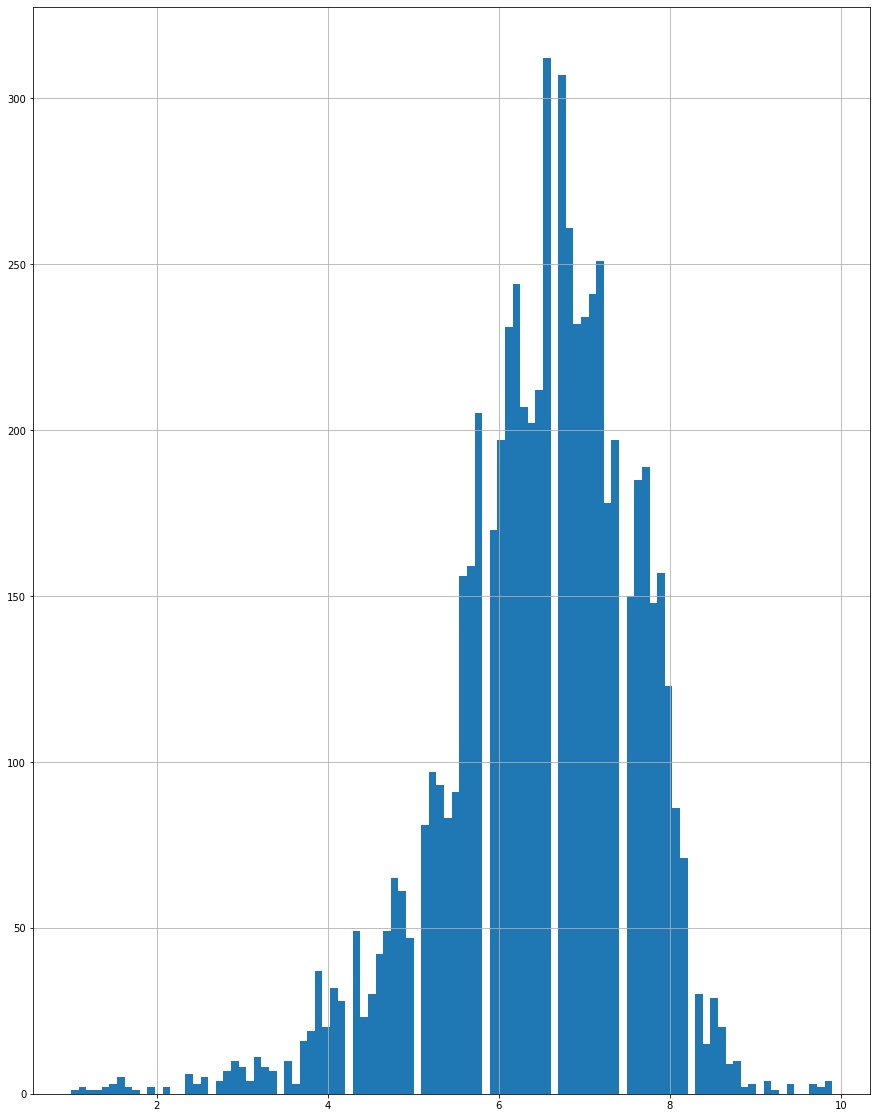

In [ ]:
data['ratings'].hist(figsize=(15,20), bins = 100, grid = True)

Хотя гистограмма стремиться к нормальному значению, ее центр смещен за середину допустимого диапазона (0-10), что может указывать на то, хорошие более высокий балл фильмам ставят чаще, чем более низкий.

Также на гистограмме видны "провалы", как будто некоторые значения рейтинга в принципе отсутсвуют в датафрейме. Это может быть особенностью использования большого количества корзин, так и особенностью самого датафрейма - некоторые оценки так и не получили себе ни одного фильма.

Попробуем уменьшить количество корзин и отсортировать значения рейтинга.

<AxesSubplot:>

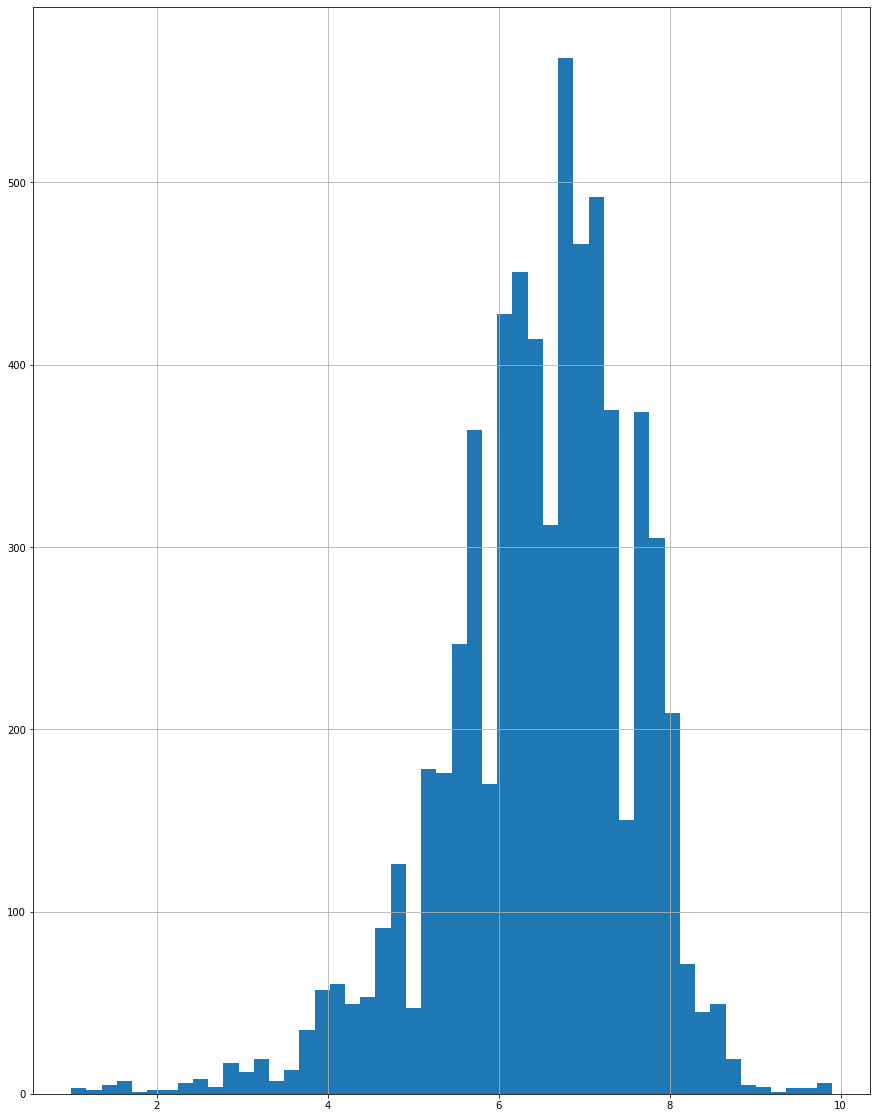

In [ ]:
data['ratings'].hist(figsize=(15,20), bins = 50, grid = True)

In [ ]:
data['ratings'].sort_values().unique()

array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.1, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4,
       6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7,
       7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. ,
       9.1, 9.2, 9.4, 9.7, 9.8, 9.9, nan])

Провалы сохранились, а сортировка лишь указала на отсутствие значений 2.0,2.3 и 9.3, которые не находятся "в зоне провалов".

Возможно, данные значения, а также значения, которые расположены около провалов, как раз и находились на месте пропусков в столбце рейтингов.

Теперь посмотрим на частоту распределения в цифрах.

In [ ]:
data['ratings'].describe() # статистическое описание

count    6511.000000
mean        6.487851
std         1.114516
min         1.000000
25%         5.900000
50%         6.600000
75%         7.200000
max         9.900000
Name: ratings, dtype: float64

Среднее и медиана близки по значению, а стандартное отклонение не слишком велико.

Минимальный балл оказался единицей, а вот десятку так никто и не получил, хотя был близок (максимальная оценка - 9.9). Это и находящиеся около шести с половиной баллов среднее и медиана могут свидетельствовать о том, что пользователи чаще оценивают фильмы положительно, чем негативно.

<AxesSubplot:>

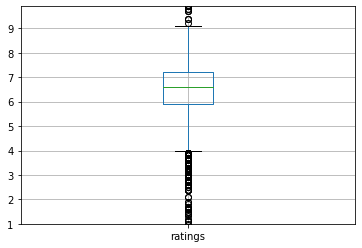

In [ ]:
plt.ylim(1, 9.9)
data.boxplot(column=['ratings'])

Максимальная концентрация оценок находится в районе 6-7 баллов (что подтверждает склонность к положительным оценкам), а большая часть оценок находится в диапазоне между 4 и 9 баллами. Поэтому в дальнейших исследованиях можно использовать срез данных, находящийся в данном диапазоне.

***Выводы***

Пользователи склонны чаще оценивать фильмы положительно, чем отрицательно.

Для части дальнейшего исследования будем использовать строки со значением `'1<='` и `'<= 9.9'` в столбце `'ratings'`.

##### Работа со сборами

Пусть мы пока и не создали столбец с более удобными для восприятия единицами, но посмотреть на распределение сборов можно уже сейчас.

<AxesSubplot:>

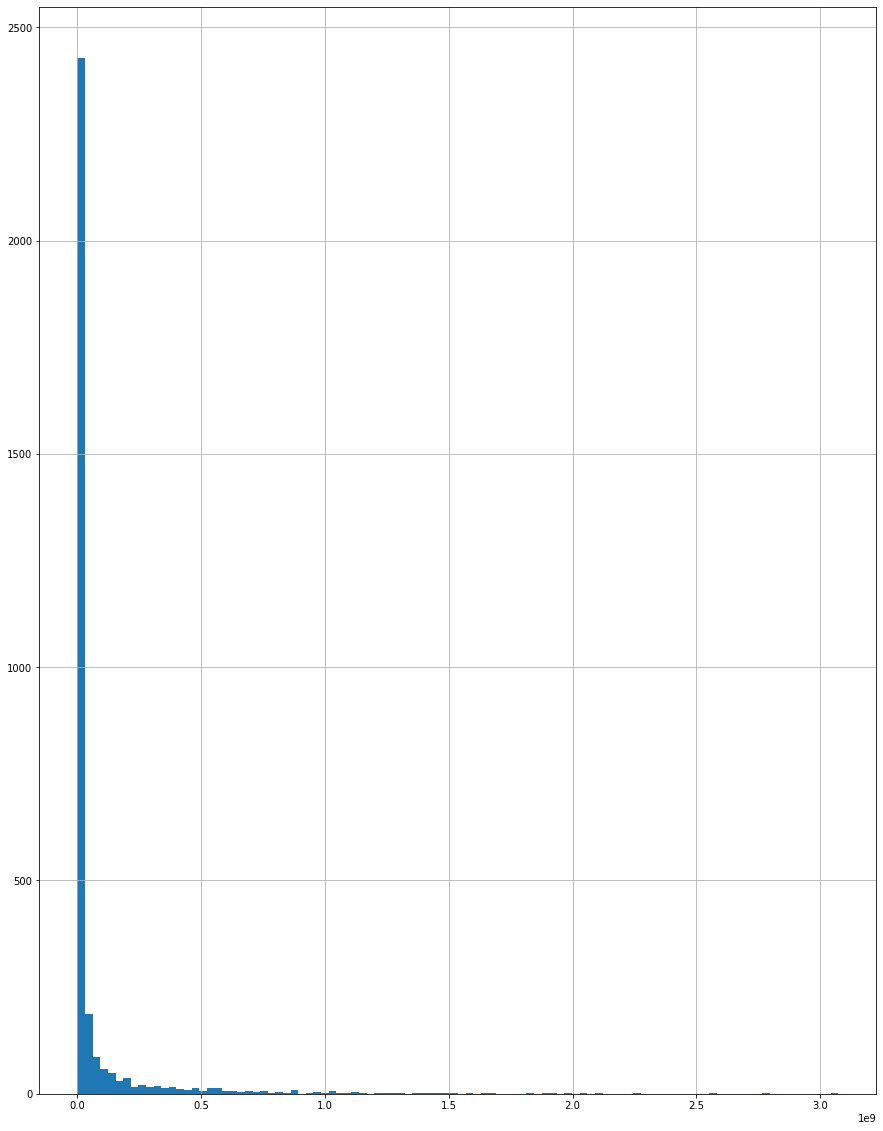

In [ ]:
data['box_office'].hist(figsize=(15,20), bins = 100, grid = True)

Основная часть фильмов собрала менее 0,5 le9 (млдр) рублей. Но есть аномалии, с сборами гораздо большими и даже превышающими 3.0 le9!

Взглянем на фильмы с подозрительно высокими сборами.

In [ ]:
data[data['box_office'] >= 1500000000.0]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
2155,Мстители: Эра Альтрона,121007215,2015-04-03 12:00:00+00:00,Художественный,Марвел Студиос,США,Джосс Уидон,Кевин Фейги,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.2,"фантастика,боевик,приключения",1.500989e+09
2574,Миньоны,124001715,2015-03-30 12:00:00+00:00,Анимационный,Иллюминейшн Интертейнмент,США,"Кайл Балда, Пьер Соффин","Кристофер Меледандри, Джанет Хили",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.2,"мультфильм,фантастика,комедия",1.646581e+09
2836,Дэдпул,121002116,2016-02-03 12:00:00+00:00,Художественный,"ХХ век Фокс, Марвел Энтерпрайзиз, Тэ Эс Гэ Инт...",Канада - США,Тим Миллер,"Саймон Кинберг, Райан Рейнольдс, Лорен Шулер Д...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.5,"фантастика,боевик,комедия",1.587516e+09
2855,Зверополис,124000316,2016-02-15 12:00:00+00:00,Анимационный,"Уолт Дисней Анимейшн Студиос, Уолт Дисней Пикчерз",США,"Рич Мур, Байрон Ховард",Кларк Спенсер,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.3,"мультфильм,комедия,криминал",2.048126e+09
3113,Звездные войны: Пробуждение силы,121024915,2015-12-11 12:00:00+00:00,Художественный,"Лукасфилм, Бэд Робот, Трунорт Продакшнз",США,Джей Джей Абрамс,"Джей Джей Абрамс, Брайан Берк, Кэтлин Кеннеди",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"фантастика,боевик,приключения",1.658861e+09
3391,Отряд самоубийц,121018816,2016-06-21 12:00:00+00:00,Художественный,"Атлас Интертейнмент, Ди Си Интертейнмент, Дюн ...",США,Дэвид Эйр,"Чарльз Ровен, Ричард Скал",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.1,"фантастика,боевик,фэнтези",1.570380e+09
3483,Пираты Карибского моря: Мертвецы не рассказыва...,121009217,2017-05-17 12:00:00+00:00,Художественный,"Джерри Брукхаймер Филмз, Уолт Дисней Пикчерз, ...",США,"Йоаким Реннинг, Эспен Сандберг",Джерри Брукхаймер,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.6,"фэнтези,боевик,комедия",2.118396e+09
3750,Тайная жизнь домашних животных. Миньоны против...,124002816,2016-07-05 12:00:00+00:00,Анимационный,"Иллюминейшн Интертейнмент, Юниверсал Пикчерз",США,Крис Рено,Кристофер Меледандри,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.7,"мультфильм,короткометражка,комедия",1.971005e+09
5493,Последний богатырь,111007017,2017-10-19 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"" по заказу ООО ""Уолт Ди...",Россия,Д.Дьяченко,"Э.Илоян, Д.Жалинский, М.Озкан, А.Троцюк, В.Шляппо",«12+» - для детей старше 12 лет,50000000.0,50000000.0,352477575.0,Фонд кино,6.8,"комедия,фэнтези,приключения",1.655038e+09
5641,Движение вверх,111011817,2017-12-21 12:00:00+00:00,Художественный,"ООО ""Студия ""ТРИТЭ"" Никиты Михалкова""",Россия,А.Мегердичев,"Л.Верещагин, А.Златопольский, Н.Михалков, ООО ...",«6+» - для детей старше 6 лет,0.0,400000000.0,590192191.0,Фонд кино,7.5,"спорт,драма",2.779686e+09


Таких фильмов не слишком много, однако у них сохранны рейтинг и жанры, а потому лучше не исключать их совсем из исследований.

Посмотрим на распределение в цифрах.

In [ ]:
data['box_office'].describe() # статистическое описание

count    3.155000e+03
mean     7.655133e+07
std      2.404559e+08
min      0.000000e+00
25%      8.709050e+04
50%      2.338050e+06
75%      2.399546e+07
max      3.073569e+09
Name: box_office, dtype: float64

Средняя и медиана сильно разнятся, что может быть обусловлено вышенайдеными аномалиями, при этом стандартное отклонение достаточно большое, что также указывает на наличие аномалий. А минимум и вовсе равен нулю, что также похоже на аномалию.

Посмотрим на диаграмму размах, чтобы узнать, какие значения считать аномалиями.

<AxesSubplot:>

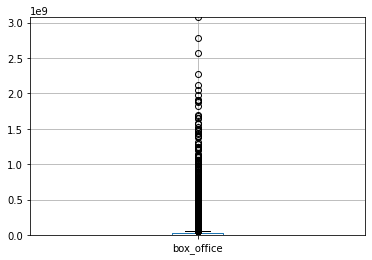

In [ ]:
plt.ylim(0, 3.073569e+09)
data.boxplot(column=['box_office'])

Хвост из аномалий слишком длинный, а потому изменим масштаб, чтобы лучше увидеть диапазон нормальных значений.

<AxesSubplot:>

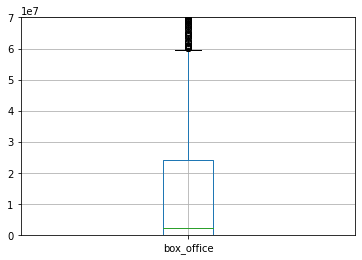

In [ ]:
plt.ylim(0, 7e+07)
data.boxplot(column=['box_office'])

Теперь лучше заметно, что диапазон нормальных значений заканчивается на уровне около 6 le7 (60 млн руб). Все, что выше этого, можно считать выбросами.

Взглянем на гистограмму с усеченными выбросами.

<AxesSubplot:>

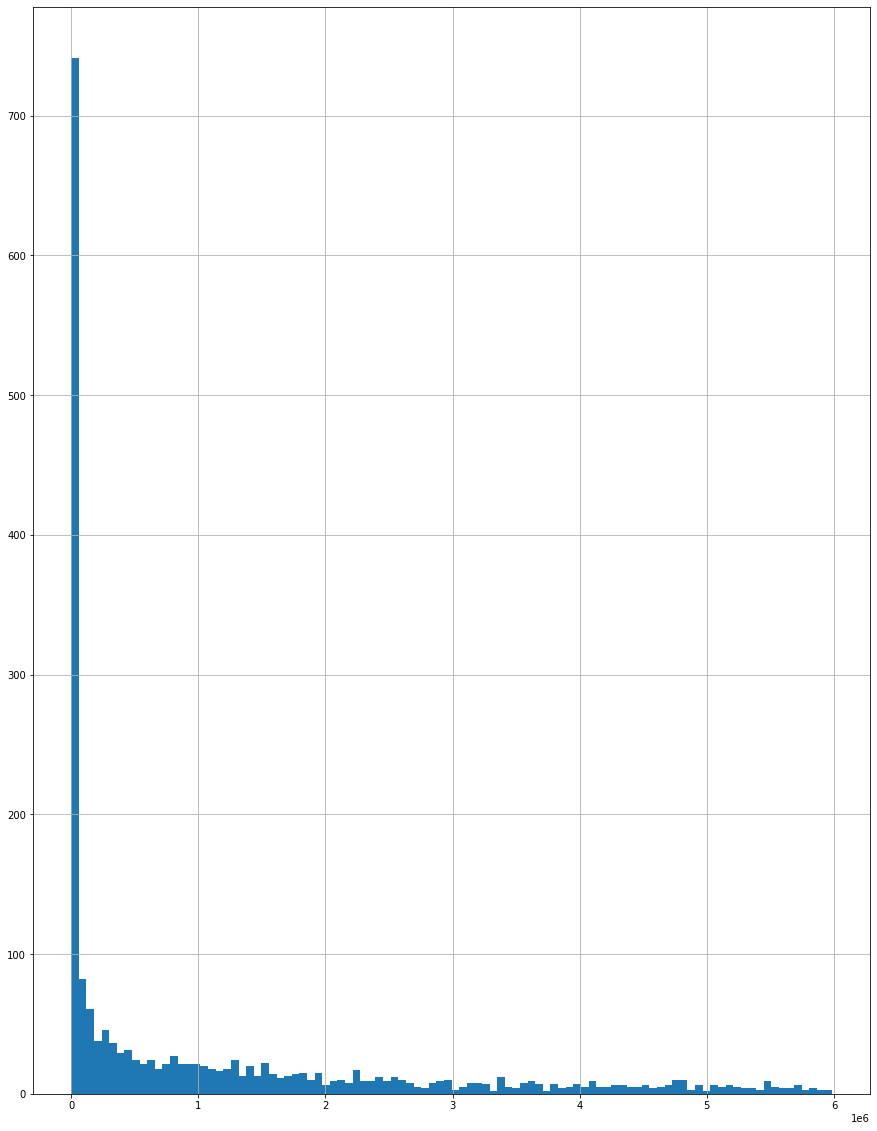

In [ ]:
data.drop(data.loc[data['box_office'] > 6000000]
                   .index, axis = 0)['box_office'].hist(figsize=(15,20), bins = 100, grid = True)

Теперь распределение в целом стало относительно равномерным, однако в самом начале имеется подозрительно огромный пик низкокассовых фильмов, который требует дополнительного изучения.

Посмотрим на обновленное статистическое описание.

In [ ]:
data[data['box_office']<=6e+07]['box_office'].describe() # статистическое описание

count    2.606000e+03
mean     6.553278e+06
std      1.190618e+07
min      0.000000e+00
25%      2.574750e+04
50%      1.146755e+06
75%      6.120022e+06
max      5.952489e+07
Name: box_office, dtype: float64

Среднее и медиана по-прежнему далеки друг от друга. Стандартное отклонение стало меньше, но по-прежнему велико.

Попробуем посмотреть на подозрительные данные в начале гистограммы поближе.

<AxesSubplot:>

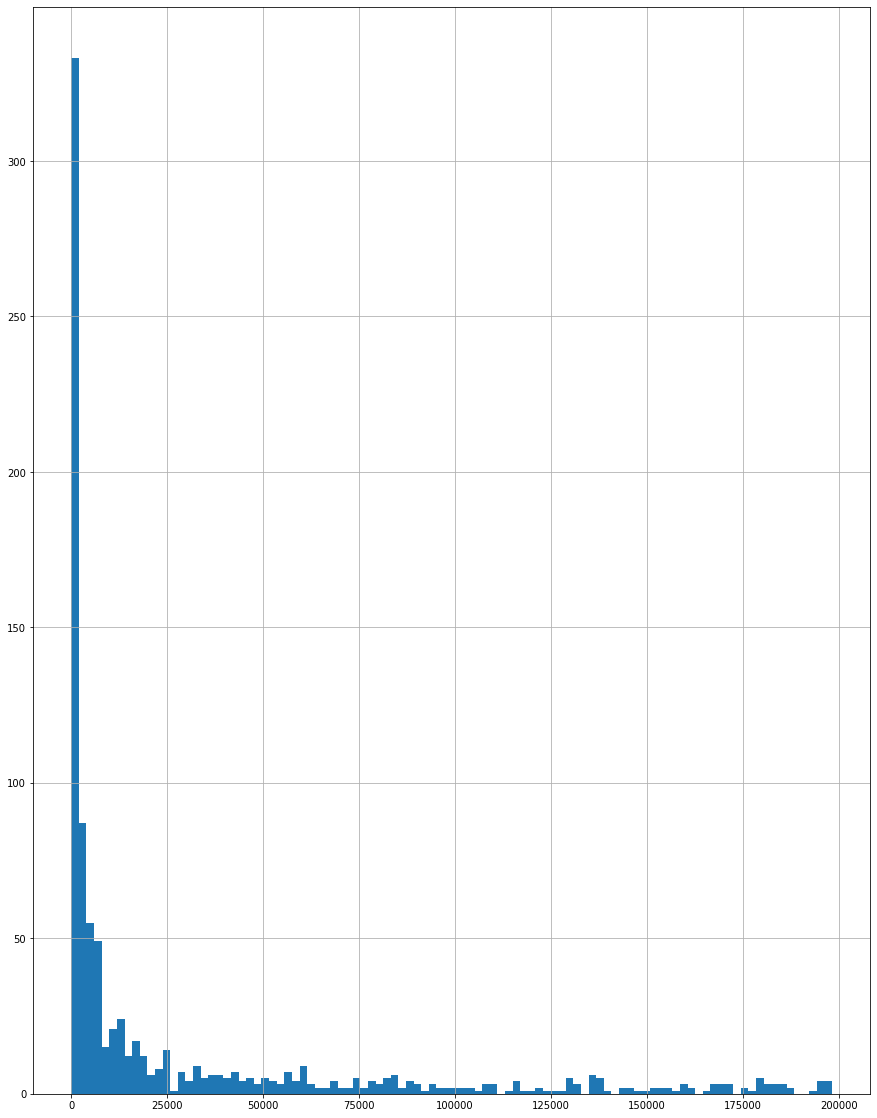

In [ ]:
data.drop(data.loc[data['box_office'] > 0.2e+06]
                   .index, axis = 0)['box_office'].hist(figsize=(15,20), bins = 100, grid = True)

In [ ]:
len(data[data['box_office'] < 0.2e+06])

905

In [ ]:
len(data['box_office'].dropna())

3155

In [ ]:
len(data[data['box_office'] < 0.2e+06])/len(data['box_office'].dropna())*100

28.68462757527734

In [ ]:
len(data[data['box_office'] < 25000])

649

In [ ]:
len(data[data['box_office'] <25000])/len(data['box_office'].dropna())*100

20.570522979397783

905 фильмов (это 29 % из тех 3155, о которых нам доступна финансовая информация) не собрали и 200 тыс.руб. 649 фильмов не собрали даже 25 тысяч рублей!

Это выглядит странно. Возможно, это были закрытые показы, но для подобного их слишком много. Возможно, перепутаны единицы измерения, и вместо рублей у данных фильмов имелись ввиду миллионы рублей?

Для начала посмотрим на самые некассовые фильмы.

In [ ]:
data[data['box_office'] < 10000]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
18,Неподдающиеся,111003616,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ю.Чулюкин,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.0,"мелодрама,комедия",360.0
19,Неподсуден,111003716,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Краснопольский, В.Усков",unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,420.0
22,"Операция ""Ы"" и другие приключения Шурика",111007413,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Л.Гайдай,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.7,"комедия,мелодрама,криминал",380.0
38,Мужики!..,111007213,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,И.Бабич,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.1,драма,1165.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5368,ШПИОН,111009411,2011-12-09 12:00:00+00:00,Художественный,"ООО ""Студия ""ТРИТЭ"" Никиты Михалкова",Россия,А.Андрианов,"С.Шумаков, Л.Верещагин",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.1,"боевик,комедия,криминал",5405.0
5376,ВОИН.com,111004411,2011-07-04 12:00:00+00:00,Художественный,"ООО ""Культурные инициативы""",Россия,Е.Бычкова,"В.Малышев, А.Малышев",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,4.7,комедия,465.0
5377,Кунг-фу Панда 2.,224021411,2011-11-15 12:00:00+00:00,Анимационный,ДримУоркс Анимэйшн,США,Дженнифер Ю,"Мелисса Кобб, Джонатан Айбел, Гленн Бергер",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.4,"мультфильм,фэнтези,боевик",9270.0
6557,Время собирать цветы,112025118,2019-01-01 12:00:00+00:00,Документальный,"ООО ""Краеведофф""",Россия,Г.Щерба,О.Ракшин,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,7175.0


In [ ]:
data[(data['box_office'] < 10000)&(data['production_country'] == 'СССР')]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
18,Неподдающиеся,111003616,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ю.Чулюкин,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.0,"мелодрама,комедия",360.0
19,Неподсуден,111003716,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Краснопольский, В.Усков",unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,420.0
22,"Операция ""Ы"" и другие приключения Шурика",111007413,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Л.Гайдай,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.7,"комедия,мелодрама,криминал",380.0
38,Мужики!..,111007213,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,И.Бабич,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,8.1,драма,1165.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438,Звездный мальчик,111013915,2015-08-25 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"Е.Зильберштейн, А.Дудоров",unknown,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.5,драма,0.0
2548,Везучая.,111006815,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,О.Ремизов,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,1660.0
2550,Витя Глушаков - друг апачей,111007115,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Г.Бежанов,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.2,комедия,830.0
3199,Новый Гулливер.,111003816,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,А.Птушко,unknown,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.0,"мультфильм,фэнтези,комедия",3200.0


539 фильмов со сборами менее 10 тыс руб - это слишком много, чтобы считаться верными данными. А вот если домножить их на тысячу - ситуация, возможно, станет выглядеть более правдоподобно.

Часть из фильмов снято еще в СССР (и похоже, что они вовсе не имели продюссера, что логично), однако в прокат заново попали уже в современности. Но даже это (старый для многих аудиторий, а потому возможно не вызывающий интереса, фильм) не объясняет низкие сборы: даже несколько школьных классов, пришедших на каникулах на условного "Витя Глушаков - друг апачей" наверняка бы потратили на билеты больше, чем 830 руб (даже если их учестьза минусом расходов кинотеатра на показ). Может, это были льготные билеты? Установить проблематично.

Отбросить странные строки - значит потерять большое количество информации, которой и так не много. Попробуем исправить ситуацию.

Также у нас есть строки, у которых сборы равны нулю. Взглянем на них поближе.

In [ ]:
data[data['box_office'] == 0]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office
66,Анна Павлова,111011013,2013-12-19 12:00:00+00:00,Художественный,"совместное производство Киностудия ""Мосфильм"",...",СССР - Франция - Англия - Куба - ГДР,Эмиль Лотяну,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,"драма,биография,музыка",0.0
237,Подранки,111007613,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Н.Губенко,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.2,драма,0.0
596,Запах вереска,111003012,2012-05-23 12:00:00+00:00,Художественный,"ООО ""Студия РИМ""",Россия,А.Магомедов,"М.Балашова, Е.Миронов",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.3,комедия,0.0
913,В тумане /По одноименной повести Василя Быкова/,121027712,2012-11-07 12:00:00+00:00,Художественный,"Ма Йа Де Фикшн, Лемминг Филм, Беларусьфильм, Д...",Германия - Нидерланды - Беларусь - Россия - Ла...,Сергей Лозница,Хайно Декерт,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.5,"драма,военный,история",0.0
931,Письмо для Момо,124002912,2012-10-25 12:00:00+00:00,Анимационный,"Кадокава Пикчерз, Продакшнз И Джи, Токио Броад...",Япония,Окиура Хироюки,"Хироюки Икеда, Митсухиса Ишикава, Кацзуя Хамана",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.4,"аниме,мультфильм,драма",0.0
932,Летние войны,124002812,2012-10-25 12:00:00+00:00,Анимационный,"Медхауз, Ниппон Телевижн Нетуорк Корпорейшн, К...",Япония,Мамору Хосода,"Такафуми Ватанабэ, Такуя Ито, Сэйдзи Окуда, Юи...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.7,"аниме,мультфильм,фантастика",0.0
975,Гарегин Нжде,131000213,2013-04-23 12:00:00+00:00,Художественный,"Эй Джи Кей Продакшнз, Пан Армениан Медиа Групп",Армения,Грач Кешишян,Грач Кешишян,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.9,биография,0.0
1125,Марафон,111006712,2012-12-18 12:00:00+00:00,Художественный,"ООО ""Синема Арт Студио""",Россия,К.Оганесян,К.Оганесян,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.5,"комедия,мелодрама",0.0
1385,Экзамен для двоих /По роману Джин Ханфф Корелитц/,121014613,2013-06-11 12:00:00+00:00,Художественный,Депф оф Филд,США,Пол Вайц,"Пол Вайц, Керри Кохански, Эндрю Миано",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,5.8,"мелодрама,комедия,драма",0.0
1557,Последняя любовь мистера Моргана /По роману Фр...,121002614,2014-02-11 12:00:00+00:00,Художественный,"Камински Штим Фильм, Бавариа Пикчерз, Сенатор ...",Германия - Бельгия - США - Франция,Сандра Неттельбек,"Франк Камински, Астрид Камке, Филипп Кройцер, ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.9,драма,0.0


In [ ]:
len(data[data['box_office'] == 0])

24

24 фильма на самом деле также не имеют информации о сборах. Возможно, это была маркировка пропусков в исходном датасете. Так как установить настоящие значение нам не получится, но столбцы с рейтингом и жанром сохранны, то просто исключим их из некоторых исследований.

Возможно, строки с низкокассовыми фильмами производства СССР более подозрительны и могут иметь иные факторы появления подобной суммы сборов, чем остальные, но удалять вовсе из датафрейма ввиду сохранности рейтинга и жанра не стоит. Можно исключить исследований, но лучше применим к нему умножение, как и к остальным низкокассовым фильмам. Даже если сборы "дважды странных" строк действительно в реальности такие низкие по каким-либо причинам, их не там много, чтобы сильно исказить результат исследования.

Теперь создадим новый столбец, куда перенесем данные из столбца о кассовых сборах.

In [ ]:
data['box_office_new'] = data['box_office'].copy() #создание

In [ ]:
data.head(20) #проверка успешности создания

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office,box_office_new
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN,NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN,NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0,2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00+00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN,NaN
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00+00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN,NaN
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР",СССР - Венгрия,В.Титов,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN,NaN


In [ ]:
data.loc[data['box_office_new'] < 25000, 'box_office_new'] =\
data.loc[data['box_office_new'] < 25000, 'box_office_new']*1000

In [ ]:
data[data['box_office_new'] < 10000] #проверка

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office,box_office_new
66,Анна Павлова,111011013,2013-12-19 12:00:00+00:00,Художественный,"совместное производство Киностудия ""Мосфильм"",...",СССР - Франция - Англия - Куба - ГДР,Эмиль Лотяну,unknown,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,"драма,биография,музыка",0.0,0.0
237,Подранки,111007613,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Н.Губенко,unknown,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.2,драма,0.0,0.0
596,Запах вереска,111003012,2012-05-23 12:00:00+00:00,Художественный,"ООО ""Студия РИМ""",Россия,А.Магомедов,"М.Балашова, Е.Миронов",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.3,комедия,0.0,0.0
913,В тумане /По одноименной повести Василя Быкова/,121027712,2012-11-07 12:00:00+00:00,Художественный,"Ма Йа Де Фикшн, Лемминг Филм, Беларусьфильм, Д...",Германия - Нидерланды - Беларусь - Россия - Ла...,Сергей Лозница,Хайно Декерт,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.5,"драма,военный,история",0.0,0.0
931,Письмо для Момо,124002912,2012-10-25 12:00:00+00:00,Анимационный,"Кадокава Пикчерз, Продакшнз И Джи, Токио Броад...",Япония,Окиура Хироюки,"Хироюки Икеда, Митсухиса Ишикава, Кацзуя Хамана",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.4,"аниме,мультфильм,драма",0.0,0.0
932,Летние войны,124002812,2012-10-25 12:00:00+00:00,Анимационный,"Медхауз, Ниппон Телевижн Нетуорк Корпорейшн, К...",Япония,Мамору Хосода,"Такафуми Ватанабэ, Такуя Ито, Сэйдзи Окуда, Юи...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.7,"аниме,мультфильм,фантастика",0.0,0.0
975,Гарегин Нжде,131000213,2013-04-23 12:00:00+00:00,Художественный,"Эй Джи Кей Продакшнз, Пан Армениан Медиа Групп",Армения,Грач Кешишян,Грач Кешишян,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.9,биография,0.0,0.0
1125,Марафон,111006712,2012-12-18 12:00:00+00:00,Художественный,"ООО ""Синема Арт Студио""",Россия,К.Оганесян,К.Оганесян,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.5,"комедия,мелодрама",0.0,0.0
1385,Экзамен для двоих /По роману Джин Ханфф Корелитц/,121014613,2013-06-11 12:00:00+00:00,Художественный,Депф оф Филд,США,Пол Вайц,"Пол Вайц, Керри Кохански, Эндрю Миано",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,5.8,"мелодрама,комедия,драма",0.0,0.0
1557,Последняя любовь мистера Моргана /По роману Фр...,121002614,2014-02-11 12:00:00+00:00,Художественный,"Камински Штим Фильм, Бавариа Пикчерз, Сенатор ...",Германия - Бельгия - США - Франция,Сандра Неттельбек,"Франк Камински, Астрид Камке, Филипп Кройцер, ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.9,драма,0.0,0.0


Остались только строки с нулем (то есть те, что на самом деле вероятнее всего пропуски), а значит содержание и корректировка  произошли успешно.

Посмотрим на обновленную гистограмму.

<AxesSubplot:>

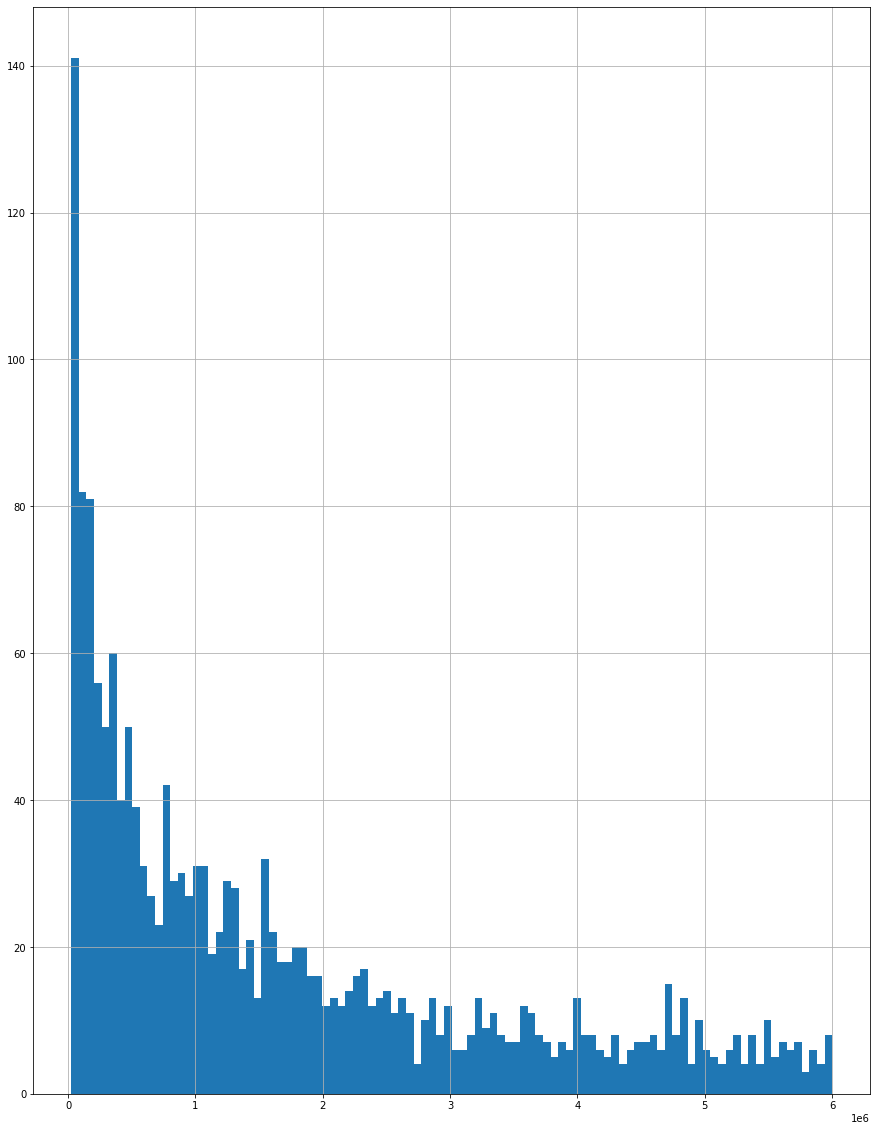

In [ ]:
data.drop(data.loc[data['box_office_new'] > 6000000]
                   .index, axis = 0)\
.drop(data.loc[data['box_office_new'] == 0]
                   .index, axis = 0)\
['box_office_new'].hist(figsize=(15,20), bins = 100, grid = True)

Текущая гистограмма выглядит более правдоподобно. Но и распределение у нас теперь поменялось тоже!

Взглянем на распределение "без фильтров", исключив лишь пропуски-нули, чтобы более корректно "обрезать" этот хвост.

<AxesSubplot:>

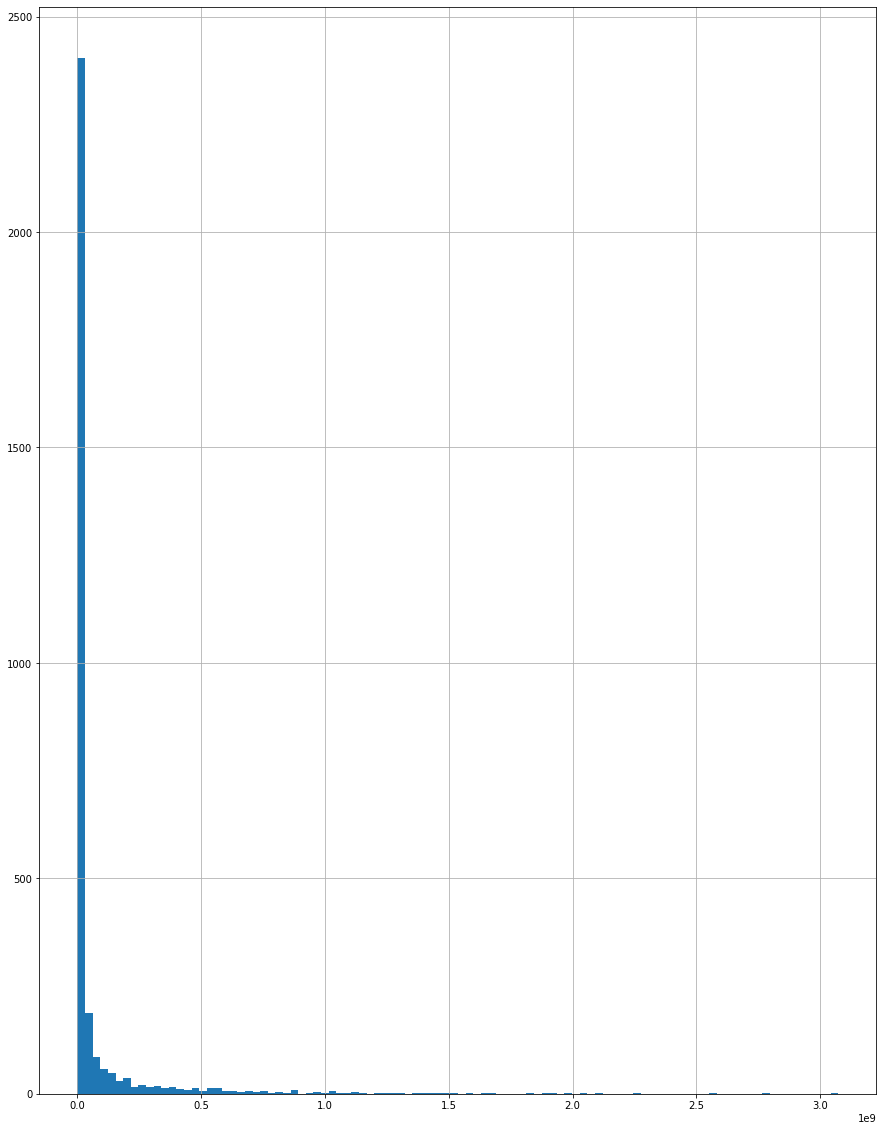

In [ ]:
# гистограмма
data.drop(data.loc[data['box_office_new'] == 0]
                   .index, axis = 0)\
['box_office_new'].hist(figsize=(15,20), bins = 100, grid = True)

Так как корректировали (переводили из млн руб в руб) мы только аномалии в "нижней части", то хвост у гистограммы сохранился.

In [ ]:
data.loc[data['box_office_new'] != 0]['box_office_new'].describe() # статистическое описание

count    3.131000e+03
mean     7.809745e+07
std      2.409976e+08
min      2.517000e+04
25%      9.300915e+05
50%      4.327266e+06
75%      2.477042e+07
max      3.073569e+09
Name: box_office_new, dtype: float64

Медиана и среднее все еще далеки друг от друга, но все же ближе, чем были изначально, а значит аномалий удалось сократить.

<AxesSubplot:>

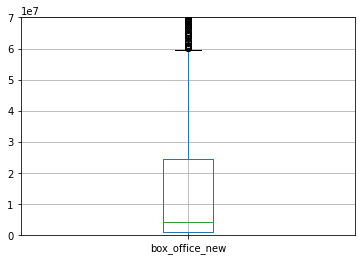

In [ ]:
# размах
plt.ylim(0, 7e+07)
data.boxplot(column=['box_office_new'])

После корректировки аномалиями по-прежнему можно считать данные выше 6e+07 (60 млн) руб. Их, вместе со значениями равными нулю, мы исключим из исследования.

***Выводы***

Обнаружено большое количество фильмов с аномально низкими кассовыми сборами, что позволило предположить использование в данных строках иных единиц измерения (млн руб вместо руб). Создан новый столбец `'box_office_new'`, где произведена корректировка данных.

После изучения распределения "нормальными" данными, пригодными к изучению, признаны данные, имеющие значения `'!=0'` и  `'< 6e+07'` (60 млн) руб в столбце `'box_office_new'`.

#### Шаг 2.6. Добавьте новые столбцы





Для удобства пользования датафреймом (в том числе возможности создания на его основе нового, с меньшим количеством невостребованных столбцов) нам потребуется его доработать, добавив несколько столбцов.

##### Наличие господдержки и ее доля

- Посчитайте, какую долю от общего бюджета фильма составляет государственная поддержка.

Для начала, можно добавить столбец булева типа с маркировкой наличия или отсутствия господдержки фильма.

In [ ]:
len(data.query('budget >= 0')['title'].unique()) # вспомним, сколько всего фильмов получили господдержку

332

In [ ]:
len(data) # всего длина датасета

7458

Так как NaN не равно само себе, используем это его свойство для заполнения нового столбца.

In [ ]:
def helping(sum):
    try:
        return sum == sum
    except:
        pass

In [ ]:
#data['help'] = data['budget'].apply(helping) # вариант попроще

In [ ]:
data.insert(9, 'help', data['budget'].apply(helping)) # вариант более удобный для восприятия в датафрейме

In [ ]:
data.query('help == True') # проверка визуальная

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,help,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office,box_office_new
1280,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,True,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05,3.653536e+05
1446,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,True,0.0,26000000.0,37142857.0,Министерство культуры,NaN,NaN,2.814000e+04,2.814000e+04
1496,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,True,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",1.995703e+07,1.995703e+07
1522,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,True,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,5.591750e+04,5.591750e+04
1789,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,True,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,2.321000e+05,2.321000e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7436,Союз спасения,111022019,2019-12-26 12:00:00+00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",«12+» - для детей старше 12 лет,True,100000000.0,400000000.0,980000000.0,Фонд кино,6.0,"история,биография,драма",7.177032e+08,7.177032e+08
7438,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,True,100000000.0,0.0,190000000.0,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08,5.010692e+08
7446,Вторжение,111022519,2019-12-23 12:00:00+00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,True,100000000.0,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN,NaN
7448,Я свободен,111023019,2019-12-26 12:00:00+00:00,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,True,0.0,30000000.0,46154000.0,Министерство культуры,5.9,драма,NaN,NaN


In [ ]:
len(data.query('help == True')) # проверка количества

332

In [ ]:
len(data) - len(data.query('help == True')) == len(data.query('help == False'))

True

Создание прошло успешно. Теперь можно преобразовать в более подходящий формат.

In [ ]:
data['help'] = data['help'].astype(bool) # преобразование

Теперь добавим столбец, содержащий информацию о том, какую долю (в процентах) от общего бюджета составляет господдержка, и округлим его содержимое одного знака после запятой.

In [ ]:
data.insert(10, 'help_share', 1000*(data['refundable_support'] + data['non_refundable_support'])/data['budget']//1/10)

In [ ]:
data.tail(20) # проверка

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,help,help_share,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office,box_office_new
7438,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00+00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,True,52.6,100000000.0,0.0,190000000.0,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08,5.010692e+08
7439,Желтый клевер,111022219,2019-12-27 12:00:00+00:00,Художественный,Соломатина Людмила Леонидовна,Россия,Л.Соломатина (Томилова),Л.Соломатина (Томилова),«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7440,Унесенные ветром,121038119,2019-12-16 12:00:00+00:00,Художественный,"Селзник Интернэшнл Пикчерз, Метро Голдвин Майер",США,Виктор Флеминг,Дэвид О.Селзник,«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,8.4,"мелодрама,история,драма",NaN,NaN
7441,Нотр-Дам,121037919,2019-12-19 12:00:00+00:00,Художественный,"Ректангль Продюксьон, Франс 2 Синема, Скоуп Пи...",Франция - Бельгия,Валери Донзелли,"Алис Жерар, Эдуард Вейл",«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,7.8,"мультфильм,мюзикл,драма",NaN,NaN
7442,Дикие и свободные,112004819,2019-12-23 12:00:00+00:00,Документальный,"АНО ""ТВ-Новости""",Россия,Н.Карачкова,В.Сенина,«6+» - для детей старше 6 лет,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7443,Реальная любовь в Нью-Йорке,121038219,2019-12-19 12:00:00+00:00,Художественный,"Креатив Энлэйнс, Арт, Копенгаген Филм, Дет Дан...",Дания - Канада - Швеция - Франция - Германия -...,Лоне Шерфиг,"Малене Бленков, Сандра Каннингэм",«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,6.1,драма,3.143790e+06,3.143790e+06
7444,Черное Рождество,121038319,2019-12-19 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Блюмхауз Продакшнз, Дивид/К...",США - Н.Зеландия,Софи Такал,Джесси Хендерсон,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,3.9,"ужасы,триллер,детектив",1.800177e+07,1.800177e+07
7445,Ходячий замок,124010519,2019-12-19 12:00:00+00:00,Анимационный,"Студио Гибли, Буена Виста Хоум Интертейнмент, ...",Япония,Хаяо Миядзаки,"Томохико Исии, Хаяо Миядзаки, Тосио Судзуки",«6+» - для детей старше 6 лет,False,NaN,NaN,NaN,NaN,NaN,8.3,"аниме,мультфильм,фэнтези",NaN,NaN
7446,Вторжение,111022519,2019-12-23 12:00:00+00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,True,52.9,100000000.0,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN,NaN
7447,Папа,111022919,2019-12-24 12:00:00+00:00,Художественный,"ООО ""Киношкола имени Сергея Федоровича Бондарч...",Россия,К.Чувикова,"ООО ""Киношкола имени Сергея Федоровича Бондарч...",«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,8.2,драма,NaN,NaN


In [ ]:
data.query('budget == 0') # проверка проблемных столбцов с нулевым бюджетом

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,help,help_share,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office,box_office_new
2049,14+,111023614,2014-12-19 12:00:00+00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",«16+» - для детей старше 16 лет,True,NaN,0.0,23000000.0,0.0,"Министерство культуры, Фонд кино",6.6,мелодрама,1.023402e+07,1.023402e+07
2054,Дуxless 2,111000415,2015-01-26 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",«16+» - для детей старше 16 лет,True,NaN,0.0,75000000.0,0.0,Фонд кино,6.6,драма,4.461635e+08,4.461635e+08
2468,Воин (2015),111017315,2015-09-28 12:00:00+00:00,Художественный,"ООО ""Форпост Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,А.Андрианов,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,True,NaN,10000000.0,70000000.0,0.0,Фонд кино,7.8,"боевик,драма,криминал",1.965724e+08,1.965724e+08
2528,Бармен.,111009615,2015-05-26 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Штурманова,Т.Вайнштейн,«16+» - для детей старше 16 лет,True,NaN,20000000.0,0.0,0.0,Фонд кино,6.2,"комедия,фэнтези",6.741897e+07,6.741897e+07
2611,Савва. Сердце воина,114001715,2015-07-21 12:00:00+00:00,Анимационный,"ООО ""Глюкоза Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,М.Фадеев,А.Чистяков,«6+» - для детей старше 6 лет,True,NaN,60000000.0,100000000.0,0.0,Фонд кино,4.6,"мультфильм,приключения,фэнтези",1.844876e+08,1.844876e+08
2680,Тряпичный союз,111010215,2015-06-08 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",«18+» - запрещено для детей,True,NaN,0.0,59000000.0,0.0,Фонд кино,6.3,"комедия,драма",1.957739e+06,1.957739e+06
2784,Срочно выйду замуж,111017115,2015-09-30 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,С Чекалов,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,True,NaN,0.0,35000000.0,0.0,Фонд кино,5.1,"комедия,мелодрама",7.293778e+07,7.293778e+07
2870,Помню - не помню!,111004916,2016-03-01 12:00:00+00:00,Художественный,"ООО ""КиноФирма""",Россия,В.Ровенский,"ООО ""КиноФирма""",«12+» - для детей старше 12 лет,True,NaN,0.0,6000000.0,0.0,Министерство культуры,4.3,комедия,1.536293e+07,1.536293e+07
3043,Любовь с ограничениями,111008216,2016-04-29 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Тюрин,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,True,NaN,19000000.0,51000000.0,0.0,Фонд кино,6.3,"комедия,мелодрама",7.029905e+07,7.029905e+07
3560,Притяжение (2016),111018116,2016-12-16 12:00:00+00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия""",Россия,Ф.Бондарчук,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,True,NaN,0.0,250000000.0,0.0,Фонд кино,5.6,фантастика,1.038321e+09,1.038321e+09


In [ ]:
data.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7458 non-null   object             
 1   pu_number               7458 non-null   int64              
 2   show_start_date         7458 non-null   datetime64[ns, UTC]
 3   type                    7458 non-null   category           
 4   film_studio             7458 non-null   object             
 5   production_country      7458 non-null   object             
 6   director                7458 non-null   object             
 7   producer                7458 non-null   object             
 8   age_restriction         7458 non-null   category           
 9   help                    7458 non-null   bool               
 10  help_share              315 non-null    float64            
 11  refundable_support      332 non-null    flo

##### Кассовые сборы

Пусть мы уже и обработали столбец  с кассовыми сборами на предмет аномалий "в исходных единицах измерения", но нам эти данные еще потребуются для исследований. Поэтому добавим новый столбец с более удобными для восприятия единицами измерения.

In [ ]:
data.loc[data['box_office_new'] != 0,'box_office_new'].min()

25170.0

Минимальное значение составило 25170 рублей. Вероятно, это тоже аномалия. Однако она все равно указывет на то, что мы можем заменить рубли на млн руб при измерении сборов.

In [ ]:
data['box_office_mill'] = 100*data['box_office_new']//1000/100 # создаем и преобразовываем

In [ ]:
data.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7458 non-null   object             
 1   pu_number               7458 non-null   int64              
 2   show_start_date         7458 non-null   datetime64[ns, UTC]
 3   type                    7458 non-null   category           
 4   film_studio             7458 non-null   object             
 5   production_country      7458 non-null   object             
 6   director                7458 non-null   object             
 7   producer                7458 non-null   object             
 8   age_restriction         7458 non-null   category           
 9   help                    7458 non-null   bool               
 10  help_share              315 non-null    float64            
 11  refundable_support      332 non-null    flo

###### Год проката

- Создайте столбец с информацией о годе проката. Выделите год из даты премьеры фильма.

Год выхода проката более крупная, а потому более удобная для обнаружения зависимостей, единица. К тому же она также позволяет отделять фильмы-тезки друг от друга.

Создадим для года отдельный столбец.

In [ ]:
# data['year'] = data['show_start_date'].dt.year # вариант попроще

In [ ]:
data.insert(3, 'year', data['show_start_date'].dt.year) # вариант более удобный для восприятия в датафрейме

In [ ]:
data.head() # проверка

,title,pu_number,show_start_date,year,type,film_studio,production_country,director,producer,age_restriction,help,help_share,refundable_support,non_refundable_support,budget,financing_source,ratings,genres,box_office,box_office_new,box_office_mill
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,2015,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN,NaN,NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,2016,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,unknown,«6+» - для детей старше 6 лет,False,NaN,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN,NaN,NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,2016,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,NaN,NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,2016,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,NaN,NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,2015,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN,NaN,NaN


##### Главный режиссер и основной жанр

- Создайте два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

Главный режиссер - важная информация о фильме. И пусть их фамилии не принимают непосредсвенное в исследовании, но позволяют различать фильмов-тезок и определять фильмы-дубли, что полезно для нашего не слишком акккуратного (даже после правок) датасета. Ведь иначе их можно различить иногда по странам производства (а много где их не одна, выделять одну - некорректно, да и может совпасть), году выхода в прокат (но выходить в российский кинопрокат он может с задержкой или несколько раз), так что использование режиссера как маркер - более надежный способ.

Создадим столбец с фамилией главного режиссера.

In [ ]:
def first(col):
    try:
        col = col.split(",", maxsplit=1)
        return col[0]
    except:
#        pass
         return col #так как у нас есть Nan, чтоб они не стали None, а просто перенеслись

In [ ]:
#data['main_director'] = data['director'].apply(first) # главный режиссер

In [ ]:
data.insert(7, 'main_director', data['director'].apply(first)) # вариант более удобный для восприятия в датафрейме

Чтобы определить самые популярные жанры у зрителей, нам лучше работать со всем содержимым столбца `'genres'`, так как один и тот же фильм может относится к нескольким, и нельзя сказать, который дает больший вклад.

Но так как в текущем исследовании перед нами такая задача не стоbт, то для "условной маркировки" ткже можно вынести "главный" жанр в отдельный столбец.

In [ ]:
#data['main_genre'] = data['genres'].apply(first) # главный жанр

In [ ]:
data.insert(18, 'main_genre', data['genres'].apply(first)) # вариант более удобный для восприятия в датафрейме

In [ ]:
data.tail(10) # проверка

,title,pu_number,show_start_date,year,type,film_studio,production_country,main_director,director,producer,age_restriction,help,help_share,refundable_support,non_refundable_support,budget,financing_source,ratings,main_genre,genres,box_office,box_office_new,box_office_mill
7448,Я свободен,111023019,2019-12-26 12:00:00+00:00,2019,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,True,64.9,0.0,30000000.0,46154000.0,Министерство культуры,5.9,драма,драма,NaN,NaN,NaN
7449,Тридцать,121038419,2019-12-26 12:00:00+00:00,2019,Художественный,Демнехст ауф видео,Германия,Симона Костова,Симона Костова,Джейлан Атаман-Джека,«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,6.3,драма,драма,NaN,NaN,NaN
7450,(Не)идеальный мужчина,111023119,2019-12-24 12:00:00+00:00,2019,Художественный,"ООО ""Нон-Стоп Продакшн""",Россия,М.Бальчюнас (псевдоним М.Вайсберг),М.Бальчюнас (псевдоним М.Вайсберг),"С.Мелькумов, А.Роднянский, М.Вайсберг, Р.Минас...",«12+» - для детей старше 12 лет,True,66.6,40000000.0,60000000.0,150147502.0,Фонд кино,4.5,комедия,"комедия,фантастика,мелодрама",NaN,NaN,NaN
7451,Эколав,111023219,2019-12-26 12:00:00+00:00,2019,Художественный,ВГИК,Россия,Д.Григорьев,Д.Григорьев,ВГИК,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7452,Акрам Хан: Родом из Карри Хауса,126007919,2019-12-23 12:00:00+00:00,2019,Прочие,Свон Филмз,Великобритания,Ник Пойнц,Ник Пойнц,"Поппи Бегум, Ник Пойнц",«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,219569.0,219569.0,219.56
7453,Сад художника: Американский импрессионизм,126008019,2019-12-23 12:00:00+00:00,2019,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7454,Звериная ярость,121037819,2019-12-24 12:00:00+00:00,2019,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,5.4,боевик,"боевик,триллер",NaN,NaN,NaN
7455,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28 12:00:00+00:00,2019,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",Канада - США,Чарльз Е.Бастьен,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7456,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30 12:00:00+00:00,2019,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""",Кипр - Россия,А.Беляев,А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7457,"Машины песенки. Серия ""Когда цветут кактусы""",124010719,2019-12-30 12:00:00+00:00,2019,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""",Кипр - Россия,И.Трусов,И.Трусов,Д.Ловейко,«0+» - для любой зрительской аудитории,False,NaN,NaN,NaN,NaN,NaN,6.3,комедия,"комедия,вестерн",NaN,NaN,NaN


Теоретически, теперь у нас вместо смесей жанров в ячейках стало по одному. А значит, можно придать им вид категорий.

Посмотрим, сколько же у нас теперь вариантов жанров.

In [ ]:
data['main_genre'].unique()

array(['боевик', 'драма', 'фантастика', 'мелодрама', 'мюзикл', 'комедия',
       'триллер', 'ужасы', 'мультфильм', nan, 'военный', 'документальный',
       'фэнтези', 'криминал', 'приключения', 'аниме', 'детектив',
       'для взрослых', 'семейный', 'концерт', 'история',
       'короткометражка', 'детский', 'спорт', 'биография', 'вестерн',
       'музыка', 'фильм-нуар', 'реальное ТВ'], dtype=object)

Гораздо меньше, чем было раньше.

Придадим столбцу тип данных category.

In [ ]:
data['main_genre'] = data['main_genre'].astype('category') # преобразование

##### Возрастной рейтинг

У нас уже есть проверенный и переведенный в тип данных категория рейтинг. Но данные там внесены прямо с расшифровкой, что может быть неплохо для большого датафрейма, но для того, который мы будем создавать на его основе для исследования, лучше бы подошел с сокращенным названием категорий для удобства восприятия. Пусть это и некоторая дополнительная работа, зато строка будет короче и график получится более читабельным.

Создадим такой столбец.

In [ ]:
sorted(data['age_restriction'].unique()) # вспоминаем варианты значений

['«0+» - для любой зрительской аудитории',
 '«12+» - для детей старше 12 лет',
 '«16+» - для детей старше 16 лет',
 '«18+» - запрещено для детей',
 '«6+» - для детей старше 6 лет']

In [ ]:
def age_new (age):
    try:
        if age == '«0+» - для любой зрительской аудитории':
            return '0+'
        elif age == '«6+» - для детей старше 6 лет':
            return '6+'
        elif age == '«12+» - для детей старше 12 лет':
            return '12+'
        elif age == '«16+» - для детей старше 16 лет':
            return '16+'
        elif age == '«18+» - запрещено для детей':
            return '18+'
    except:
        pass

In [ ]:
data.insert(10, 'age', data['age_restriction'].apply(age_new)) # создаем столбец

In [ ]:
# упорядочиваем категории, длинный способ
#cat_type = CategoricalDtype(categories=['0+', '6+', '12+', '16+', '18+'], ordered=True)

In [ ]:
#data['age'] = data['age'].astype(cat_type)

In [ ]:
# упорядочиваем категории, короткий способ
data['age'] = data['age'].astype(CategoricalDtype(categories=['0+', '6+', '12+', '16+', '18+'], ordered=True))

In [ ]:
data.head() # проверка

,title,pu_number,show_start_date,year,type,film_studio,production_country,main_director,director,producer,age,age_restriction,help,help_share,refundable_support,non_refundable_support,budget,financing_source,ratings,main_genre,genres,box_office,box_office_new,box_office_mill
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,2015,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",18+,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,7.2,боевик,"боевик,драма,мелодрама",NaN,NaN,NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,2016,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,Е.Матвеев,unknown,6+,«6+» - для детей старше 6 лет,False,NaN,NaN,NaN,NaN,NaN,6.6,драма,"драма,военный",NaN,NaN,NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,2016,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,6.8,фантастика,"фантастика,боевик,триллер",NaN,NaN,NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,2016,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,6.8,фантастика,"фантастика,боевик,триллер",NaN,NaN,NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,2015,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",18+,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,6.8,фантастика,"фантастика,боевик,триллер",NaN,NaN,NaN


In [ ]:
data.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7458 non-null   object             
 1   pu_number               7458 non-null   int64              
 2   show_start_date         7458 non-null   datetime64[ns, UTC]
 3   year                    7458 non-null   int64              
 4   type                    7458 non-null   category           
 5   film_studio             7458 non-null   object             
 6   production_country      7458 non-null   object             
 7   main_director           7458 non-null   object             
 8   director                7458 non-null   object             
 9   producer                7458 non-null   object             
 10  age                     7458 non-null   category           
 11  age_restriction         7458 non-null   cat

***Выводы***

Для удобства дальнейшей работы и исследования мы создали следующие столбцы:

- `'box_office_mill'` - кассовые сборы в млн руб;
- `'help'` -  наличие или отсутствие господдержки у фильма;
- `'help_share'` - доля (в %) господдержки в общем бюджете фильма;
- `'main_director'` - главный режиссер (первый из перечисляемых в `'director'`);
- `'main_genre'` - главный жанр (первый из перечисляемых `'genres'`).

### Шаг 3. Проведите исследовательский анализ данных


#### Создание нового датафрейма

Текущий датафрейм содержит уже 24 колонки. Для удобства в работе (и сохранности исходного) создадим новый датафрейм, куда войдут только необходимые в исследовании столбцы.

In [ ]:
data.columns # уточняем, какие столбцы у нас имеются в исходном датафрейме

Index(['title', 'pu_number', 'show_start_date', 'year', 'type', 'film_studio',
       'production_country', 'main_director', 'director', 'producer', 'age',
       'age_restriction', 'help', 'help_share', 'refundable_support',
       'non_refundable_support', 'budget', 'financing_source', 'ratings',
       'main_genre', 'genres', 'box_office', 'box_office_new',
       'box_office_mill'],
      dtype='object')

Полная дата проката нам уже не требуется, у нас есть год. Изучение популярности в зависимости от студий, стран выпусков или продюссеров от нас тоже не требуется (и врядли выйдет с имеющися датафреймом), поэтому данные столбцы можно не переносить. Все режиссеры нам не требуются по тем же причинам, хватит главного, чтобы ориентироваться в фильмах-тезках при необходимости.

Номер прокатного удостоверения нам также не несет полезной информации - есть у всех фильмов (тот, что не имел, был удален из датафрейма), уникален (за парой исключений, уже рассмотренных ранее) для каждой строки (но может быть не уникален для конкретного фильма). Как мы обратили внимание ранее, на конце номера удостоверения зашифрован год, в котором его выдали (а год у нас уже имеется в отдельном столбце), то есть кроме роли "дополнительного индекса" ничего не привнесет.

Нет задачи изучить влияния типа фильма на его интерес для зрителя, но может быть полезны для изучения фильмов с господдерожкой в дальнейшем. Но так как для этого исследования также будет использоваться новый датфрейм, в текущий типы фильмов можно не переносить.

Также в текущем датафрейме не требуются размер общего бюджета и финансовые подробности господдержки - достаточно лишь факта ее наличия или отсутствия.

И по сборам хватит столбца с исчислениями в млн руб, а возрастного рейтинга - в сокращенной записи.

In [ ]:
# отбираем нужные нам для исследования и расставляем в удобном порядке
data_research = data[['title', 'main_director', 'year', 'main_genre',
       'type',  'age', 'ratings',  'box_office_mill', 'help']].copy()

In [ ]:
data_research.head() # проверка успешности создания

,title,main_director,year,main_genre,type,age,ratings,box_office_mill,help
0,Открытый простор,Кевин Костнер,2015,боевик,Художественный,18+,7.2,NaN,False
1,Особо важное задание,Е.Матвеев,2016,драма,Художественный,6+,6.6,NaN,False
2,Особо опасен,Тимур Бекмамбетов,2016,фантастика,Художественный,18+,6.8,NaN,False
3,Особо опасен,Тимур Бекмамбетов,2016,фантастика,Художественный,18+,6.8,NaN,False
4,Особо опасен,Тимур Бекмамбетов,2015,фантастика,Художественный,18+,6.8,NaN,False


In [ ]:
data_research.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7458 entries, 0 to 7457
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   title            7458 non-null   object  
 1   main_director    7458 non-null   object  
 2   year             7458 non-null   int64   
 3   main_genre       6502 non-null   category
 4   type             7458 non-null   category
 5   age              7458 non-null   category
 6   ratings          6511 non-null   float64 
 7   box_office_mill  3155 non-null   float64 
 8   help             7458 non-null   bool    
dtypes: bool(1), category(3), float64(2), int64(1), object(2)
memory usage: 322.3+ KB


#### Изучение полноты данных о кассовых сборах

- Посмотрите, сколько фильмов выходило в прокат каждый год. Обратите внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитайте, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируйте, как эта доля менялась по годам. Сделайте вывод о том, какой период полнее всего представлен в данных.

Посмотрим, сколько фильмов у нас выходило каждый год (точнее, сколько прокатных удостоверений получалось), и о скольких из них нам известна информация о сборах.

In [ ]:
data_research.groupby('year').agg({'year':'count','box_office_mill':['count','sum']})

year box_office_mill             
     count           count          sum
year                                   
2010   980             105    339544.19
2011   620             109    379259.22
2012   592             127    511095.30
2013   629             184    721865.85
2014   805             279   8184018.64
2015   705             465  39627508.54
2016   817             525  48058295.64
2017   505             357  48595883.37
2018   879             474  49668359.55
2019   926             530  48437268.13

Можно заметить, что нет ни одного года, когда бы информация по сборам была полной, и что до 2015 года ситуация со сбором данных была совсем плачевной.

Но для более точного понимания необходимо усовершенствовать таблицу и дополнительно взглянуть на графики на ее основе.

In [ ]:
#data_research.groupby('year').agg({'year':'count','box_office_mill':'count', ['box_office_mill':'count']/['year':'count']})

In [ ]:
box_year = data_research.groupby('year').agg({'year':'count','box_office_mill':['count','sum']}).reset_index()

In [ ]:
box_year.columns = ['year', 'films_count', 'box_count', 'box_sum']

In [ ]:
box_year['box_share_known'] = 10000*box_year['box_count']/box_year['films_count']//1/100

In [ ]:
box_year

,year,films_count,box_count,box_sum,box_share_known
0,2010,980,105,339544.19,10.71
1,2011,620,109,379259.22,17.58
2,2012,592,127,511095.30,21.45
3,2013,629,184,721865.85,29.25
4,2014,805,279,8184018.64,34.65
5,2015,705,465,39627508.54,65.95
6,2016,817,525,48058295.64,64.25
7,2017,505,357,48595883.37,70.69
8,2018,879,474,49668359.55,53.92
9,2019,926,530,48437268.13,57.23


Уже можно заметить, что худшая из ситуаций была в 2010 году (и в этом же году было выдано максимальное количество прокатных удостоверений), после доля известной информации росла (причем в 2015 году подскочила чуть менее, чем в два раза! - возможно, появился новый инструмент сбора) до максимума в 2017 году, после чего вновь упала (хоть и не так критично, как было в самом начале, но хуже, чем была ситуация в 2015 году), и теперь пытается расти.

Для лучшего отображения наблюдений можно это дополнительно визуализировать.

Text(0, 0.5, 'процент известной информации')

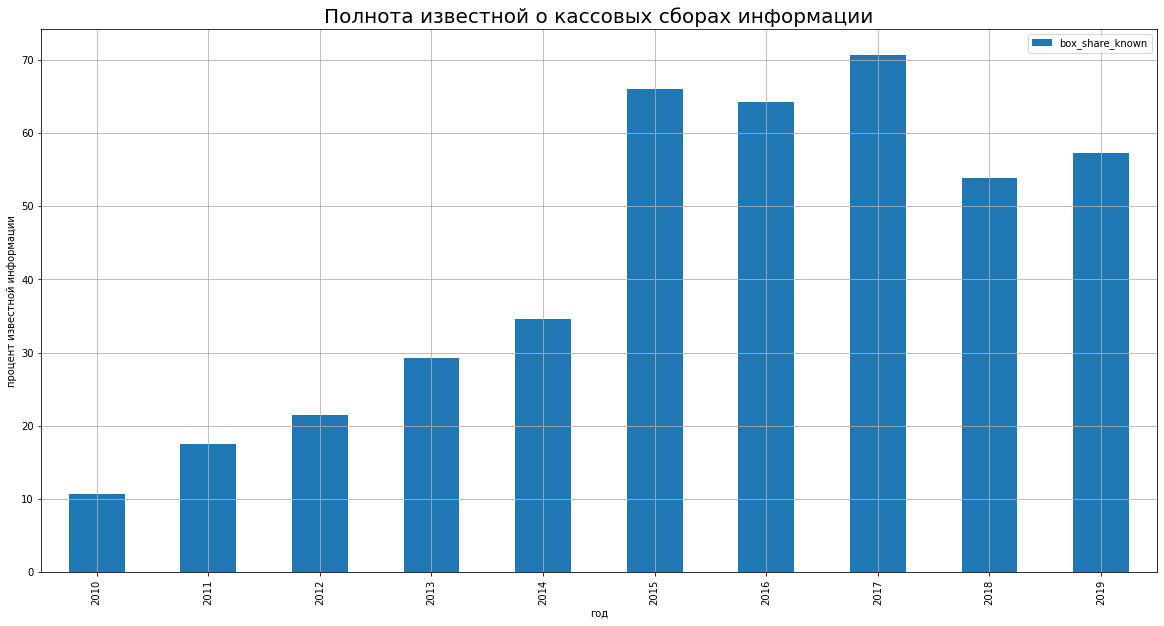

In [ ]:
box_year.plot(y='box_share_known', x='year',  kind='bar',figsize = (20,10), grid=True)

plt.title('Полнота известной о кассовых сборах информации', fontsize=20)
plt.xlabel('год')
plt.ylabel('процент известной информации')

Text(0, 0.5, 'количество')

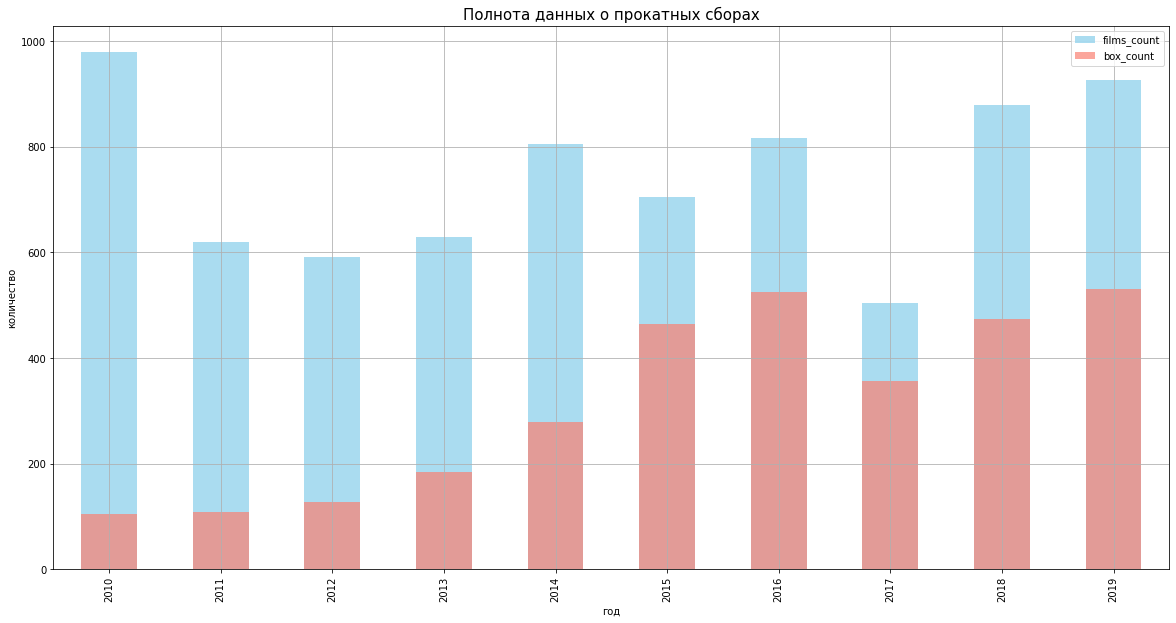

In [ ]:
ax=box_year.plot(y='films_count', x='year',  kind='bar', color='skyblue', alpha=0.7, figsize=(20,10), grid=True)
box_year.plot(y='box_count', x='year',  kind='bar',color='salmon', alpha=0.7, ax=ax, figsize=(20,10),\
              grid=True, legend = True)

plt.title('Полнота данных о прокатных сборах', fontsize=15)
plt.xlabel('год')
plt.ylabel('количество')

Максимальное количество получивших прокатное удостоверение фильмов было в 2010 году, и к этому числу смогли немного приблизится лишь в 2019. При этом в тех же годах были и иные рекорды: в 2014 году было собрана информация о сборах в минимальном за период количестве, а в 2019 - напротив, в максимальном.

Возможно, хорошие процентные показатели в 2017 обусловлены тем, что в этот год фильмов вышло меньше всего за наблюдаемый период, а потому производить сбор информации оказалось легче, а в 2018 и 2019 году фильмов стало выходить в прокат больше, и, если по количеству собранных данных по кассовым сборам, эти года в среднем выше, чем в периоде с 2015 по 2017, но в процентных все равно ниже: похоже, что система сбора данных (даже обновленная) не справляется с нагрузкой, хоть и дает лучшие показатели, чем период с 2010 по 2014.

Наиболее полно данные представлены за период 2015-2017 год, наименее полные - с 2010 по 2014.

***Выводы***

Наиболее полно в данных о прокате представлен период с 2015 по 2017 год, наименее с 2010 по 2014.

#### Изучение динамики сборов по годам.

- Изучите, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?

Знать количество вышедших в прокат фильмов и фильмов, о которых нам известна информация о сборах (и долю второго относительно первого) - это хорошо. Но знать общие суммы сборов лучше, ведь суммы сборов - один из показателей успеха или неудачи для фильма.

Снова взглянем на нашу сводную таблицу из предыдущего раздела.

In [ ]:
box_year.sort_values(by='box_sum')

,year,films_count,box_count,box_sum,box_share_known
0,2010,980,105,339544.19,10.71
1,2011,620,109,379259.22,17.58
2,2012,592,127,511095.30,21.45
3,2013,629,184,721865.85,29.25
4,2014,805,279,8184018.64,34.65
5,2015,705,465,39627508.54,65.95
6,2016,817,525,48058295.64,64.25
9,2019,926,530,48437268.13,57.23
7,2017,505,357,48595883.37,70.69
8,2018,879,474,49668359.55,53.92


Минимальная известная сумма сборов была в 2010 году, что логично, так как это наименее представленный по касающеся сборов информации год (она известна всего о около 11 % получивших прокатное удостоверениях фильмов).

Максимальная - в 2018, со средней представленностью информации.

Для лучшего понимания динамики по годам можно визуализировать таблицу.

Text(0, 0.5, 'сумма сборов в тыс.руб.')

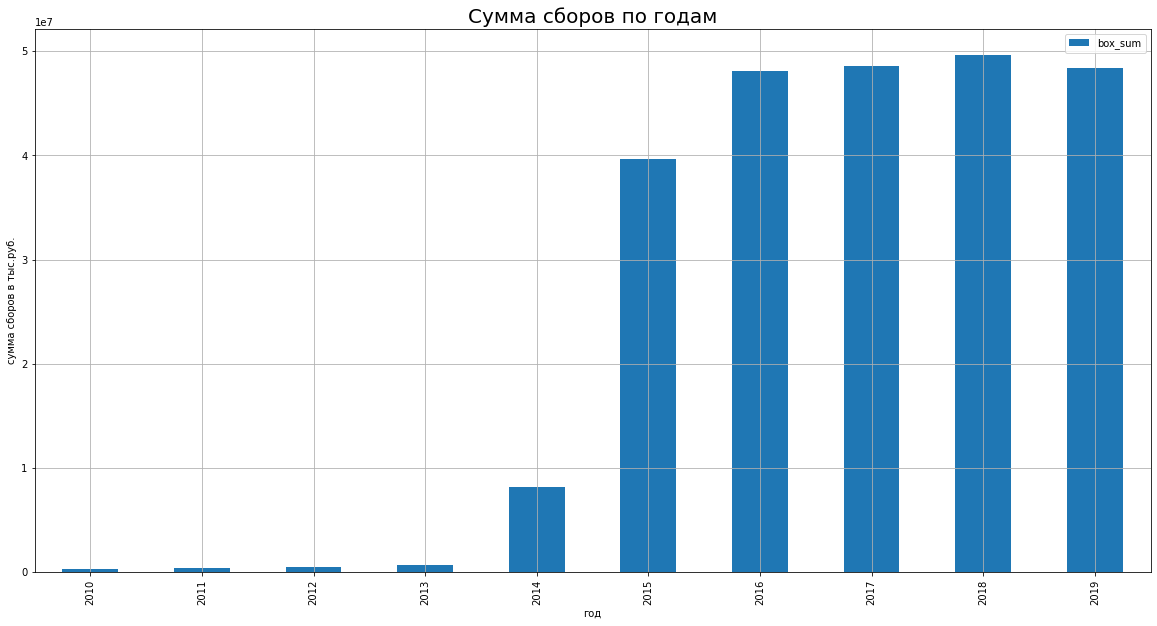

In [ ]:
box_year.plot(y='box_sum', x='year',  kind='bar',figsize = (20,10), grid=True)

plt.title('Сумма сборов по годам', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма сборов в тыс.руб.')

Наименьшие суммы сборов ожидаемо оказались в наименее представленном периоде с 2010 по 2014 (наихудшая ситуация - с 2010 по 2013). С 2015 сборы выросли (как и полнота собираемой информации), и лучшие показатели по сумме сборов оказались в период с 2016 по 2019 год. Резкий прирост случился в уже ранее замеченных за возможной модернизацией системы сбора данных 2015м годом.

Посмотрим, есть ли прямая зависмость между суммой сборов и количеством полученных прокатных удостоверений, количеством собранной информации по суммам проката и полнотой сбора данных в году.

In [ ]:
box_year['box_sum'].corr(box_year['films_count']) # считаем корелляцию

0.16998157988180068

Коэфициент корреляции Пирсона низок, что указывает на слабую связь (в наших данных) между количеством полученных прокатных удостоверений и суммами сборов (это логично, ведь сложно установить связь с тем, чего из-за пропусков почти нет в определенных годах).

In [ ]:
box_year['box_sum'].corr(box_year['box_count'])

0.9385785282183249

In [ ]:
box_year['box_sum'].corr(box_year['box_share_known'])

0.9385415759452089

А вот прямая зависимость между количеством фильмов с установленными сборами (и полнотой сбора за год этой информации) достоточно сильна даже не смотря на пропуски. Это тоже логично - чем о большем количестве вышедших в прокат фильмов мы будем знать информацию, тем выше общая сумма (так как в "копилку" идет уже какая-то сумма, а не пропуск, то есть ноль).

Посмотрим, что будет, если взглянуть только на "более благополучный" период 2015-2019 года

In [ ]:
box_year.query('2015 <=year<=2019')['box_sum']\
.corr(box_year.query('2015 <=year<=2019')['films_count']) # считаем корелляцию

0.22489687315897094

In [ ]:
box_year.query('2015 <=year<=2019')['box_sum'].corr(box_year.query('2015 <=year<=2019')['box_count'])

0.010300893246198147

In [ ]:
box_year.query('2015 <=year<=2019')['box_sum'].corr(box_year.query('2015 <=year<=2019')['box_share_known'])

-0.36986151142825047

В благополучный период связь между сборами и количеством вышедших в прокат фильмов несколько увеличилась. Зато пропала связь между сборами и количеством фильмов, о которых нам известна информация, и стала обратной (хоть и уменьшилась) связь между сборами и полнотой известной о сборах информации. Что тоже логично - чем больше нам известно, тем меньше сюрпризов может прятаться в утерянной части.

Вспомним, что в результате изучения распределения содержимого столбца `'box_office_new'` исходного датафрейма "нормальными" данными, пригодными к изучению, признаны данные, имеющие в нем значения `'!=0'` и `'< 6e+07'` (60 млн) руб. А в столбце текущего им будут эквивалентны `'!=0'` и `'< 6e+04'` тыс рублей в столбце `'box_office_mill'`.

Попробуем взглянуть на данные заново с учетом этих ограничений.

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0')\
.pivot_table(index='year', values='box_office_mill', aggfunc='sum').sort_values(by='box_office_mill')

,box_office_mill
year,
2010,339544.19
2011,379259.22
2012,511095.30
2013,721865.85
2014,1219304.00
2017,2814534.31
2015,3325080.34
2016,3480230.29
2018,3493128.00


Text(0, 0.5, 'сумма сборов в тыс.руб.')

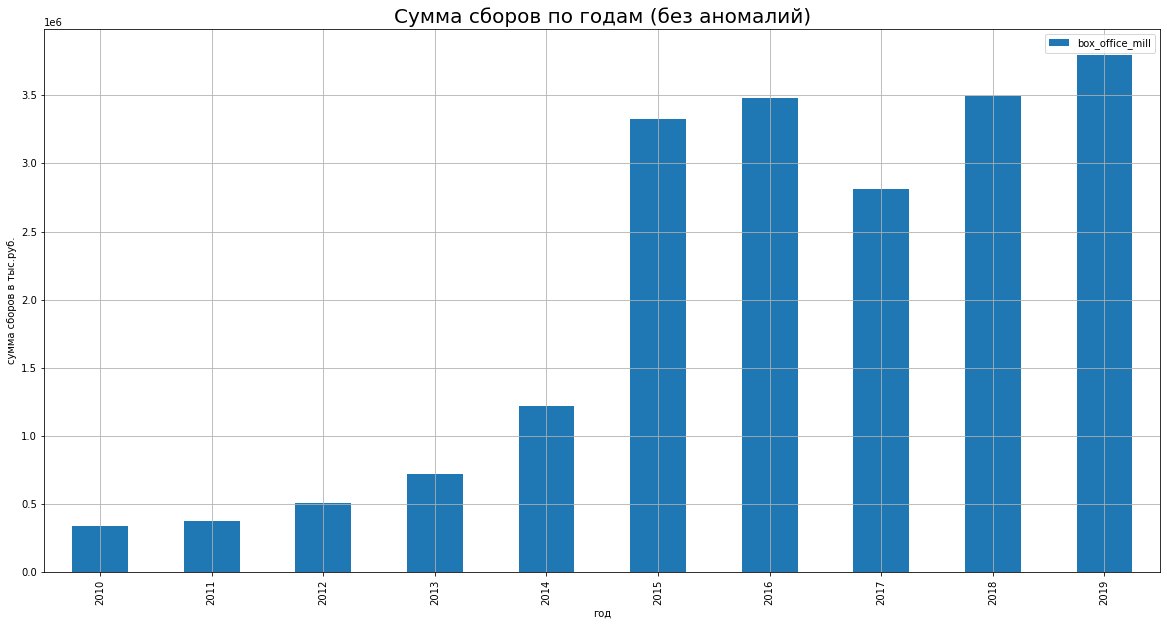

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0')\
.pivot_table(index='year', values='box_office_mill', aggfunc='sum')\
.plot(y='box_office_mill', kind='bar',figsize = (20,10), grid=True)

plt.title('Сумма сборов по годам (без аномалий)', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма сборов в тыс.руб.')

Годом с минимальными сборами так и остался 2010. А вот самым продуктивным стал 2019 год.

Рывок в сборах также произошел в 2015м.

***Выводы***

Минимальная сумма сборов (с учетом доступной для подсчетов информации) была зафиксирована в 2010 году. Максимальная (с теми же ограниченими) - 2018 году. После применения ограничений для аномалий, обнаруженных на предыдущих этапах исследования, самым продуктивным годом стал 2019. Рывок в сборах произошел в 2015 году.

Однако эти данные можно считать ограниченно достоверными ввиду большого количества пробелов в исследуемых данных. Возможно дополнительные исследования в следующих этапах дополнят или изменят ситуацию.

Также в наших данных при исследовании периода с 2014 по 2019 год обнаружены прямые положительные зависимости суммы сборов от количества фильмов (по которым есть информация о сборах) и от процента этих фильмов относительно всего вышедших в прокат. Но в более благополучный период эти зависимости падают (а для доли и вовсе становится обратной). Вероятно это связоно с тем, что чем больше нам известно информации касательно сборов фильмов, тем меньше сюрпризов может прятаться в утерянных данных и выборка становится более достоверной и репрезентативной.

Зависимость суммы сборов от количества вышедших всего в прокат фильмов не установлена вероятно ввиду большого количества пропусков в данных по сборам в определенные годы.

#### Изучение медианной и средней суммы сбора по годам.

- С помощью сводной таблицы посчитайте среднюю и медианную сумму сборов для каждого года.

Как мы поняли ранее, чтобы уверенно судить о суммах сборов за год - нужно иметь определенную полноту данных. А это не всегда возможно.

В нашем исходном датафрейме было большое количество пропусков в опеределенные периоды (настолько большое, что не удалось установить прямую зависимость между количеством выходящих в прокат фильмов и суммой сборов за этот же период, хотя с точки зрения логики она все же должна быть, пусть и не обязательно сильная).

Поэтому для более объективной оценки суммы сборов за год можно попробовать воспользоваться средним и медианой.

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0')\
.groupby('year').agg({'year':'count','box_office_mill':['mean','median']})

year box_office_mill         
     count            mean   median
year                               
2010   101     3361.823663  1230.00
2011   109     3479.442385  1630.00
2012   122     4189.305738  1060.00
2013   179     4032.770112  1360.00
2014   253     4819.383399  1070.00
2015   361     9210.748864  2875.25
2016   413     8426.707724  2186.27
2017   264    10661.114811  5090.28
2018   355     9839.797183  4695.38
2019   425     8935.199929  2888.22

Уже сейчас можно заметить, что медианы и среднее всегда рознятся, причем иногда практически в несколько раз! Даже с учетом того, что мы постарались избавится от части аномалий на этапе подготовки.

Для лучшего восприятия визуализируем это.

Text(0, 0.5, 'сумма сборов в тыс.руб.')

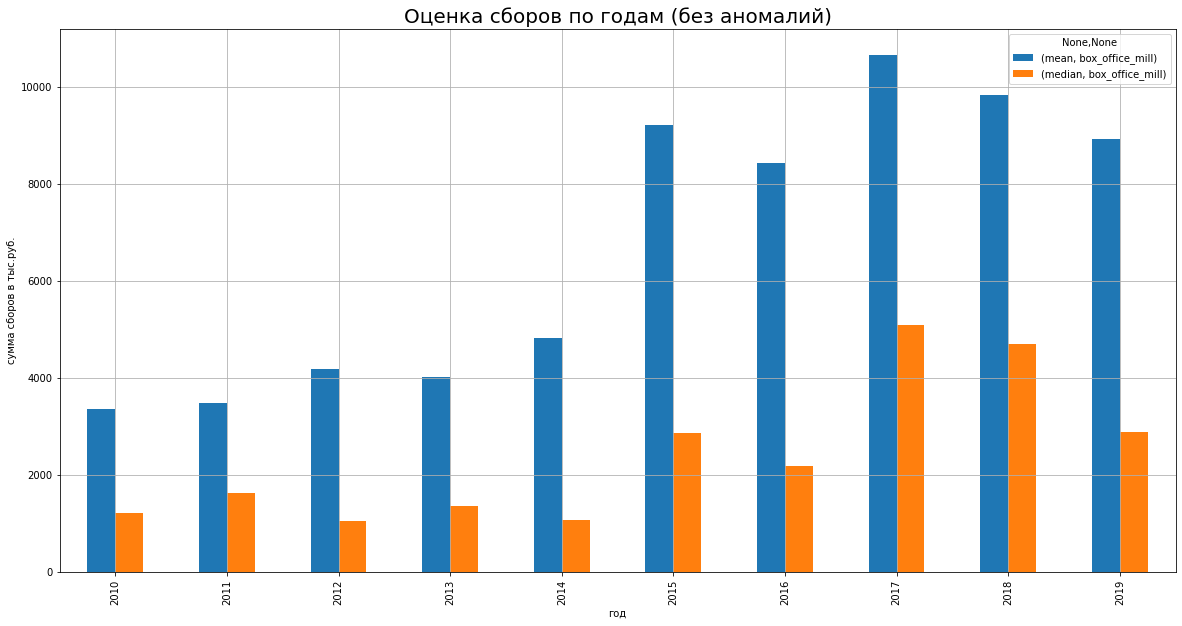

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0')\
.pivot_table(index='year', values='box_office_mill', aggfunc=['mean', 'median']).reset_index()\
.plot(y=[(  'mean', 'box_office_mill'),('median', 'box_office_mill')], x='year', kind='bar',figsize = (20,10), grid=True)

plt.title('Оценка сборов по годам (без аномалий)', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма сборов в тыс.руб.')

Медиана и среднее всегда рознятся. Иногда второе превышает первое более чем в три раза, но обычно не менее двух, что указывает на неоднородность выборки и на уже ранее отмеченную неполноту данных, их хаотичность и не слишком высокую репрезентативность. То есть все те же проблемы со сборами данных.

В период низкой полноты представленности информации (2010-2014гг) медиана не всегда повторяет тенценции (рост или падение) среднего, что указывает на ранее выявленных проблемы (малое количество самих дынных, малый процент известных данных относительно всех вышедших фильмов) и выявляет новые (черезмерную разнородности выборки, которую еще сложнее назвать репрезентативной, чем в оставшемся периоде). Зато с 2015 появилась синхронность, то есть можно уже хоть как-то судить о происходящем в сфере кассовых сборов хотя бы в общих чертах.

А еще мы наблюдаем, что 2019 год на не является лидером по сумме кассовых сборов: его превосходит 2018, а лидером становится 2017 год. Но это тоже может быть связано с проблемой качества данных в выборке (например, упущенной аномалии).

В данном случае для хоть какой-то приближенной к реальности оценки в дальнейшем лучше использовать медиану, так как она меньше подвержена влиянию выбросов и неодности выборки, в отличие от среднего.

Но на всякий случай также взглянем на полные (без исключения высоких аномалий) данные.

In [ ]:
data_research.groupby('year').agg({'year':'count','box_office_mill':['mean','median']})

year box_office_mill           
     count            mean     median
year                                 
2010   980     3233.754190   1010.000
2011   620     3479.442385   1630.000
2012   592     4024.372441   1010.000
2013   629     3923.183967   1255.000
2014   805    29333.400143   1260.000
2015   705    85220.448473   5831.860
2016   817    91539.610743   4640.700
2017   505   136122.922605  10387.320
2018   879   104785.568671   8911.530
2019   926    91391.071943   4693.585

Text(0, 0.5, 'сумма сборов в тыс.руб.')

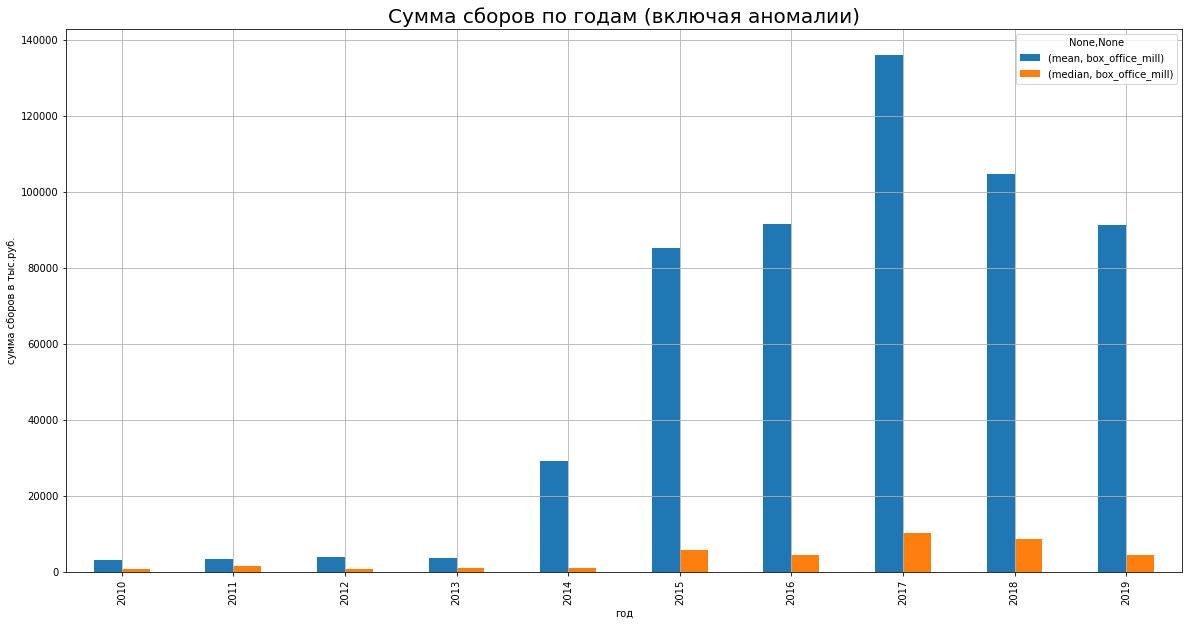

In [ ]:
data_research.pivot_table(index='year', values='box_office_mill', aggfunc=['mean', 'median']).reset_index()\
.plot(y=[(  'mean', 'box_office_mill'),('median', 'box_office_mill')], x='year', kind='bar',figsize = (20,10), grid=True)

plt.title('Сумма сборов по годам (включая аномалии)', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма сборов в тыс.руб.')

Среднее по-прежнему превышает медиану (только уже на большее количество раз, начиная с 2014 года). Что еще раз подтверждает "сложность" данных в датафрейме, в том числе ввиду большого количества пропусков по части сумм кассовых сборов. А таже то, что взятые нами ранее данные более пригодны для ведения исследования.

***Выводы***

Средняя сумма сборов всегда превышает медиану от двух до более чем в три раза, что указывает на крайнюю неоднородность выборки, обусловленную проблемами со сбором и учетом данных по прокатным сборам.

В период низкой полноты представленности информации (2010-2014гг) медиана не всегда повторяет тенценции (рост или падение) среднего. Зато с 2015 появилась синхронность.

Проведенное исследование изменяет полученное ранее представление о наиболее денежных годах: лидером по сумме сборов становится 2017 год. Но это тоже может быть связано с проблемой качества данных в выборке (например, упущенной аномалии).

В данном случае для хоть какой-то приближенной к реальности оценки в дальнейшем лучше использовать медиану, так как она меньше подвержена влиянию выбросов и неодности выборки. А для исследования тенденций по сборам - период с 2015 по 2019 год.

#### Изучение влияния возрастного ограничения аудитории

- Определите, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да, предположите, с чем это может быть связано.

Посмотрим, как у нас меняется картина сборов в зависимости от возрастного рейтинга.

Так как по периоду с 2010 по 2014 у нас очень мало информации (и она недостаточного качества), то для данного иследования мы возьмем менее проблемный период с 2015 (когда, вероятно, что-то изменилось в процессе сборов и сохранения необходимой информации) по 2019.

Применять мы будем медиану, так как она менее подвержена влиянию качества выборки.

Упрощенные варианты сводных таблиц выводят не очень удобный для восприятия вариант. Для наглядности можно сразу "агрегировать дважды", а после произвести визуализацию.

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'age', values='box_office_mill', aggfunc='median') # таблица

age,0+,6+,12+,16+,18+
year,,,,,
2015,2949.800,2506.200,3256.54,2106.930,3981.180
2016,2804.260,1987.565,1900.00,1750.740,3269.195
2017,11560.365,5768.685,3648.77,5251.120,5137.410
2018,3616.930,5544.080,2440.53,4216.355,5129.690
2019,3885.430,3465.460,2093.51,1965.550,4146.180


Уже можно наблюдать определенные динамики. Но таблицу можно усовершенствовать, чтобы было видно и общие суммы медиан сборов по возрастам и по годам.

In [ ]:
data_age = data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='age', columns = 'year', values='box_office_mill', aggfunc='median').reset_index()  # таблица

In [ ]:
def sum_box (row):
    try:
        return row[2015] + row[2016] + row[2017] + row[2018] + row[2019]
    except:
        pass

In [ ]:
data_age['sum_median'] = data_age.apply(sum_box, axis=1)

In [ ]:
data_age.loc[len(data_age.index)] = ['sum_median', data_age[2015].sum(), data_age[2016].sum(), data_age[2017].sum(),\
                                     data_age[2018].sum(), data_age[2019].sum(), data_age['sum_median'].sum()]

In [ ]:
data_age #проверка

year,age,2015,2016,2017,2018,2019,sum_median
0,0+,2949.80,2804.260,11560.365,3616.930,3885.43,24816.785
1,6+,2506.20,1987.565,5768.685,5544.080,3465.46,19271.990
2,12+,3256.54,1900.000,3648.770,2440.530,2093.51,13339.350
3,16+,2106.93,1750.740,5251.120,4216.355,1965.55,15290.695
4,18+,3981.18,3269.195,5137.410,5129.690,4146.18,21663.655
5,sum_median,14800.65,11711.760,31366.350,20947.585,15556.13,94382.475


Лидером по сумме медиан сборов за данный период стали фильмы с возрастным рейтингом "0+". Наименьшая сумма медиан сборов у фильмов "12+".

Лидером по сборам (сумме медиан) вновь стал 2017 год, что можно, вероятно, объяснить тем, что фильмов в тот год вышло меньше, чем в другие периоды, однако информация по ним была наиболее полной за весь период исследования. С другой одновременно фильмы в том году могли быть действительно более кассовыми, чем в прочих.

График поведения медиан сборов по годам мы уже видели ранее, суммы медиан ведут себя аналогично. Теперь же посмотрим сборы по годам в разрезе возрастного рейтинга.

Text(0, 0.5, 'медиана сбора в тыс.руб.')

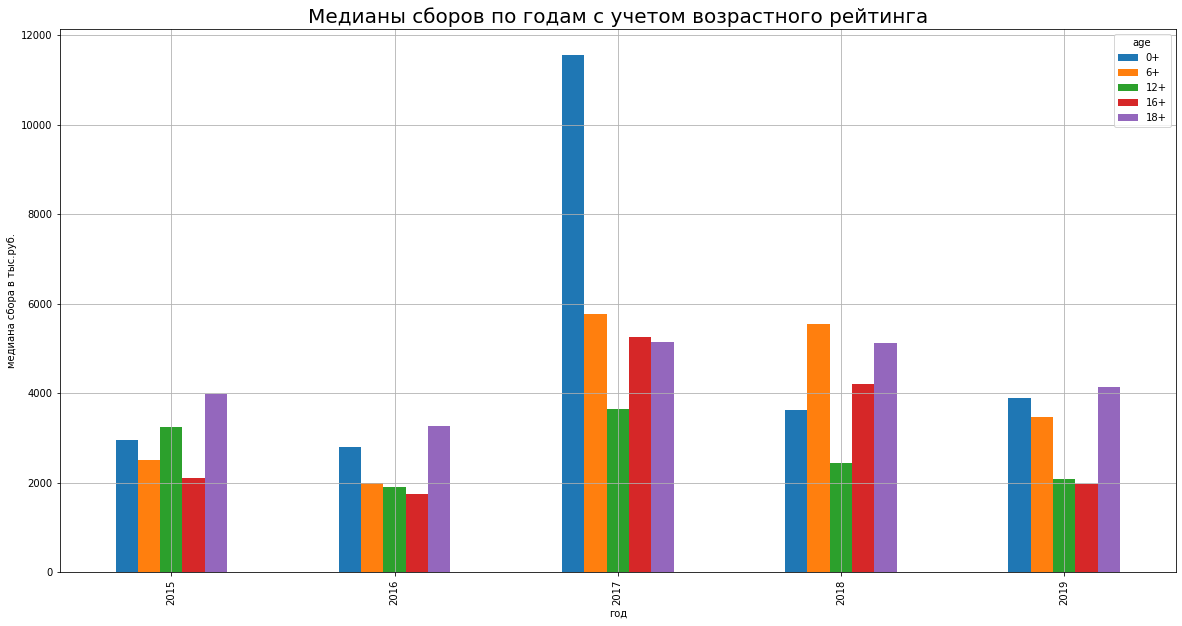

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'age', values='box_office_mill', aggfunc='median')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график годовой структуры

plt.title('Медианы сборов по годам с учетом возрастного рейтинга', fontsize=20)
plt.xlabel('год')
plt.ylabel('медиана сбора в тыс.руб.')

Text(0, 0.5, 'медиана сборов в тыс.руб.')

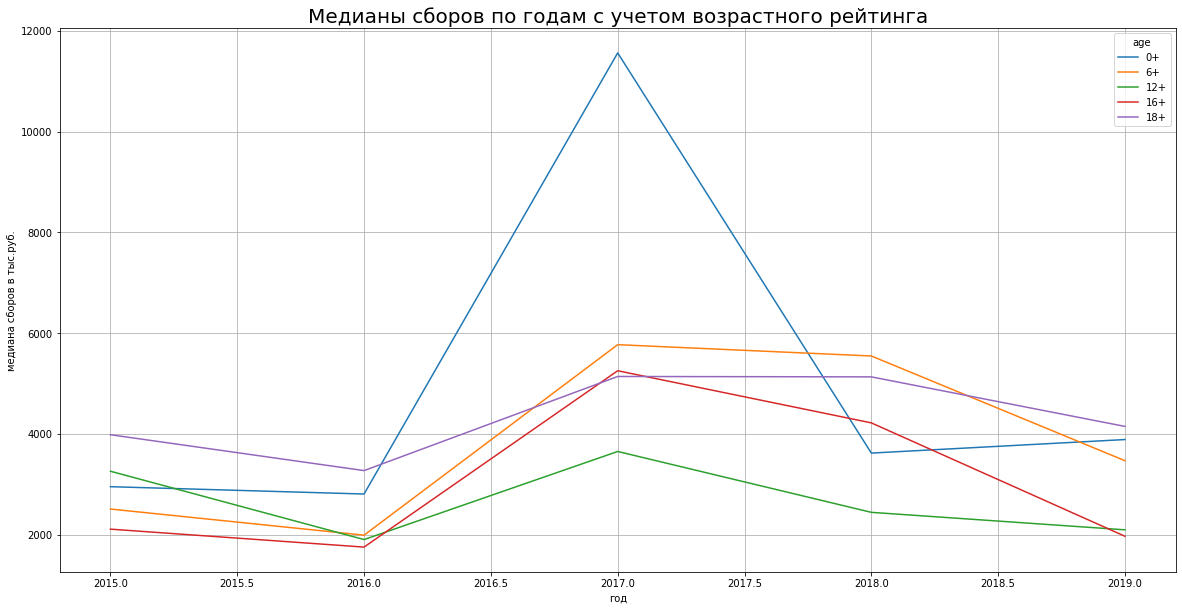

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'age', values='box_office_mill', aggfunc='median')\
.plot(grid = True, figsize = (20,10)) # график динамики по годам

#plt.yticks()
plt.title('Медианы сборов по годам с учетом возрастного рейтинга', fontsize=20)
plt.xlabel('год')
plt.ylabel('медиана сборов в тыс.руб.')

Как мы видим, четкой сборов фильма с конкретным рейтингом нет: лидеры и оутсайдеры меняются. Это может быть связано со "структурой рынка" определенного года: возможно в разные годы выходило разное количество фильмов с определенным рейтингом, и если фильмов "0+" в кинотеатре больше, то и шансы "собрать кассу" у них тоже выше.

Попробуем это проверить.

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'age', values='title', aggfunc='count') # таблица

age,0+,6+,12+,16+,18+
year,,,,,
2015,36,32,45,133,115
2016,39,52,59,137,126
2017,2,24,29,91,118
2018,5,42,41,118,149
2019,3,54,67,146,155


Text(0, 0.5, 'количество вышедших фильмов')

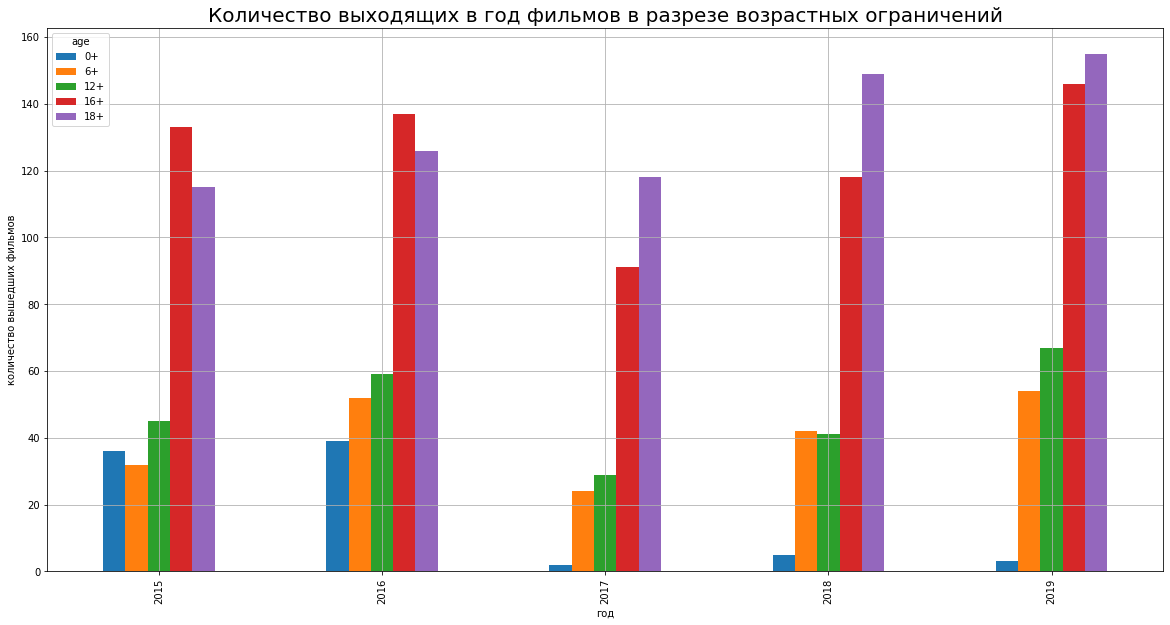

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'age', values='title', aggfunc='count')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график годовой структуры

plt.title('Количество выходящих в год фильмов в разрезе возрастных ограничений', fontsize=20)
plt.xlabel('год')
plt.ylabel('количество вышедших фильмов')

Как мы видим, это предположение не совсем оправдалось: структура проката в целом схожа из года в год. Больше всех в прокат выходит фильмов с рейтингами "16+" и "18+", меньше всего - фильмов рейтинга "0+" (лишь в одном году они заняли предпоследнее место).

В 2017 году вышло всего 2 (что само по себе выглядит странно на фоне предыдущих двух лет) фильма с таким рейтингом, но они умудрились обогнать остальных! Возможно, это аномалия данных, упущенная ранее?

Попробуем посмотреть на эти фильмы:

In [ ]:
data_research.query('box_office_mill < 6e+04 and age == "0+" and year == 2017')

,title,main_director,year,main_genre,type,age,ratings,box_office_mill,help
3475,Маша и медведь. Новые истории,Г.Орлов,2017,NaN,Анимационный,0+,NaN,941.78,False
5552,"Колобанга. Привет, Интернет!",А.Романец,2017,мультфильм,Анимационный,0+,4.9,22178.95,False


Данные относятся к двум крайностям: один фильм собрал более чем в 22 раза больше другого! Тут даже медиана бессильна. А искажение данной медианы дало нам искажение суммы медиан за этот год, что привело к проблемам с выявлением лидеров проката.

Интересно, может этот же фильм дал нам пик общих сборов в 2017 году?

In [ ]:
data_research.query('box_office_mill < 6e+04 and age == "0+" and year == 2017')['box_office_mill'].max()

22178.95

Да, само его присутсвие дало сильные искажения данных по сборам. Вероятно, похожая картина (наличие искажающих факторов) может быть и для других категорий.

Взглянем на сборы, использовав "абсолютные величины" (то есть имеющиеся у нас данные о сумме прокатов).

Text(0, 0.5, 'сумма сборов в тыс.руб.')

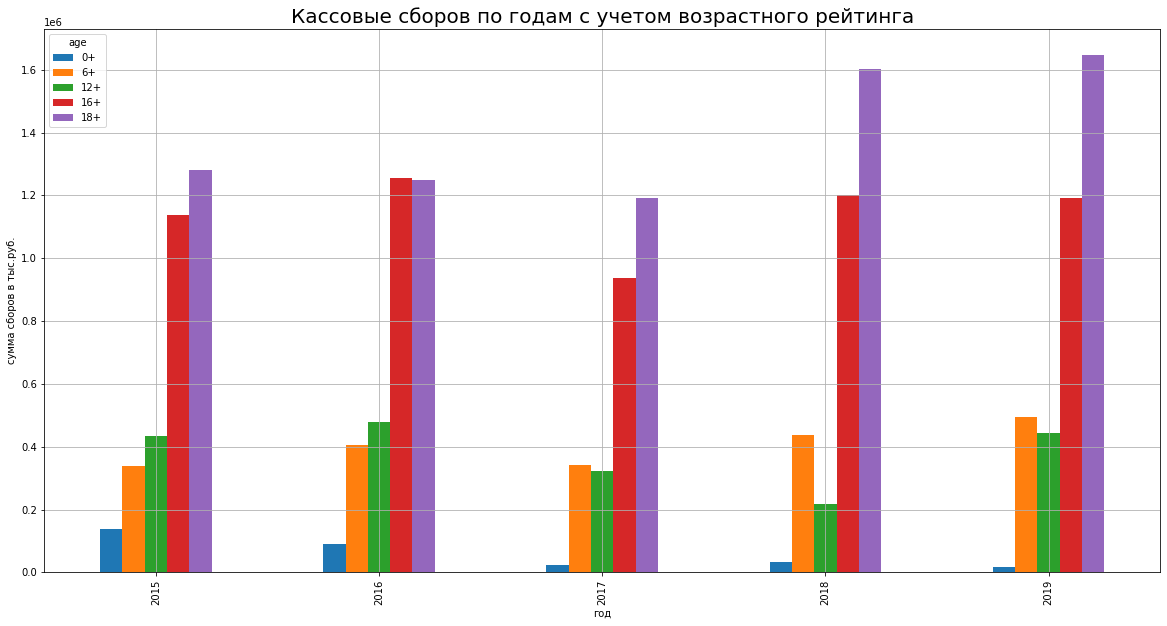

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'age', values='box_office_mill', aggfunc='sum')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график динамики по годам

plt.title('Кассовые сборов по годам с учетом возрастного рейтинга', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма сборов в тыс.руб.')

По имеющимся у нас данным по суммам сбора ситуация по годам несколько меняется, но лидеры и аутсайдеры те же: больше всего в прокате собирают фильмы "16+" и "18+", меньше всего - фильмов рейтинга "0+". И здесь наконец стала видна некоторая зависимость (логично ожидаемая, но не сумевшая подтвердить себя из-за скудности данных) между количеством попадающих в прокат фильмов определенного рейтинга и их сборами: чем больше фильмов, тем больше сборы.

Однако все это лишь ориентировочные данные, для оценки общих тенденций, так как выборка неполноценна: в ней имеются пробелы не только по данным кассовых сборов, но и похоже утеряны сами фильмы, выходившие в прокат.

***Выводы***

Для данного исследования был выбран период 2015-2019 годы как наиболее полный по касающейся кассовых сборов фильмов информации.

Больше всего в прокате собирают фильмы с возрастным рейтингом `'«16+» - для детей старше 16 лет'` и `'«18+» - запрещено для детей'`, меньше всего - `'«0+» - для любой зрительской аудитории'`. Это может быть связано с тем, что фильмов из первых двух категорий в принципе выходит в прокат больше, чем третьих.

Также замечено, что фильмов с возрастным рейтингом `'«0+» - для любой зрительской аудитории'` в принципе необычно мало в выборке за период 2017-2019 на фоне периода 2015-2016, что может быть связано с тем, что их выходило в прокат меньше в принципе, либо они не попали в наш датафрейм по каким-либо причинам.

#### Изучение влияния типа фильма

Пусть ТЗ этого не требует, но раз уж мы взяли в датафрейм для исследования столбец с типом фильма, то можно взглянуть и на него.

Возьмем все тот же период 2015-2019 год.

Text(0, 0.5, 'количество')

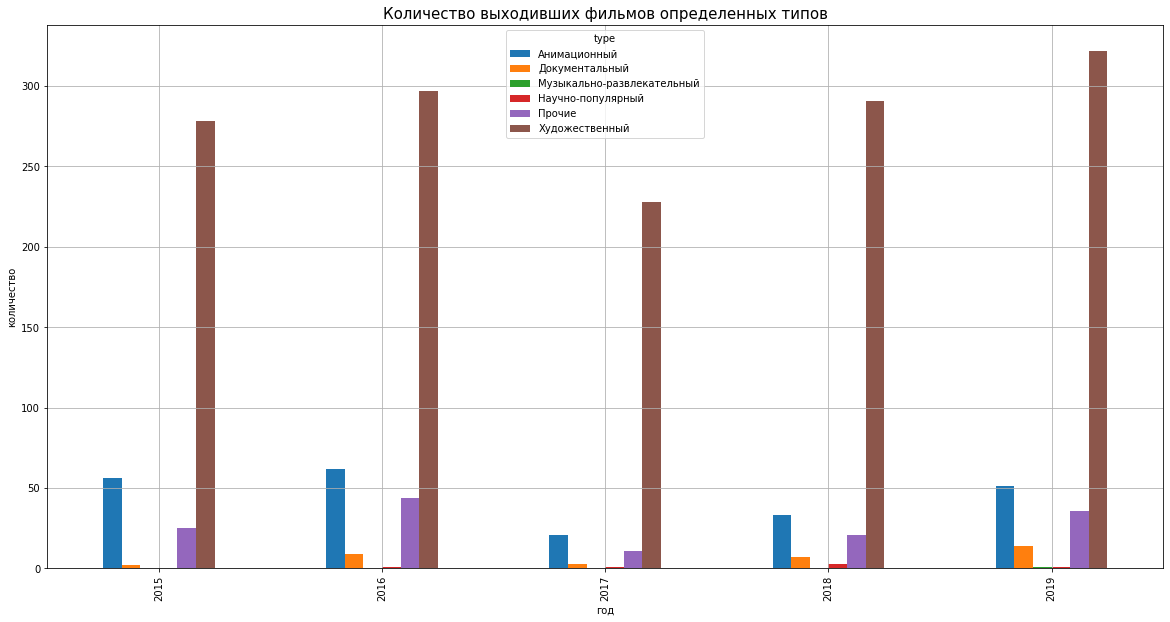

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'type', values='title', aggfunc='count')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график по количеству выходящих в год

plt.title('Количество выходивших фильмов определенных типов', fontsize=15)
plt.xlabel('год')
plt.ylabel('количество')

Больше всего в прокат по количеству выходит независимо от, как и ожидалось, художественные фильмы. На втором месте с большим отставанием - анимационные. Последние места с количеством чуть более нескольуих штук занимают музыкально-развлекательные, иногда разделяя его с научно-популярными.

Text(0, 0.5, 'сумма в тыс.руб.')

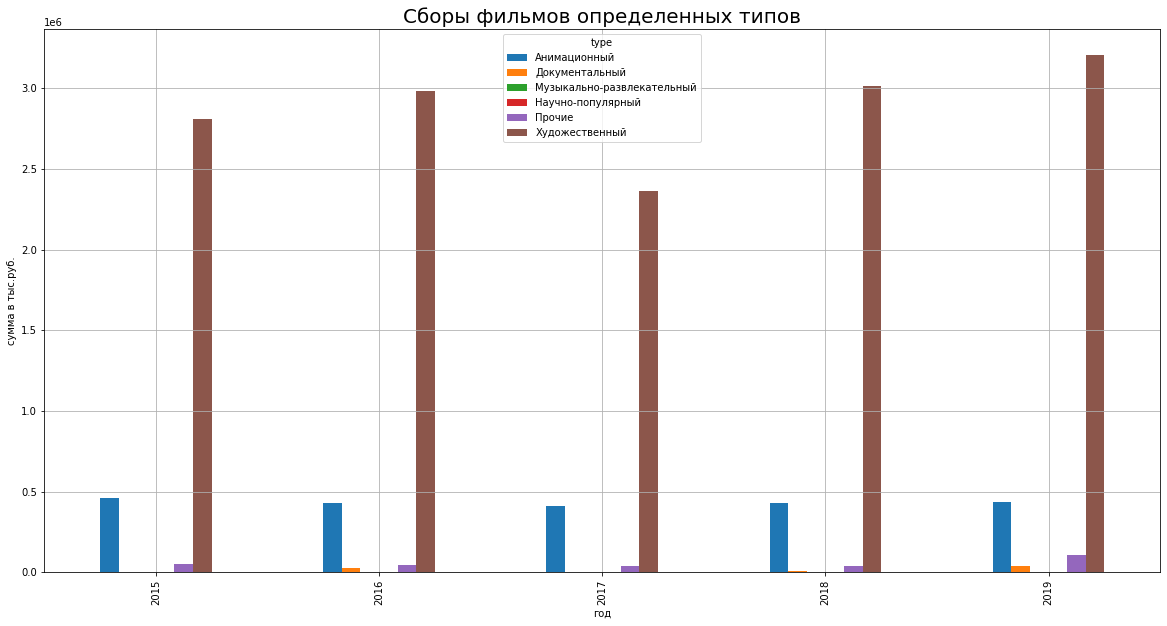

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'type', values='box_office_mill', aggfunc='sum')\
.plot(kind = 'bar', grid = True, figsize = (20,10))  # график сборов в год по имеющимся значениям

plt.title('Сборы фильмов определенных типов', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма в тыс.руб.')

По имеющимся у нас данным сумм сборов лидерами проката с большим отрывом от конкурентов также являются художественные фильмы. Анимационые хоть и остались на втором месте, но общая сумма сборов у них значительно меньше.

Также замечено, что оба графика показывают одинаковую картинку по поведению в годах для художественных фильмов, а вот для анимационных уровень практически один и тот же независимо от года. Возможно, в наш датафрейм попало большинство из вышедших в прокат художественных фильмов и информация о них была полнее, чем о фильмах остальных жанров? Которых могло попасть в принципе меньше и касающася кассовых сборов информация о попавших утеряна больше, чем для художественных.

Text(0, 0.5, 'медианы сборов в тыс.руб.')

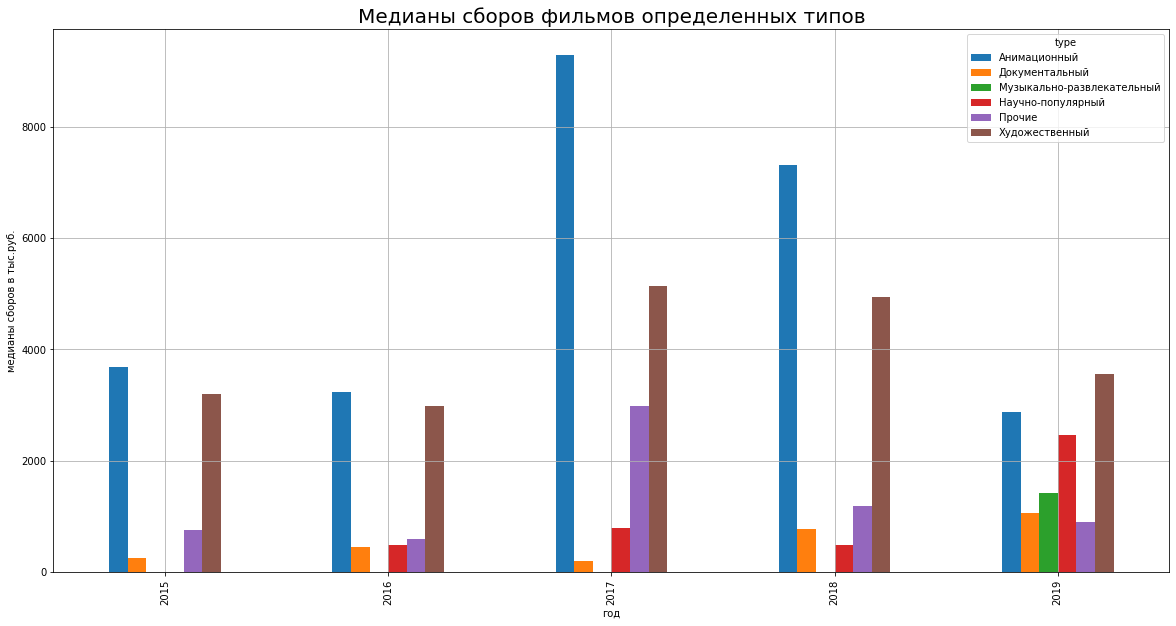

In [ ]:
data_research.query('box_office_mill < 6e+04 and box_office_mill !=0 and 2015<= year <=2019')\
.pivot_table(index='year', columns = 'type', values='box_office_mill', aggfunc='median')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график по медиане сборов в год

plt.title('Медианы сборов фильмов определенных типов', fontsize=20)
plt.xlabel('год')
plt.ylabel('медианы сборов в тыс.руб.')

Если судить по медиане сумм сборов то анимационные фильмы начинают составлять конкуренцию художественным. Но, как мы уже могли обратить внимание ранее, при исследовании влияния возрастного рейтинга, это могут быть искажения выборки (как минимум для 2017 года), особенно с учтом того, что имеющася абсолютная сумма сборов для них была практически на одном уровне независимо от года при том, что художественные были в большом отрыве от остальных.

***Выводы***

Для данного исследования был выбран период 2015-2019 годы как наиболее полный по касающейся кассовых сборов фильмов информации.

Больше всего в прокат независимо от года выходило художественных фильмов, на втором месте с большим отставанием - анимационные. Последние места с количеством чуть более нескольких штук занимают музыкально-развлекательные, иногда разделяя его с научно-популярными.

По абсолютным имеющимся у нас суммам сборов также лидируют художественные фильмы, второе место - у анимационных.

При сравнении медиан сумм сборов анимационные практически всегда обгоняют художественные, что связано с искажениями выборки данных из-за неполноты имеющейся информации.

***Выводы***

Наиболее полно в данных о прокате представлен период с 2015 по 2017 год, наименее с 2010 по 2014. В период низкой полноты представленности информации (2010-2014гг) медиана не всегда повторяет тенценции (рост или падение) среднего. Зато с 2015 появилась синхронность. Эти особенности привели к исключению из большинства исследований раздела периода с 2010 по 2014 год.

Минимальная сумма сборов была зафиксирована в 2010 году. Максимальная (с теми же ограниченими) - 2019 году. Если взять "благополучный период" (2015-2019 года), то минимум зафиксирован в 2015 году, в котором произошел "рывок сборов", что может быть связано с усовершенствованием системы сбора данных, касающихся кассовых сборов фильмов.

Средняя сумма сборов всегда превышает медиану от двух до более чем в три раза, что указывает на крайнюю неоднородность выборки, обусловленную проблемами со сбором и учетом данных по прокатным сборам. Потому для хоть какой-то приближенной к реальности оценки в исследованиях опирались не среднее, а на медиану, так как она меньше подвержена влиянию выбросов и неодности выборки.

Больше всего в прокате собирают фильмы с возрастным рейтингом `'«16+» - для детей старше 16 лет'` и `'«18+» - запрещено для детей'`, меньше всего - `'«0+» - для любой зрительской аудитории'`. Это может быть связано с тем, что фильмов из первых двух категорий в принципе выходит в прокат больше, чем третьих.

Также замечено, что фильмов с возрастным рейтингом `'«0+» - для любой зрительской аудитории'` в принципе необычно мало в выборке за период 2017-2019 на фоне периода 2015-2016, что может быть связано с тем, что их выходило в прокат меньше в принципе, либо они не попали в наш датафрейм по каким-либо причинам.

Больше всего в прокат независимо от года в период с 2015 по 2019 год выходило `'художественных'` фильмов, на втором месте с большим отставанием - `'анимационные'`. Последние места с количеством чуть более нескольких штук занимают `'музыкально-развлекательные'`, иногда разделяя его с 'научно-популярными'.

По абсолютным имеющимся у нас суммам сборов также лидируют `'художественные'` фильмы, второе место - у `'анимационных'`.

При сравнении медиан сумм сборов `'анимационные'` практически всегда обгоняют `'художественные'`, что связано с искажениями выборки данных из-за неполноты имеющейся информации.

Сложности с исследованием датафрейма могут быть связаны с неполнотой имеющейся информации по вошедшим в выборку фильмам, выборочное попадание фыильмов определенных жанров и возрастных рейтингов из тех, что в принципе выходили в прокат. А также отсутсвием возможности выявить и объединить фильмы-дубли, вышедшие в прокат в одном году, а потому каждый из них учитывается как отдельный фильм.  

### Шаг 4. Исследуйте фильмы, которые получили государственную поддержку

На этом этапе нет конкретных инструкций и заданий — поищите интересные закономерности в данных. Посмотрите, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

Для исследования фильмов, получивших господдержку, нам потребуется новый датафрейм.

Вновь вспомним, какие у нас были колонки в исходном.

In [ ]:
data.columns

Index(['title', 'pu_number', 'show_start_date', 'year', 'type', 'film_studio',
       'production_country', 'main_director', 'director', 'producer', 'age',
       'age_restriction', 'help', 'help_share', 'refundable_support',
       'non_refundable_support', 'budget', 'financing_source', 'ratings',
       'main_genre', 'genres', 'box_office', 'box_office_new',
       'box_office_mill'],
      dtype='object')

Номер прокатного удостоверения, дата старта проката и развернутые сведения о создателях нам вряд ли пригодятся. Также не требуется столбец с указанием на наличие или отсутсвие господдержки (но по нему можно провести срез), так как все фильмы в нашем датарейме уже будут с господдержкой. Не нужны все три столбца с суммами сборов (хватит одного, но в тех же единицах, что и остальные финансы), и перечня жанров (пусть и "основной жанр" - понятие несколько условное, но вдруг будет замечена какая-то закономерность?)

Министерство культуры и Фонд кино спонсировали фильмы как по-отдельности, так и совместно, поэтому разделить вклад и сказать, чей где был больше - проблематично. Значит столбец с источником также можно не включать.

Посмотрим, нужна ли нам информация о режиссере.

In [ ]:
len(data.query('help == True')['main_director'].unique())

271

In [ ]:
data.query('help == True')['main_director'].value_counts().head(50)

Р.Давлетьяров     5
С.Андреасян       4
Д.Дьяченко        4
К.Шипенко         3
Н.Хомерики        3
С.Мокрицкий       3
А.Цицилин         3
А.Аксененко       3
Д.Шмидт           3
А.Котт            3
А.Пиманов         2
Ф.Дмитриев        2
И.Северов         2
П.Лунгин          2
В.Тодоровский     2
А.Прошкин         2
А.Карпиловский    2
А.Матисон         2
А.Темников        2
Д.Месхиев         2
П.Руминов         2
Т.Бекмамбетов     2
С.Подгаевский     2
Д.Тюрин           2
И.Твердовский     2
М.Волков          2
Р.Прыгунов        2
В.Ровенский       2
В.Глаголева       2
Д.Киселев         2
А.Федорченко      2
А.Войтинский      2
А.Волгин          2
А.Меликян         2
Р.Каримов         2
М.Расходников     2
А.Пармас          2
Л.Марголин        2
А.Богуславский    2
Н.Джорджадзе      2
Н.Меркулова       2
К.Дружинин        2
А.Галибин         2
К.Худяков         2
А.Якимчук         2
В.Хотиненко       2
Р.Гигинеишвили    2
В.Щегольков       1
А.Сидоров         1
С.Соколов         1


У нас 271 режиссер на 332 фильма. Лишь 47 из них создало два и более фильма - не выйдет найти закономерностью между популярностью/кассовыми сборами фильма и его режиссером. Дополнительно можно взглянуть разве что на трех режиссеров-рекордосменов, но это можно сделать отдельно потом. А сейчас выходит, что столбец с главным режиссером нам не требуется.

Создадим новый датафрейм

In [ ]:
data_help = data.query('help == True')[['title', 'year', 'type', 'age',
       'help_share', 'refundable_support', 'non_refundable_support', 'budget', 'ratings',
       'main_genre', 'box_office_new']].copy().reset_index(drop= True) # создание

In [ ]:
data_help # проверка

,title,year,type,age,help_share,refundable_support,non_refundable_support,budget,ratings,main_genre,box_office_new
0,Пока еще жива,2013,Художественный,16+,33.3,0.0,26500000.0,79411900.0,8.1,драма,3.653536e+05
1,Бесславные придурки,2014,Художественный,12+,70.0,0.0,26000000.0,37142857.0,NaN,NaN,2.814000e+04
2,Невидимки,2013,Художественный,12+,61.2,0.0,107847945.0,176023490.0,5.3,комедия,1.995703e+07
3,БЕРЦЫ,2014,Художественный,16+,69.0,0.0,28000000.0,40574140.0,4.2,драма,5.591750e+04
4,Братья Ч,2014,Художественный,16+,62.4,0.0,25000000.0,40015122.0,6.4,драма,2.321000e+05
...,...,...,...,...,...,...,...,...,...,...,...
327,Союз спасения,2019,Художественный,12+,51.0,100000000.0,400000000.0,980000000.0,6.0,история,7.177032e+08
328,Иван Царевич и Серый Волк 4,2019,Анимационный,6+,52.6,100000000.0,0.0,190000000.0,6.7,мультфильм,5.010692e+08
329,Вторжение,2019,Художественный,12+,52.9,100000000.0,400000000.0,944000000.0,5.7,фантастика,NaN
330,Я свободен,2019,Художественный,12+,64.9,0.0,30000000.0,46154000.0,5.9,драма,NaN


Информация из выбранных столбцов перенесена успешно, количество строк совпало с ранее наблюдаемыми.

#### Первый взгляд на датафрейм

Чтобы определить наиболее перспективные направления для изучения, сначала попробуем взглянуть на гистограммы всего нового датафрейма.

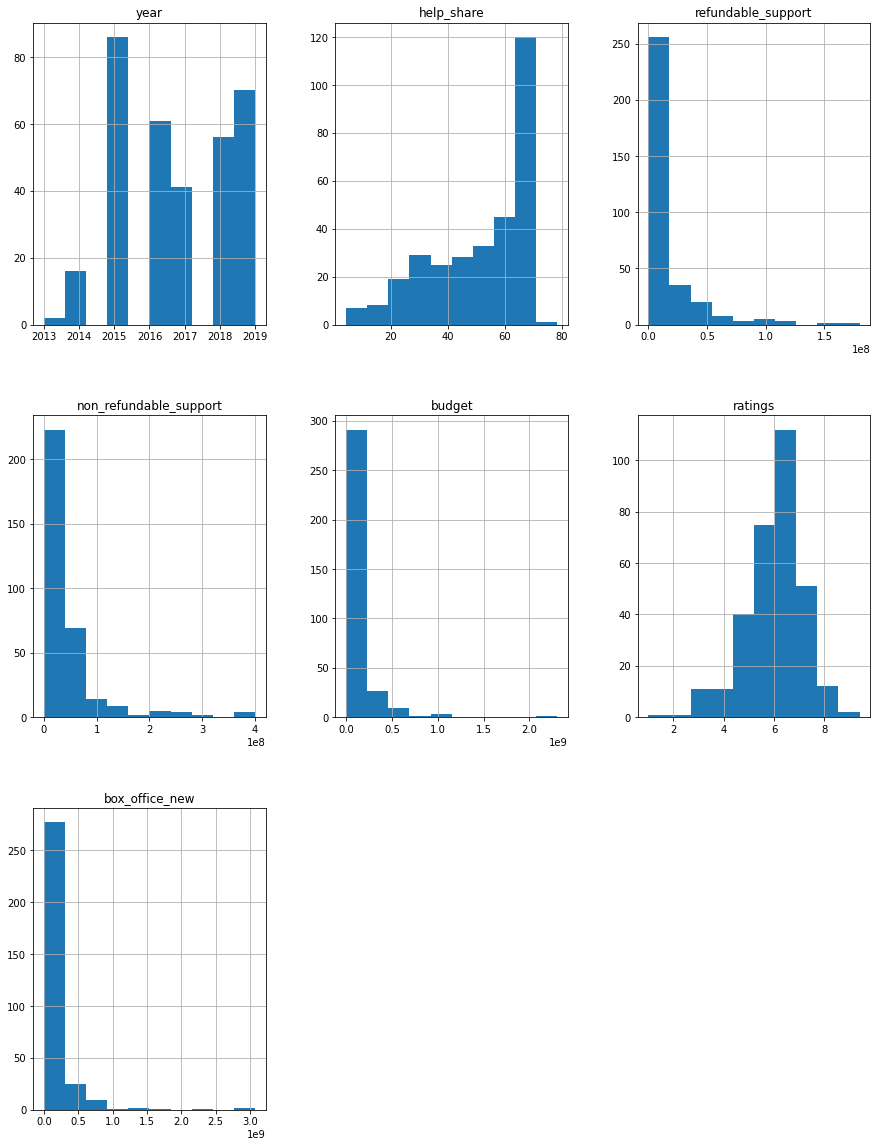

In [ ]:
data_help.hist(figsize=(15,20));

По гистограммам можно предположить, что фильмы с господдержкой начали снимать (или, по крайней мере, попали в нашу выборку) с 2013 года, когда был зафиксирован минимум таких фильмов. Максимум же был представлен в 2015 году.

Большая половина фильмов получила господдержку на уровне 60-70%, минимальная была около 5%, максимальная - около 80%. Полную господдержку (на сумму всего бюджета) не получил ни один фильм из выборки.

Основная часть возвратных сумм была до 0.5 le8 (50 млн) руб, невозвратных - до 0.7 le8 (70 млн) руб, то есть безвозвратно отдавались большие суммы, чем с обязательсвом по возврату.

Бюджет большинства фильмов не превышает 0.25 le9 (250 млн) руб. Присем основная часть гистограммы сборов очень напоминает таковую у бюджета.

Средний полученный рейтинг - 7 баллов, максимальный - около 9, но есть и антирекорд - около единицы.

Возможно, потребуется посмотреть на некоторые гистограммы поближе. А пока взглянем на матрицу корелляций.

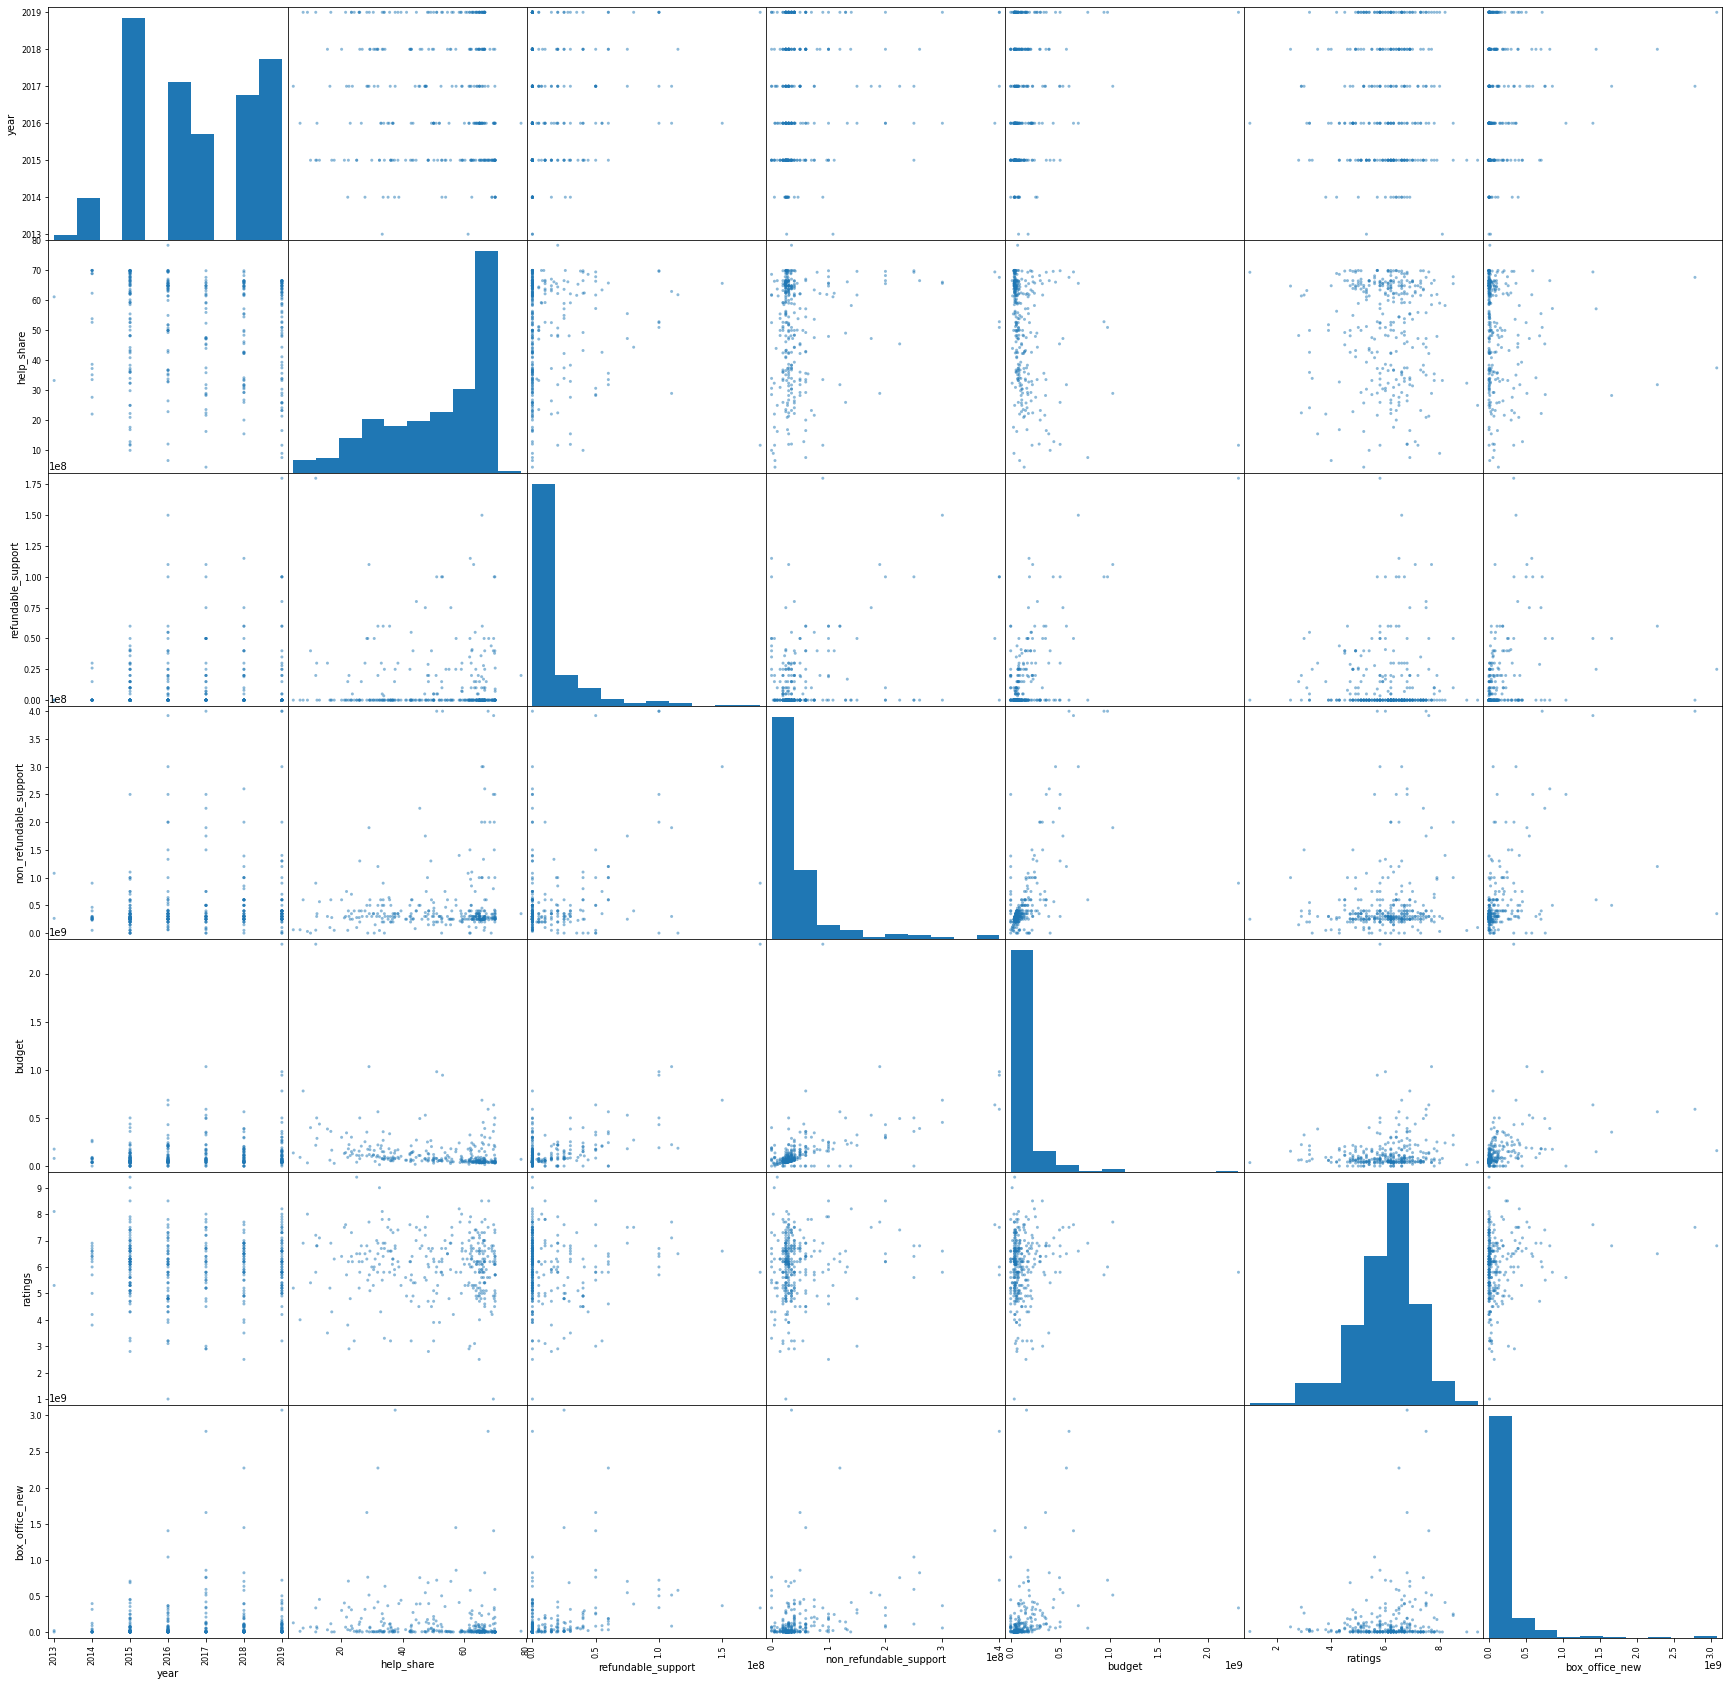

In [ ]:
pd.plotting.scatter_matrix(data_help, figsize=(30,30));

In [ ]:
data_help.corr()

,year,help_share,refundable_support,non_refundable_support,budget,ratings,box_office_new
year,1.000000,-0.073072,0.089616,0.117645,0.164640,0.024965,0.118956
help_share,-0.073072,1.000000,-0.025318,0.120277,-0.298279,-0.046461,-0.117179
refundable_support,0.089616,-0.025318,1.000000,0.359622,0.641224,-0.003797,0.312082
non_refundable_support,0.117645,0.120277,0.359622,1.000000,0.594169,0.125646,0.455641
budget,0.164640,-0.298279,0.641224,0.594169,1.000000,0.093117,0.361227
ratings,0.024965,-0.046461,-0.003797,0.125646,0.093117,1.000000,0.143681
box_office_new,0.118956,-0.117179,0.312082,0.455641,0.361227,0.143681,1.000000


Матрица указывает на отсутствие (или весьма слабую) прямую зависимость между годом выхода фильма и чем-либо еще.

Прямая положительная зависимость средней степени видна между бюджетом и возвратной суммой господдержки, а также бюджетом и невозвратной. Что выглядит логично, ведь суммы поддержки наверняка фиксируются не только в абсолютной сумме, но и в относительной, то есть в процентах, на что указывает хоть и слабая, но имеющаяся обратная зависимость между общим бюджетом и процентом в нем суммы господдержки (чем больше бюджет - тем меньше составляет процент).

Сборы выявили лишь среднюю прямую зависимость от невозвратной суммы поддержки и ниже средней - от суммы общего бюджета. Возможно, чем дороже фильм, тем он зрелещней или получает больше рекламы, а потому люди идут охотнее его смотреть.

***Выводы***

По постронным для всего датафрейма гистограммам можно предположить, что фильмы с господдержкой начали снимать (или, по крайней мере, попали в нашу выборку) с 2013 года, когда был зафиксирован минимум таких фильмов. Максимум же был представлен в 2015 году.

Большая половина фильмов получила господдержку на уровне 60-70%, минимальная была около 5%, максимальная - около 80%. Полную господдержку (на сумму всего бюджета) не получил ни один фильм из выборки.

Основная часть возвратных сумм была до 50 млнруб, невозвратных - до 70 млн руб, то есть безвозвратно отдавались большие суммы, чем с обязательсвом по возврату.

Бюджет большинства фильмов не превышает 250 млн руб. Причем основная часть гистограммы сборов очень напоминает таковую у бюджета.

Средний полученный рейтинг - 7 баллов, максимальный - около 9, но есть и антирекорд - около единицы.

Матрицы рассеяния не выявили сильных зависимостей внутри датафрема.

Прямая положительная зависимость средней степени видна между бюджетом и возвратной суммой господдержки, а также бюджетом и невозвратной. Сборы выявили лишь среднюю прямую зависимость от невозвратной суммы поддержки и ниже средней - от суммы общего бюджета.

#### Тенденции по годам

Посмотрим структуру снятых с господдержкой фильмов по годам. Пусть у нас не так много фильмов, но увидеть результат для тех данных, которые не попали в матрицу рассеяния, тоже может быть интересно.

Медианная доля госсподдержки в зависимости от возрастного рейтинга (для лучшей наглядности график типа 'bar' может не подойти).

Text(0, 0.5, 'процент господдержки в бюжете фильма')

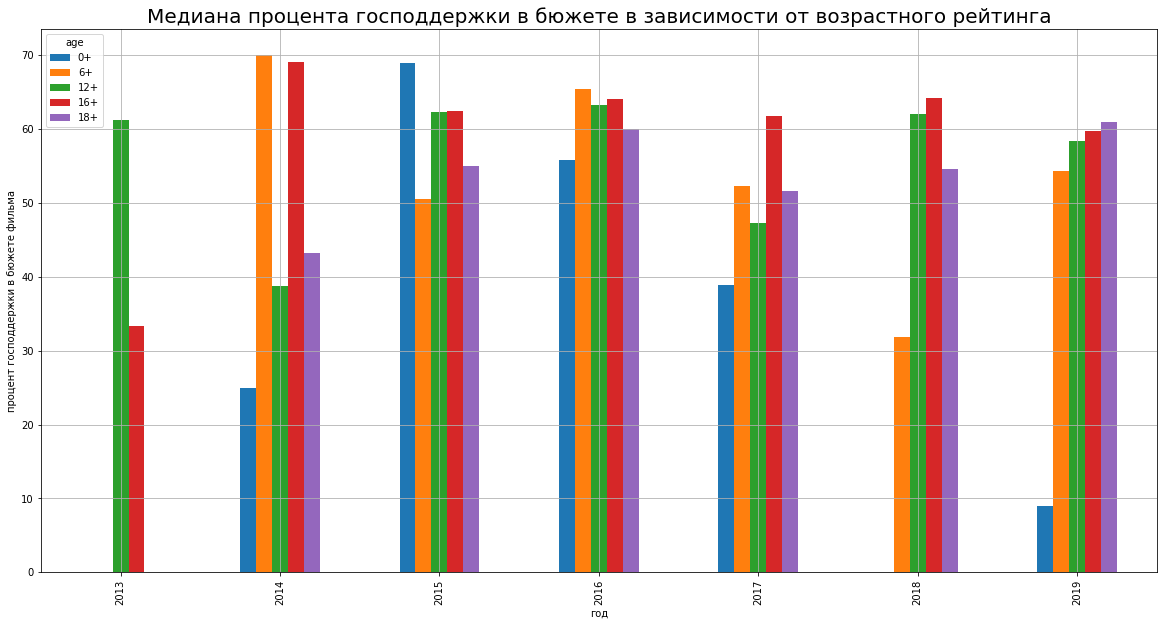

In [ ]:
data_help.pivot_table(index='year', columns = 'age', values='help_share', aggfunc='median')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график годовой структуры

plt.title('Медиана процента господдержки в бюжете в зависимости от возрастного рейтинга', fontsize=20)
plt.xlabel('год')
plt.ylabel('процент господдержки в бюжете фильма')

Text(0, 0.5, 'процент господдержки в бюжете фильма')

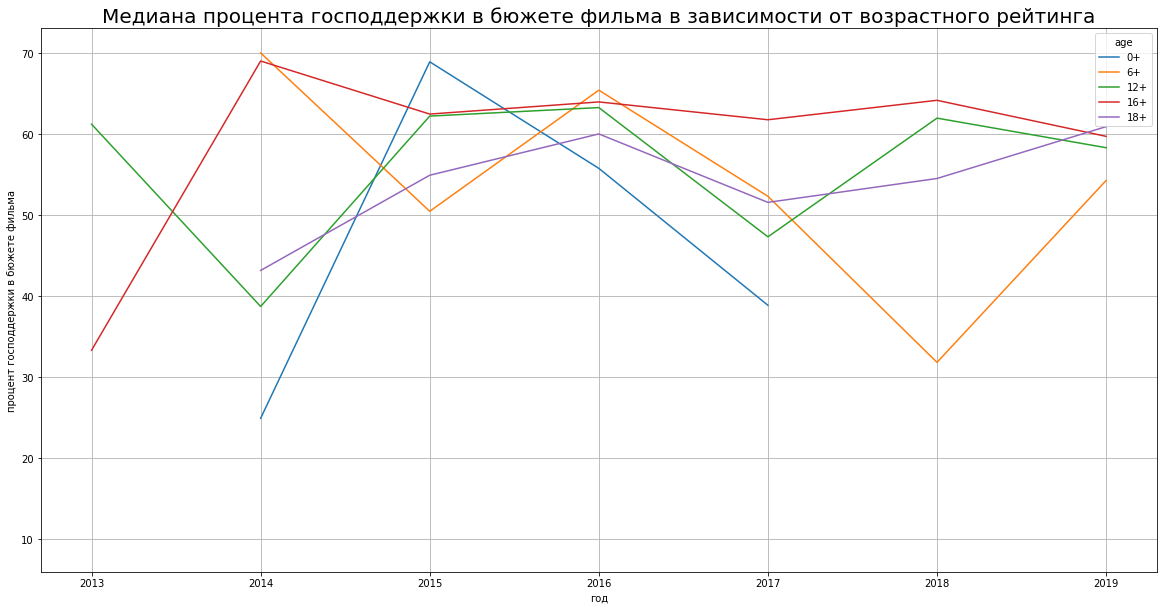

In [ ]:
data_help.pivot_table(index='year', columns = 'age', values='help_share', aggfunc='median')\
.plot(grid = True, figsize = (20,10)) # график динамики по годам

plt.title('Медиана процента господдержки в бюжете фильма в зависимости от возрастного рейтинга', fontsize=20)
plt.xlabel('год')
plt.ylabel('процент господдержки в бюжете фильма')

Закономерности отсутствуют.

По доле господдержки в зависимости от типа фильма.

Text(0, 0.5, 'процент господдержки в бюжете фильма')

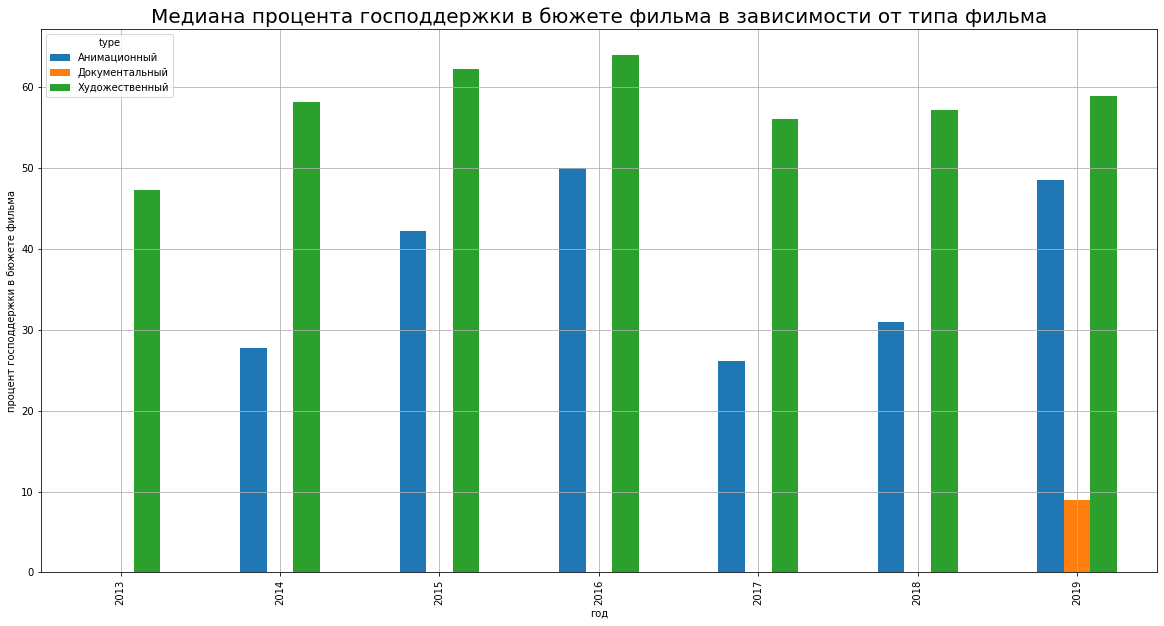

In [ ]:
data_help.pivot_table(index='year', columns = 'type', values='help_share', aggfunc='median')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график годовой структуры

plt.title('Медиана процента господдержки в бюжете фильма в зависимости от типа фильма', fontsize=20)
plt.xlabel('год')
plt.ylabel('процент господдержки в бюжете фильма')

Text(0, 0.5, 'процент господдержки в бюжете фильма')

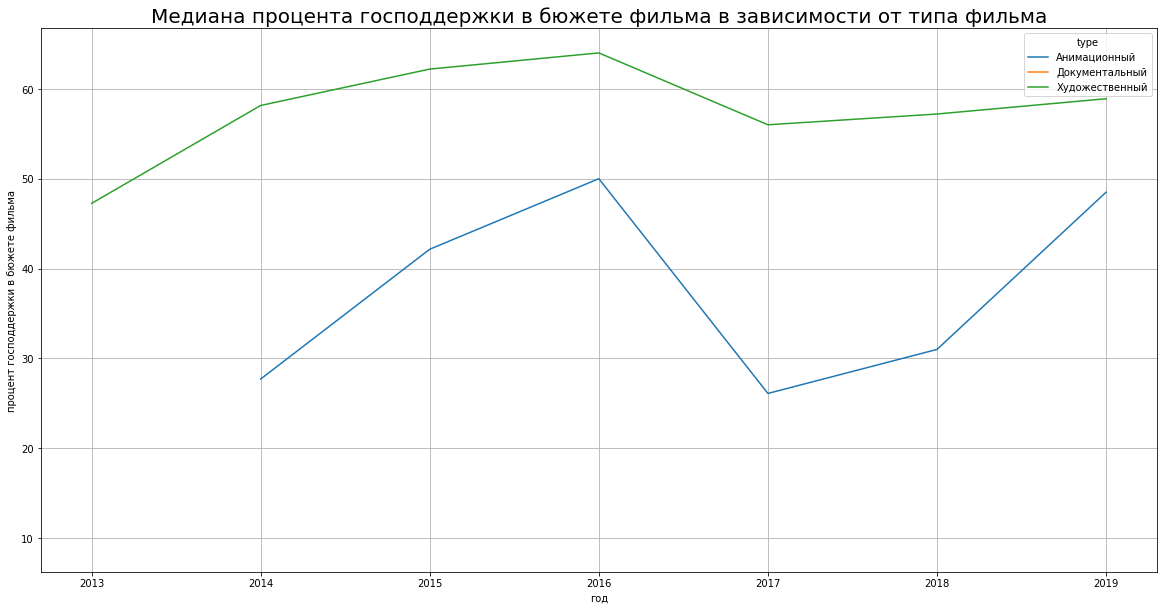

In [ ]:
data_help.pivot_table(index='year', columns = 'type', values='help_share', aggfunc='median')\
.plot(grid = True, figsize = (20,10)) # график динамики по годам

plt.title('Медиана процента господдержки в бюжете фильма в зависимости от типа фильма', fontsize=20)
plt.xlabel('год')
plt.ylabel('процент господдержки в бюжете фильма')

В целом художественные фильмы получают больше поддержки, чем анимационные. Другие типы ("документальные") преставлены лишь в 2019 году и доля господдержки в  бюджете невелика.

При этом доли господдержки в бюждете ведут себя синхронно друг другу из года в год. Возможно, в фондах прописаны определенные ограничения на выделяемые доли, и они отличаются в зависимости от типа фильма (на художественный допускается выделить больше, на анимационный - меньше) и есть квоты на фильмы определенных типов.

***Выводы***

В целом художественные фильмы получают больше поддержки, чем анимационные. Другие типы ("документальные") преставлены лишь в 2019 году и доля господдержки в  бюджете невелика. При этом доли господдержки в бюджете ведут себя синхронно друг другу из года в год.

#### Изучение датафрейма в целом

Так как выборка у нас невелика, можно попробовать изучать ее целиком, иногда независимо от года выхода.

Для начала создадим столбец с общей суммой затраченных на фильм государственных средств.

In [ ]:
data_help.insert(8, 'help_sum', (data_help['refundable_support'] + data_help['non_refundable_support']))

In [ ]:
data_help.head()

,title,year,type,age,help_share,refundable_support,non_refundable_support,budget,help_sum,ratings,main_genre,box_office_new
0,Пока еще жива,2013,Художественный,16+,33.3,0.0,26500000.0,79411900.0,26500000.0,8.1,драма,365353.6
1,Бесславные придурки,2014,Художественный,12+,70.0,0.0,26000000.0,37142857.0,26000000.0,NaN,NaN,28140.0
2,Невидимки,2013,Художественный,12+,61.2,0.0,107847945.0,176023490.0,107847945.0,5.3,комедия,19957031.5
3,БЕРЦЫ,2014,Художественный,16+,69.0,0.0,28000000.0,40574140.0,28000000.0,4.2,драма,55917.5
4,Братья Ч,2014,Художественный,16+,62.4,0.0,25000000.0,40015122.0,25000000.0,6.4,драма,232100.0


Теперь можно сделать сводную таблицу на его основе, чтобы получше изучить общую сумму выделяемых бюджетных средств, окупаемость фильмов и их рейтинг.

In [ ]:
help_year = data_help.groupby('year').agg({'year':'count', 'help_sum':'sum', 'budget':['count','sum'],\
                                           'box_office_new':['count','sum'], 'ratings':['count','median']}).reset_index()

In [ ]:
help_year.columns = ['year', 'films_count','help_sum_sum', 'budget_count','budget_sum','box_office_new_count',\
                     'box_office_new_sum','ratings_count','ratings_medium']

In [ ]:
help_year

,year,films_count,help_sum_sum,budget_count,budget_sum,box_office_new_count,box_office_new_sum,ratings_count,ratings_medium
0,2013,2,1.343479e+08,2,2.554354e+08,2,2.032239e+07,2,6.7
1,2014,16,5.720023e+08,16,1.279485e+09,16,1.017422e+09,15,6.4
2,2015,86,3.656241e+09,86,7.309669e+09,85,5.817074e+09,83,6.2
3,2016,61,4.303155e+09,61,7.228943e+09,60,6.090699e+09,57,5.8
4,2017,41,3.183972e+09,41,6.972173e+09,39,1.086508e+10,39,6.2
5,2018,56,3.446969e+09,56,6.651695e+09,56,9.934069e+09,53,6.2
6,2019,70,4.904000e+09,70,1.254287e+10,60,8.409627e+09,67,6.2


Как мы видим, финансовая и рейтинговая информация имеется практически по всем фильмам. Теперь можно попробовать это визуализировать.

Text(0, 0.5, 'сумма в руб.')

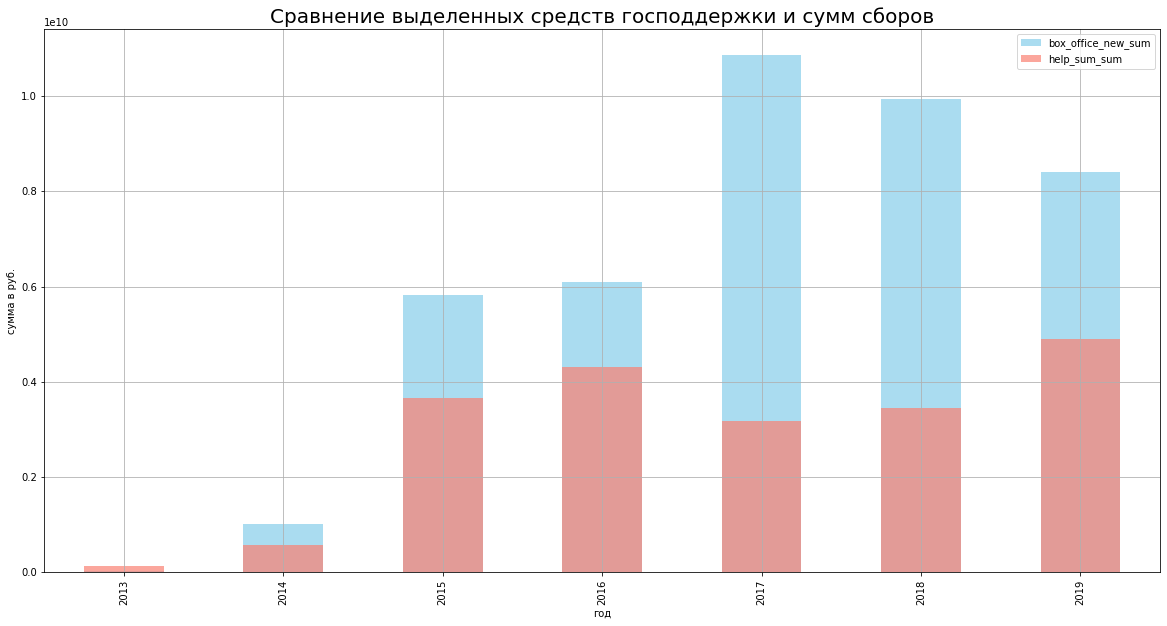

In [ ]:
ax=help_year.plot(y='box_office_new_sum', x='year',  kind='bar', color='skyblue', alpha=0.7, figsize=(20,10), grid=True)
help_year.plot(y='help_sum_sum', x='year',  kind='bar',color='salmon', alpha=0.7, ax=ax, figsize=(20,10),\
               grid=True, legend = True)

plt.title('Сравнение выделенных средств господдержки и сумм сборов', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма в руб.')

Наибольшие суммы господдержки были выделены в 2017 и 2018 годах.

Определенно, что фильмы собирают больше, чем сумма, потраченная на их поддержку государством. Но эта сумма - лишь часть общего бюджета, так что логичнее сравнивать с ней.

Text(0, 0.5, 'сумма в руб.')

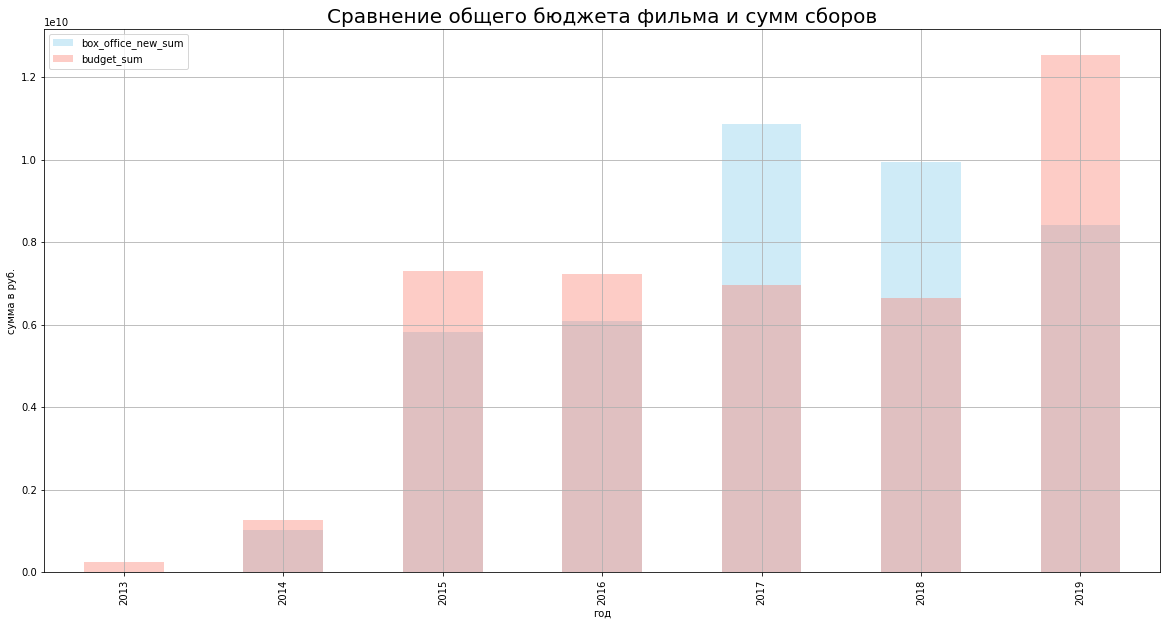

In [ ]:
ax=help_year.plot(y='box_office_new_sum', x='year',  kind='bar', color='skyblue', alpha=0.4, figsize=(20,10), grid=True)
help_year.plot(y='budget_sum', x='year',  kind='bar',color='salmon', alpha=0.4, ax=ax,figsize=(20,10),\
               grid=True,legend = True)

plt.title('Сравнение общего бюджета фильма и сумм сборов', fontsize=20)
plt.xlabel('год')
plt.ylabel('сумма в руб.')

А вот при сравнении с общим бюджетом ситуация гораздо печальнее: в целом фильмы с господдержкой не окупаются (исключения составили лишь те самые 2017 и 2018 годы).

Рейтинг также не радует и составляет в среднем от 5.8 до 6.7.

***Выводы***

Минимальная сумма господдержки была выделена в 2013 (и 2014м) году, тгда же снялои меньше всего фильмов.

Наибольшая сумма господдержки была выделена в 2017 и 2018 годах. Это также единственные года, когда снятые с господдержкой фильмы окупались (возможно, получилось снять фильмов меньше, но качественнее).

Рейтинг фильмов с господдержкой составляет в среднем от 5.8 до 6.7.

***Выводы***

Минимальные суммы господдержки были выделены в 2013 и 2014 году, тогда же было снято и меньше всего фильмов.

Наибольшая сумма господдержки была выделена в 2017 и 2018 годах, при этом самих фильмов было снято минимальное (за период 2015-2019 год) количество.Это также единственные года, когда снятые с господдержкой фильмы окупались.

Рейтинг фильмов с господдержкой составляет в среднем от 5.8 до 6.7.

В целом художественные фильмы получают больше поддержки, чем анимационные. Другие типы ("документальные") преставлены лишь в 2019 году и доля господдержки в бюджете невелика. При этом доли господдержки в бюджете ведут себя синхронно друг другу из года в год.

#### Дополнительное исследование

Вспомним, какие режиссеры сняли больше всех фильмов с гос поддержкой.

In [ ]:
data.query('help == True')['main_director'].value_counts().head(10)

Р.Давлетьяров    5
С.Андреасян      4
Д.Дьяченко       4
К.Шипенко        3
Н.Хомерики       3
С.Мокрицкий      3
А.Цицилин        3
А.Аксененко      3
Д.Шмидт          3
А.Котт           3
Name: main_director, dtype: int64

У нас определенно три лидера. Взглянем на их фильмы.

In [ ]:
data.loc[(data['main_director'] == 'Р.Давлетьяров')\
         |(data['main_director'] =='С.Андреасян')\
         |(data['main_director'] =='Д.Дьяченко')]

,title,pu_number,show_start_date,year,type,film_studio,production_country,main_director,director,producer,age,age_restriction,help,help_share,refundable_support,non_refundable_support,budget,financing_source,ratings,main_genre,genres,box_office,box_office_new,box_office_mill
463,Тот еще...!,111001612,2012-02-20 12:00:00+00:00,2012,Художественный,"ООО ""Энджой мувиз""",Россия,С.Андреасян,С.Андреасян,Г.Малков,12+,«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,2.6,фэнтези,"фэнтези,комедия,семейный",1.277900e+04,1.277900e+07,12779.00
607,Мамы,111001512,2012-02-15 12:00:00+00:00,2012,Художественный,"ООО ""Энджой мувиз""",Россия,С.Андреасян,"С.Андреасян, К.Оганисян, А.Кещян, Т.Корнев, Э....",Г.Малков,12+,«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,7.1,мелодрама,"мелодрама,комедия",2.217500e+04,2.217500e+07,22175.00
716,Пацаны.,111002013,2013-05-24 12:00:00+00:00,2013,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА"", НП ""Интерфест""",Россия,Р.Давлетьяров,Р.Давлетьяров,"Р.Давлетьяров, А.Котелевский",16+,«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,8.2,фантастика,"фантастика,боевик,драма",NaN,NaN,NaN
790,Что творят мужчины,111000513,2013-02-15 12:00:00+00:00,2013,Художественный,"ООО ""Комедия Фильм""",Россия,С.Андреасян,С.Андреасян,"Г.Малков, С.Андреасян, Г.Андреасян, В.Поляков",18+,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,3.3,комедия,комедия,7.790276e+05,7.790276e+05,779.02
869,Стальная бабочка,111004012,2012-08-24 12:00:00+00:00,2012,Художественный,"ООО ""Пропеллер продакшн, НП ""Интерфест"", ООО ""...",Россия,Р.Давлетьяров,"Р.Давлетьяров, Р.Прыгунов","Р.Давлетьяров, А.Котелевский",16+,«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,7.0,драма,"драма,криминал,детектив",NaN,NaN,NaN
1457,"Быстрее, чем кролики",111014413,2013-12-18 12:00:00+00:00,2013,Художественный,"ООО Кинокомпания ""Кейстоун Продакшн""",Россия,Д.Дьяченко,Д.Дьяченко,"ООО Киностудия ""Стрела""",16+,«16+» - для детей старше 16 лет,False,NaN,NaN,NaN,NaN,NaN,6.1,комедия,комедия,4.960000e+03,4.960000e+06,4960.00
1465,Кухня в Париже,111003914,2014-04-14 12:00:00+00:00,2014,Художественный,"ООО ""Кейстоун Продакшн"" по заказу ЗАО ""ВБД Гр...",Россия,Д.Дьяченко,Д.Дьяченко,"Э.Илоян, В.Шляппо, А.Троцюк",12+,«12+» - для детей старше 12 лет,False,NaN,NaN,NaN,NaN,NaN,6.8,комедия,комедия,1.291500e+04,1.291500e+07,12915.00
1496,Невидимки,111004213,2013-09-10 12:00:00+00:00,2013,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,Р.Давлетьяров,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",12+,«12+» - для детей старше 12 лет,True,61.2,0.0,107847945.0,176023490.0,Фонд кино,5.3,комедия,"комедия,фантастика",1.995703e+07,1.995703e+07,19957.03
1866,А зори здесь тихие..._,111002915,2015-03-16 12:00:00+00:00,2015,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,Р.Давлетьяров,unknown,12+,«12+» - для детей старше 12 лет,True,67.9,50000000.0,100000000.0,220588394.0,Фонд кино,8.5,драма,"драма,военный,история",2.491668e+08,2.491668e+08,249166.76
1937,Что творят мужчины 2,111022814,2014-12-02 12:00:00+00:00,2014,Художественный,"ООО ""ЕМ Продакшн""",Россия,С.Андреасян,С.Андреасян,"В.Поляков, Г.Андреасян, С.Андреасян",18+,«18+» - запрещено для детей,False,NaN,NaN,NaN,NaN,NaN,2.1,комедия,комедия,1.544618e+08,1.544618e+08,154461.83


Все их фильмы были художественными. И почти все сохранили информацию о кассовых сборах.

Оказвается, эти режиссеры снимали фильмы не только с господдержкой, но и самостоятельно. Для того, чтобы посмотреть на них поближе, создадим новый датафрейм.

In [ ]:
top_director = data.loc[(data['main_director'] == 'Р.Давлетьяров')\
         |(data['main_director'] =='С.Андреасян')\
         |(data['main_director'] =='Д.Дьяченко')][['title', 'year', 'type', 'main_director', 'age', 'help',
       'help_share', 'refundable_support', 'non_refundable_support', 'budget', 'ratings',
       'main_genre', 'box_office_new']].copy().reset_index(drop= True)

In [ ]:
top_director['main_director'] = top_director['main_director'].astype('category')

In [ ]:
top_director

,title,year,type,main_director,age,help,help_share,refundable_support,non_refundable_support,budget,ratings,main_genre,box_office_new
0,Тот еще...!,2012,Художественный,С.Андреасян,12+,False,NaN,NaN,NaN,NaN,2.6,фэнтези,1.277900e+07
1,Мамы,2012,Художественный,С.Андреасян,12+,False,NaN,NaN,NaN,NaN,7.1,мелодрама,2.217500e+07
2,Пацаны.,2013,Художественный,Р.Давлетьяров,16+,False,NaN,NaN,NaN,NaN,8.2,фантастика,NaN
3,Что творят мужчины,2013,Художественный,С.Андреасян,18+,False,NaN,NaN,NaN,NaN,3.3,комедия,7.790276e+05
4,Стальная бабочка,2012,Художественный,Р.Давлетьяров,16+,False,NaN,NaN,NaN,NaN,7.0,драма,NaN
5,"Быстрее, чем кролики",2013,Художественный,Д.Дьяченко,16+,False,NaN,NaN,NaN,NaN,6.1,комедия,4.960000e+06
6,Кухня в Париже,2014,Художественный,Д.Дьяченко,12+,False,NaN,NaN,NaN,NaN,6.8,комедия,1.291500e+07
7,Невидимки,2013,Художественный,Р.Давлетьяров,12+,True,61.2,0.0,107847945.0,176023490.0,5.3,комедия,1.995703e+07
8,А зори здесь тихие..._,2015,Художественный,Р.Давлетьяров,12+,True,67.9,50000000.0,100000000.0,220588394.0,8.5,драма,2.491668e+08
9,Что творят мужчины 2,2014,Художественный,С.Андреасян,18+,False,NaN,NaN,NaN,NaN,2.1,комедия,1.544618e+08


Посмотрим на средние рейтинги их фильмов, снятых с гос поддержкой.

Text(0, 0.5, 'медиана рейтинг')

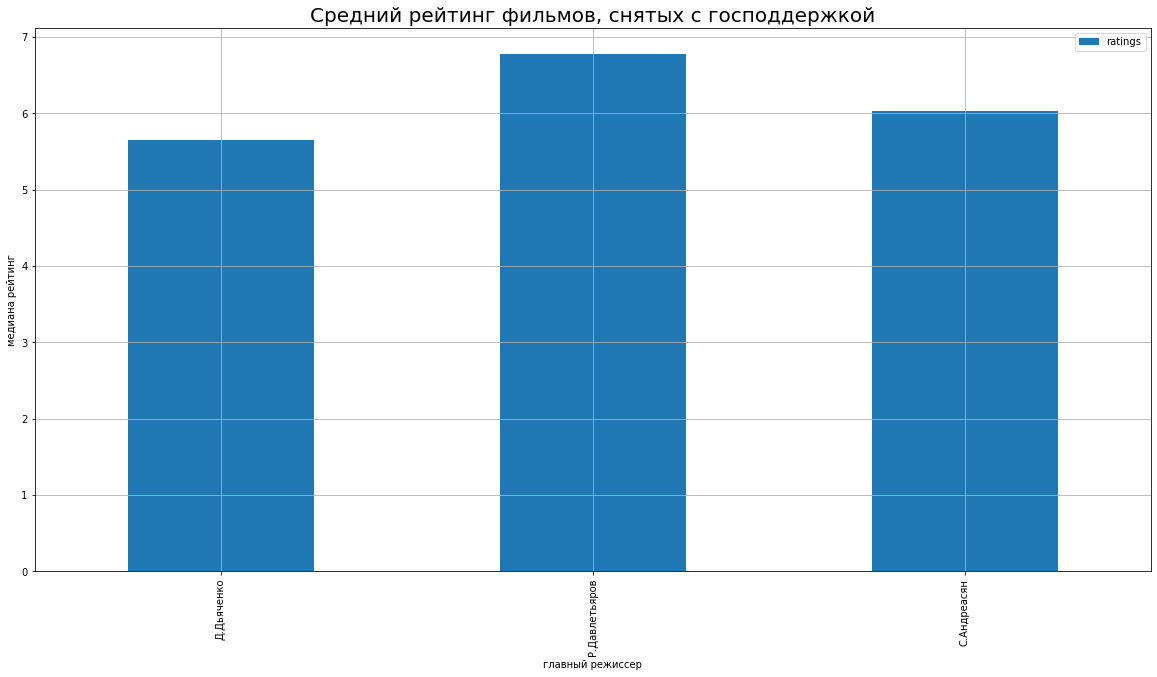

In [ ]:
top_director.query('help == True').pivot_table(index='main_director', values='ratings', aggfunc='mean')\
.plot(kind = 'bar', grid = True, figsize = (20,10))

plt.title('Средний рейтинг фильмов, снятых с господдержкой', fontsize=20)
plt.xlabel('главный режиссер')
plt.ylabel('медиана рейтинг')

Средний и чуть выше среднего. А если взять их фильмы в целом?

Text(0, 0.5, 'средний рейтинг')

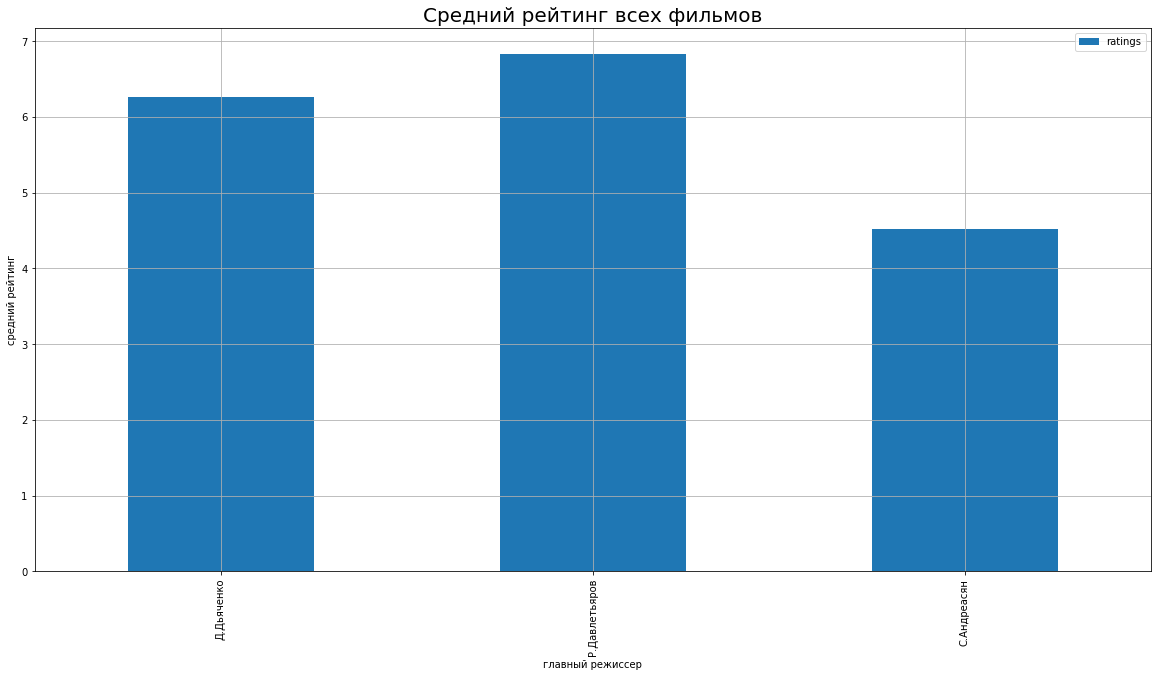

In [ ]:
top_director.pivot_table(index='main_director', values='ratings', aggfunc='mean')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график годовой структуры

plt.title('Средний рейтинг всех фильмов', fontsize=20)
plt.xlabel('главный режиссер')
plt.ylabel('средний рейтинг')

Только одному режиссеру господдержка пошла на пользу рейтингов. Но в целом ситуация по рейтингам аналогична таковой у остальных фильмов снятых с господдержкой, а не только снятых данными режиссерами.

Возможно, большая доля фильмов этих режиссеров была снята с участием господдержки. Быть может выставляемые фондами требования ограничивали творческий порыв, и без господдержки фильмы получали лучший рейтинг?

Text(0, 0.5, 'средний рейтинг')

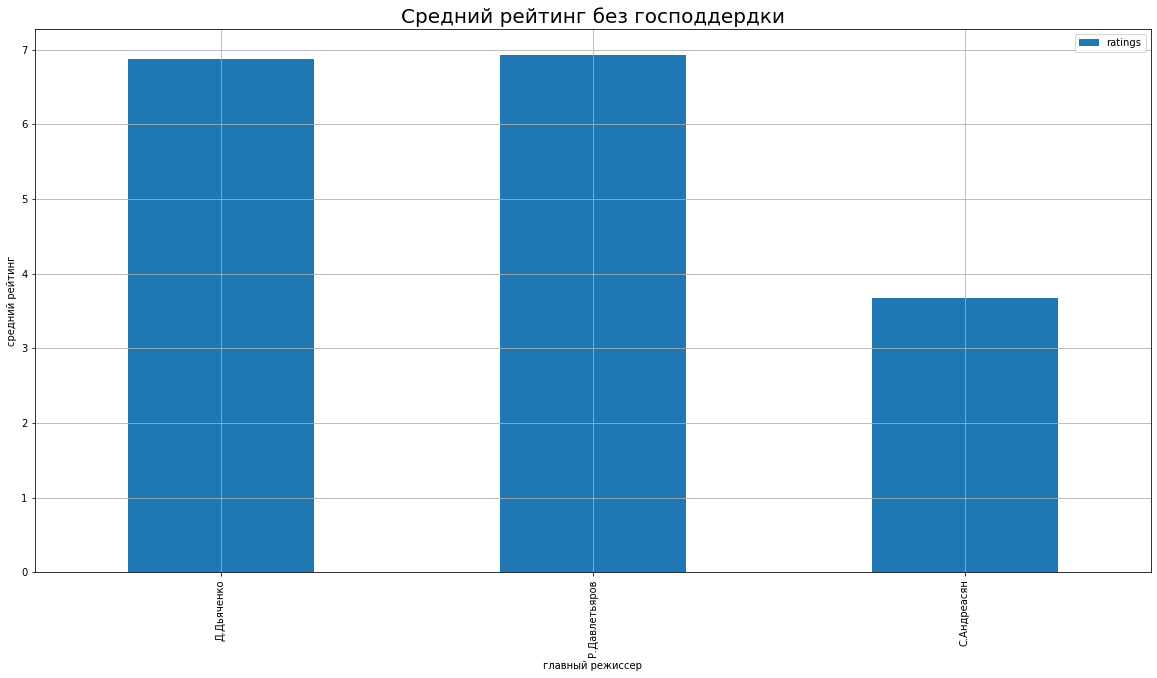

In [ ]:
top_director.query('help == False').pivot_table(index='main_director', values='ratings', aggfunc='mean')\
.plot(kind = 'bar', grid = True, figsize = (20,10)) # график годовой структуры

plt.title('Средний рейтинг без господдердки', fontsize=20)
plt.xlabel('главный режиссер')
plt.ylabel('средний рейтинг')

Нет, рейтинг фильмов не меняется. Видимо, уровень таланта режиссера в конкретном фильме не зависит от источника финансирования.

Посмотрим общий для них средний рейтинг для фильмов, снятыхз с господдержкой.

In [ ]:
top_director.query('help == True')['ratings'].mean()

6.199999999999999

Немного выше среднего.

Посмотрим, сколько всего они получили государственных средств.

In [ ]:
top_director.query('help == True')['non_refundable_support'].sum()\
+ top_director.query('help == True')['refundable_support'].sum()

1135847945.0

Общий бюджет их фильмов (сумма медиан)

In [ ]:
top_director.query('help == True')['budget'].median().sum()

156360666.0

Сколько они заработали (сумма медиана)

In [ ]:
top_director.query('help == True')['box_office_new'].median().sum()

188605593.3

Окупаемость

In [ ]:
top_director.query('help == True')['box_office_new'].median().sum()/\
top_director.query('help == True')['budget'].median().sum()*100 # в сравнениями со средствами господдержки

120.62214758026167

In [ ]:
(top_director.query('help == True')['non_refundable_support'].sum()\
+ top_director.query('help == True')['refundable_support'].sum())/\
top_director.query('help == True')['budget'].median().sum()*100 # в сравнениями со средствами господдержки

726.4281830316584

А вот окупаемость у их фильмов хорошая. Неудивительно, что им позволили снять столько фильмов.

***Выводы***

У трех "самых активных" главных режиссеров получавших господдержку фильмов имеется еще большое количесво фильмов, снятых без поддержки. Их фильмы имеют средний рейтинг (6.2), что схоже с ситуацией по рейтингу с прочими фильмами, снятыми с господдержкой.

Но при этом их фильмы, получившие господдержку, имеют высокую окупаемость.

### Шаг 5. Напишите общий вывод

Для исследования были получены данные от Министерства Культуры Российской Федерации.

**На этапе предобработки были выполнены следующие действия:**

1. Сведены в один несколько полученных датасетов.
2. Приведены к хорошему стилю наименования столбцов, а сами столбцы расставлены более логично.
3. Обнаружены пропуски и по возможности осуществлена их замена.
4. Исправлены неподходящие типы данных в тех столбцах, где это было возможно и необходимо.
5. Изучены данные на предмет дубликатов и по-возможности произведено их исправление.
6. Изучены данные на предмет аномалий. Часть аномалий было исправлено, часть - исключено из исследования. Обнаружено, что пользователи склонны чаще оценивать фильмы положительно, чем отрицательно.
7. Добавлены новые столбцы для использования их в будущем исследовании.

**На этапе исследовательского анализа данных мы проверили несколько гипотез и установили:**

1. Наиболее полно в данных о прокате представлен период с 2015 по 2017 год, наименее - с 2010 по 2014. Резкий качесвенный подъем в сборе данных произошел в 2015 году
2. Минимальная сумма сборов (с учетом доступной для подсчетов информации) была зафиксирована в 2010 году. Максимальная (с теми же ограниченими) - 2019 году. Рывок в кассовых сборах также случился в 2015 году.
3. Средняя сумма сборов всегда превышает медиану от двух до более чем в три раза, что указывает на крайнюю неоднородность выборки, обусловленную проблемами со сбором и учетом данных по прокатным сборам. В период низкой полноты представленности информации (2010-2014гг) медиана не всегда повторяет тенценции (рост или падение) среднего. Зато с 2015 появилась синхронность.
4. Больше всего в прокате собирают фильмы с возрастным рейтингом '«16+» - для детей старше 16 лет' и '«18+» - запрещено для детей', меньше всего - '«0+» - для любой зрительской аудитории'. Это может быть связано с тем, что фильмов из первых двух категорий в принципе выходит в прокат больше, чем третьих. Также замечено, что фильмов с возрастным рейтингом '«0+» - для любой зрительской аудитории' в принципе необычно мало в выборке за период 2017-2019 на фоне периода 2015-2016, что может быть связано с тем, что их выходило в прокат меньше в принципе, либо они не попали в наш датафрейм по каким-либо причинам.
5. Больше всего в прокат независимо от года в период с 2015 по 2019 год выходило 'художественных' фильмов, на втором месте с большим отставанием - 'анимационные'. Последние места с количеством чуть более нескольких штук занимают 'музыкально-развлекательные', иногда разделяя его с 'научно-популярными'. По абсолютным имеющимся у нас суммам сборов также лидируют 'художественные' фильмы, второе место - у 'анимационных'.
6. Выборка является ограниченно реперезентативной.

**На этапе исследования фильмов, снятых с участием господдержки, мы обнаружили, что:**

1. Фильмы с господдержкой начали производиться начиная с 2013 года, тогда же (в 2013 и 2014 годах) было снято минимальное количество фильмов с господдержкой и выделена минимальная сумма господдержки.
2. В целом художественные фильмы получают больше господдержки, чем анимационные. Другие типы ("документальные") представлены лишь в 2019 году и доля господдержки в их бюджете невелика. При этом доли господдержки в бюджете этих двух категорий ведут себя синхронно друг другу из года в год.
3. Отсутствие зависимости между возрастным рейтингом фильма и долей господдержки в бюджете.
4. Наибольшая сумма господдержки была выделена в 2017 и 2018 годах, при этом самих фильмов было снято минимальное (за период 2015-2019 год) количество. Это также единственные года, когда снятые с господдержкой фильмы окупались.
5. Рейтинг фильмов с господдержкой составляет в среднем от 5.8 до 6.7.
6. Имеется три режиссера, которые сняли больше остальных фильмов с участием господдержки. При этом их фильмы окупаются и приносят прибыль.


**Рекомендации по улучшению сбора данных:**

1. Выявить и устранить источник пропусков в исходных данных.

Основное внимание уделить кассовым сборам, как наиболее весомому показателю успешности фильма, в том числе дающему возможность оценить его окупаемость.

2. Выявить причины сверхнизких кассовых сборов у большой доли фильмов.

3. Выявить причины появления иных аномалий, в том числе нарушающих репрезентативность выборки.

Например, в фильм могли не попасть многие фильмы для возрастной категории "0+" за 2017 год, что смещает картину проката.

4. Унифицировать способ внесения данных.

Например, пределится с системой маркировки (годом, страной или фамилией режиссера вместо точек, подчеркиваний и тому подобного) фильмов-тезок в случае их неидентичности, порядком внесения режиссеров и так далее для избежания путаницы и увеличения количества скрытых дублей.

5. Оптимизировать датафрейм как способ хранения информации.

Привести к хорошему стилю наменования столбцов и придать им более подходящий тип данных. Возможно, стоит дополнить датафрейм информацией о сумме бюждета, полученного из иных (не господдержка) источников.